# Clinical NLP over Italian Hospital Records 

*NLP4DH exam project.* An end-to-end **Natural Language Processing (NLP)** pipeline over 857 pseudonymized Italian discharge records, spanning a broad range of NLP techniques: **regex extraction**, **dense retrieval**, **zero-shot Named Entity Recognition (NER, via GLiNER)**, **dependency parsing**, **symbolic vs. neural context classification**, **entity linking**, a **symbolic alert engine**, **neuro-symbolic tool-calling (Ollama)**, and a **knowledge graph with SPARQL**.


> **Notebook structure**

> 0. EDA 
> 1. Regex extraction - discharge therapy *(pure symbolic baseline)*
> 2. Symbolic candidate extraction and AIFA normalization - ingress therapy
> 3. GLiNER entity extraction - anamnesis *(Kautz Type 1)*
> 4. Context classification - NegEx / Natural Language Inference (NLI) / NegEx->NLI cascade *(Kautz Type 2, Symbolic[Neuro])*
> 5. Entity linking - ATC (Anatomical Therapeutic Chemical) & ICD-9-CM (International Classification of Diseases, 9th rev., Clinical Modification)
> 6. Alert engine *(symbolic, deterministic)*
> 7. Ollama + tool calling *(Kautz Type 6)*
> 8. Knowledge graph, SPARQL & rough temporal/discourse ordering *(Discourse level)*
> 9. Gold annotation & evaluation (50 patients)
> 10. Discussion & limitations


## Section 0 - Exploratory Data Analysis

**Goal.** Before any NLP component is built, the data is inspected for what it actually contains: how many
patients and reports there are, how long the free text is per report type, and the
*critical cases* that every downstream step will have to survive (empty therapies, combination drugs,
non-drug lines such as oxygen / NIV / CPAP).


In [1]:
# --- Global setup: imports, paths, reproducibility -------------------------------------------
# Everything downstream reuses the paths and the SEED defined here.
import json, re, random, textwrap
from pathlib import Path
import numpy as np
import pandas as pd

# Silence the tqdm progress-bar notice emitted when ipywidgets is not installed in this environment.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

from transformers.utils import logging as _hf_logging
_hf_logging.set_verbosity_error(); _hf_logging.disable_progress_bar()
try:
    from huggingface_hub.utils import disable_progress_bars as _disable_hf_bars
    _disable_hf_bars()
except Exception:
    pass

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA      = PROJECT_ROOT / "data"
EXTERNAL  = DATA / "external"          # pre-downloaded knowledge resources (AIFA, DDInter, ...)
OUTPUTS   = PROJECT_ROOT / "outputs"   # cached intermediate dataframes (so re-runs are faster)
ANNOT     = DATA / "annotations"       # gold annotations (Step 9)
OUTPUTS.mkdir(exist_ok=True)
ANNOT.mkdir(exist_ok=True)

SEED = 42                             
random.seed(SEED); np.random.seed(SEED)

pd.set_option("display.max_colwidth", 90)

# Load the raw dataset: a list of 857 patients, each with exactly three reports.
with open(DATA / "pazienti_con_terapia_uscita_testuale.json", encoding="utf-8") as f:
    patients = json.load(f)

# The three report types every patient has
T_ANAMNESI  = "Anamnesi"
T_INGRESSO  = "Terapia medica all'ingresso"
T_DIMISSIONE = "Terapia alla Dimissione"

def report_text(patient, tipo):
    "Return the free text of a given report type for a patient ('' if missing)."
    for r in patient["referti"]:
        if r["tipo"] == tipo:
            return r["testo"] or ""
    return ""


def wrap(text, width=100):
    "Wrap long free text to `width` columns for readable output, keeping existing line breaks."
    return "\n".join(textwrap.fill(ln, width=width) if ln.strip() else ln
                     for ln in str(text).splitlines())

print(f"Loaded {len(patients)} patients from {DATA.name}/")
print("Project directories initialized.")

Loaded 857 patients from data/
Project directories initialized.


In [2]:
rows = []
for p in patients:
    for r in p["referti"]:
        rows.append({"tipo": r["tipo"], "len_chars": len(r["testo"] or "")})
reports_df = pd.DataFrame(rows)

n_patients = len(patients)
n_exactly3 = sum(len(p["referti"]) == 3 for p in patients)
print(f"patients: {n_patients} | patients with exactly 3 reports: {n_exactly3}")

length_stats = (reports_df.groupby("tipo")["len_chars"]
                .agg(["count", "min", "median", "mean", "max"])
                .round(0).astype(int))
print("Text length in characters per report type (count = number of reports):")
length_stats

patients: 857 | patients with exactly 3 reports: 857
Text length in characters per report type (count = number of reports):


,count,min,median,mean,max
tipo,,,,,
Anamnesi,857,222,1693,2239,15968
Terapia alla Dimissione,857,15,649,679,2281
Terapia medica all'ingresso,857,4,284,318,1899


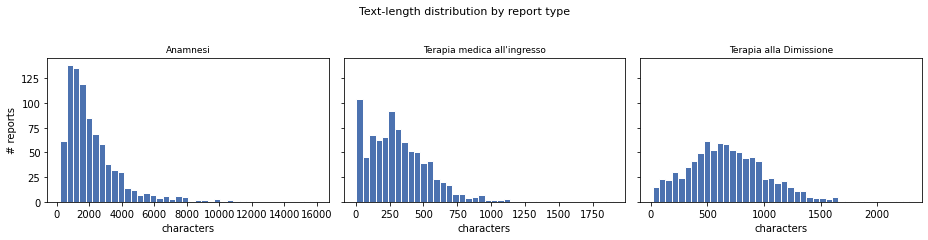

In [3]:
# --- Text-length distribution per report type ------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, tipo in zip(axes, [T_ANAMNESI, T_INGRESSO, T_DIMISSIONE]):
    vals = reports_df.loc[reports_df.tipo == tipo, "len_chars"]
    ax.hist(vals, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(tipo, fontsize=9)
    ax.set_xlabel("characters")
axes[0].set_ylabel("# reports")
fig.suptitle("Text-length distribution by report type", y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

In [4]:
# --- Representative examples, including the critical cases downstream steps must handle -----------
def show(title, text, width=350):
    _body = text[:width] + ("…" if len(text) > width else "")
    print(f"### {title}\n{wrap(_body)}\n")

# A "normal" structured discharge line (near-template) + a combination drug (Clopidogrel/ASA):
show("Terapia alla Dimissione - structured template + combination drug",
     report_text(patients[0], T_DIMISSIONE))

# A "normal" ingress line (semi-structured 'Nome: dose forma /die (ore N)'):
show("Terapia medica all'ingresso - semi-structured", report_text(patients[0], T_INGRESSO))

# Another semi-structured ingress form: a bare brand-name list taken "al bisogno" (no doses/template):
show("Terapia medica all'ingresso - semi-structured (brand-name list)",
     report_text(next(p for p in patients if p["encOid"] == 10237923), T_INGRESSO))

# Edge case 1: empty home therapy.
ex_empty = next(p for p in patients if "essuna terapia" in report_text(p, T_INGRESSO))
show("EDGE - empty home therapy", report_text(ex_empty, T_INGRESSO))

# Edge case 2: non-drug therapy line (oxygen / NIV / CPAP) mixed with drugs - must be filtered.
ex_o2 = next(p for p in patients if re.search(r"Ossigeno|NIV|CPAP", report_text(p, T_INGRESSO)))
show("EDGE - non-drug lines (O2/NIV/CPAP) among drugs", report_text(ex_o2, T_INGRESSO))

# Edge case 3: bare description with no dose/structure.
ex_bare = next(p for p in patients
               if not re.search(r"\d", report_text(p, T_INGRESSO))
               and "essuna" not in report_text(p, T_INGRESSO)
               and len(report_text(p, T_INGRESSO)) > 10)
show("EDGE - bare free-text, no doses", report_text(ex_bare, T_INGRESSO))

### Terapia alla Dimissione - structured template + combination drug
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300
mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI
(ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin
cp.riv. 75 mg): da assumere 75/100 mg (ore 19)" "Panto…

### Terapia medica all'ingresso - semi-structured
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ;
Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg
cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

### Terapia medica all'ingresso - semi-structured (brand-name list)
Al bisogno assume: Normix, Mesalazina, Flexiban, Arcoxia;

### EDGE - empty home therapy
Nessuna terapia domiciliare.

### EDGE - non-drug lines (O2/NIV/CPAP) among drugs
Rosumibe: 10/10 

In [5]:
# --- Representative anamnesis examples -------------------------------------------------------
def _patient_oid(p):
    return p["encOid"] if isinstance(p, dict) and "encOid" in p else p


def _first_patient_with(pattern, *, exclude=None, forbid=None, min_len=None):
    exclude = set() if exclude is None else {_patient_oid(p) for p in exclude}
    forbid = [] if forbid is None else list(forbid)
    for p in patients:
        if _patient_oid(p) in exclude:
            continue
        txt = report_text(p, T_ANAMNESI) or ""
        if min_len is not None and len(txt) < min_len:
            continue
        if forbid and any(re.search(rx, txt, flags=re.IGNORECASE) for rx in forbid):
            continue
        if re.search(pattern, txt, flags=re.IGNORECASE):
            return p
    return None


def _sentence_with(text, pattern, width=260):
    txt = text or ""
    sentences = re.split(r"(?<=[.!?])\s+", txt)
    for sent in sentences:
        if re.search(pattern, sent, flags=re.IGNORECASE):
            return sent.strip()
    match = re.search(pattern, txt, flags=re.IGNORECASE)
    if not match:
        return txt[:width] + ("…" if len(txt) > width else "")
    start = max(0, match.start() - width // 2)
    end = min(len(txt), match.end() + width // 2)
    prefix = "…" if start > 0 else ""
    suffix = "…" if end < len(txt) else ""
    return f"{prefix}{txt[start:end]}{suffix}"


# 1) Narrative overview: a long anamnesis excerpt without explicitly foregrounding one cue.
ex_narrative = next(
    p for p in patients
    if len(report_text(p, T_ANAMNESI) or "") > 300
    and not re.search(
        r"\b(pregress\w*|remot\w*|familiarit\w*|non\s+familiarit\w*|nega\b|esclu\w*|in passato)\b",
        report_text(p, T_ANAMNESI) or "",
        flags=re.IGNORECASE,
    )
)
show("Anamnesi - narrative overview", report_text(ex_narrative, T_ANAMNESI))

# 2) Negation: show a different patient and print the sentence that contains the negated finding.
ex_negated = _first_patient_with(
    r"\bNega\b|\bnon\s+ha\s+mostrato\s+evidenza\b|\bE'?\s+stata\s+quindi\s+esclusa\b|\bnon\s+presenta\b",
    exclude=[ex_narrative],
)
if ex_negated is not None:
    print("### Anamnesi - negated condition")
    print(wrap(_sentence_with(report_text(ex_negated, T_ANAMNESI), r"\bNega\b|\bnon\s+ha\s+mostrato\s+evidenza\b|\bE'?\s+stata\s+quindi\s+esclusa\b|\bnon\s+presenta\b")))
    print()

# 3) Family history: the key signal is that the condition belongs to relatives, not the patient.
ex_family = _first_patient_with(
    r"\bfamiliarit\w*|madre|padre|fratell\w*|sorell\w*",
    exclude=[ex_narrative],
    forbid=[r"\bnega\b|\bnon\s+(?:ha|presenta|riferisce|si\s+evidenzia|si\s+documenta)\b|pregress\w*|remot\w*|precedent\w*|in passato\b"],
)
if ex_family is not None:
    print("### Anamnesi - family history")
    print(wrap(_sentence_with(report_text(ex_family, T_ANAMNESI), r"\bfamiliarit\w*|madre|padre|fratell\w*|sorell\w*")))
    print()

# 4) Historical / remote history: the key signal is that the condition is in the past.
ex_historical = _first_patient_with(
    r"\b(pregress\w*|remot\w*|precedent\w*|in passato|anamnesi patologica remota)\b",
    exclude=[ex_narrative, ex_family],
    forbid=[r"\bnega\b|\bnon\s+(?:ha|presenta|riferisce|si\s+evidenzia|si\s+documenta)\b|familiarit\w*|madre|padre|fratell\w*|sorell\w*"],
)
if ex_historical is not None:
    print("### Anamnesi - historical / remote history")
    print(wrap(_sentence_with(report_text(ex_historical, T_ANAMNESI), r"\b(pregress\w*|remot\w*|precedent\w*|in passato|anamnesi patologica remota)\b")))
    print()

# 5) Mixed cue: center the sentence on the family-history term so the family signal is visible too.
ex_mixed = _first_patient_with(
    r"\bnon\s+familiarit\w*|\bfamiliarit\w*",
    exclude=[ex_narrative, ex_family, ex_historical],
)
if ex_mixed is not None:
    print("### Anamnesi - mixed cue (family vs negation)")
    print(wrap(_sentence_with(report_text(ex_mixed, T_ANAMNESI), r"\bnon\s+familiarit\w*|\bfamiliarit\w*")))
    print()

### Anamnesi - narrative overview
Fattori di rischio: Ipertensione arteriosa essenziale, ipercolesterolemia, Obesita si. Barriera
linguistica totale. 19/12/25 intervento di TEA carotidea a sinistra con interposizione di tratto di
safena sinistra. Residua stenosi del 50% della carotide destra. Polmonite bilaterale ricoverato in
Albania. Durante il ricovero eseguiva una TC con riscon…

### Anamnesi - negated condition
Nega allergia a farmaci e/o alimenti.

### Anamnesi - family history
AF: lontana familiarita per CHD non meglio definita.

### Anamnesi - historical / remote history
Allergie e intolleranze: Allergie e intolleranze non note Anamnesi Remota: Ipertensione arteriosa.

### Anamnesi - mixed cue (family vs negation)
Nega familiarita per diabete o altre cardiopatie congenite.




| Observation | Consequence for the pipeline |
|---|---|
| All 857 patients have exactly the 3 expected report types | Reports can be retrieved reliably by type without missing-report handling. |
| *Terapia alla Dimissione* follows a near-fixed template `Principio (Nome forma dosaggio): da assumere …` | **Step 1** can extract it with regular expressions. |
| *Terapia medica all'ingresso* is short and heterogeneous (semi-structured, bare lists, empty, or non-drug) | **Step 2** needs a symbolic candidate extractor (AIFA-catalog gazetteer, exact longest-match) plus a pre-filter for O2/NIV/CPAP. |
| *Anamnesi* is long, narrative Italian prose | **Step 3-4** need NER + context (negation/family/temporal) over real syntax. |


## Section 1 - Structured extraction from *Terapia alla Dimissione* (regex)

The discharge therapy follows a near-fixed template, so extraction is done with named-group regular expressions. 

The template is:
```
"Principio attivo (Nome commerciale forma dosaggio): <body>"
```
where `<body>` is usually 

`da assumere <dose> <unit> (ore N)[, <dose> (ore N) …] [free-text notes]`.

It is parsed in three stages (**header**, **commercial part**, **body**) rather than with
one monolithic regex, so each piece is easy to read and test.

In [6]:
# Raw input for this section: the discharge-therapy free text of the first three patients (truncated).
for _p in patients[:3]:
    _t = report_text(_p, T_DIMISSIONE).strip()
    print(f"--- patient {_p['encOid']} | Terapia alla Dimissione ---")
    print(wrap((_t[:400] + " ...") if len(_t) > 400 else (_t or "(no discharge therapy)")))
    print()

--- patient 10216091 | Terapia alla Dimissione ---
"Acido folico (Folina cps. molli 5 mg): da assumere 5 mg (ore 15)" "Tiamina (Benerva cpr.gastr. 300
mg): da assumere 300 mg (ore 15)" "Colecalciferolo (Annova cp.riv. 7000 UI): da assumere 7000 UI
(ore 13), ogni 6 giorni (a partire da 2 giorni fa)" "Clopidogrel/acido acetilsalicilico (Duoplavin
cp.riv. 75 mg): da assumere 75/100 mg (ore 19)" "Pantoprazolo (Pantoprazolo sand cpr.gastr. 20 mg):
da a ...

--- patient 10175544 | Terapia alla Dimissione ---
"Omeprazolo (Omeprazolo my cps. 20 mg): da assumere 20 mg (ore 8)" "Acido folico (Folina cps. molli
5 mg): da assumere 5 mg (ore 8)" "Clopidogrel/acido acetilsalicilico (Duoplavin cp.riv. 75 mg): da
assumere 75/100 mg (ore 20)"

--- patient 10223315 | Terapia alla Dimissione ---
"Ossigeno, NIV Maschera, solo notte in aria ambiente, secondo schema domiciliare" "Clopidogrel
(Clopidogrel zen cp.riv. 75 mg): da assumere 75 mg (ore 8)" "Rosuvastatina/ezetimibe (Rosumibe cpr.
10/10 mg): da ass

In [7]:
import re

# ---- Vocabularies / building-block patterns -------------------------------------------------
# Pharmaceutical-form lead tokens: the commercial part is "<Brand> <forma> <dose><unit>", and the
# forma always begins with one of these abbreviations. The brand is split from the forma.
FORMA_LEAD = re.compile(r'\b(cp|cpr|cps|compress|cerott|soluz|sosp|comp|bust|gtt|fial|fl|'
                        r'capsul|ovul|crema|pomata|collirio|spray|scir|granul|polvere|nebuliz)', re.I)
# Trailing strength inside the parenthesis, e.g. "... 5 mg", "... 7000 UI", "... 10 mg/d".
DOSE_TAIL  = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(mg/d|mg|mcg|g|UI|U|ml|%|unità)\s*$', re.I)
# Non-drug therapy lines (oxygen / ventilation) that must NOT enter the drug table.
NONDRUG    = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil)', re.I)
# A numeric dose that immediately governs an "(ore N)" administration-time group.
DOSE_ORA   = re.compile(r'([\d]+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(mg|mcg|g|UI|U|ml|gtt|unità)?'
                        r'[^()]*?\(ore\s*([^)]+)\)', re.I)
# Header: "<principio attivo> (<commercial>)?: <body>"
HEADER     = re.compile(r'^\s*(?P<pa>[^(:]+?)\s*(?:\((?P<comm>[^)]*)\))?\s*:\s*(?P<body>.*)$', re.S)


def to_float(s):
    """Italian decimal comma -> float. Combination doses ('75/100') keep the first component."""
    if s is None:
        return None
    s = s.split("/")[0].replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return None


def dose_components(s):
    """Combination strength -> list of floats: '75/100' -> [75.0, 100.0]; '5' -> [5.0]."""
    if s is None:
        return []
    out = []
    for part in str(s).split("/"):
        try:
            out.append(float(part.replace(",", ".").strip()))
        except ValueError:
            pass
    return out


def parse_commercial(comm):
    """'Atorvastatina sa cp.riv. 80 mg' -> (nome_commerciale, forma, dosaggio_unitario, unit)."""
    dosaggio = unit = None
    rest = comm
    m = DOSE_TAIL.search(comm)
    if m:
        dosaggio, unit = m.group(1), m.group(2)
        rest = comm[:m.start()].strip()
    fm = FORMA_LEAD.search(rest)
    if fm:
        nome, forma = rest[:fm.start()].strip(), rest[fm.start():].strip()
    else:
        nome, forma = rest, None
    return (nome or None), forma, dosaggio, unit


def count_administration_times(ore_text):
    """Count clock times inside an '(ore ...)' group: '09:30'->1, '8-20'->2, '8, 14, 20'->3."""
    return len(re.findall(r"(?<!\d)(?:[01]?\d|2[0-4])(?:[:.][0-5]\d)?(?!\d)", ore_text))   # 24 = midnight


def parse_body(body):
    """Extract (dose, ora) pairs, the number of explicit administration times, and the residual free-text note."""
    pairs = [(to_float(dose), re.sub(r'\s+', '', ora)) for dose, _u, ora in DOSE_ORA.findall(body)]

    # n_explicit_times = how many explicit clock times appear in the "(ore ...)" groups (NOT a real
    # explicit administration times: "ogni 6 giorni" / "a giorni alterni" are not decoded). "(ore 09:30)" is 1,
    # "(ore 8-20)" is 2, "(ore 8, 14, 20)" is 3.
    n_explicit_times = sum(count_administration_times(ore) for ore in re.findall(r'\(ore\s*([^)]+)\)', body))

    # note = whatever free text is left once dose/(ore ...) chunks are removed
    note = re.sub(r'^\s*da assumere\s*', '', body)
    note = DOSE_ORA.sub(' ', note)
    note = re.sub(r'\(ore[^)]*\)', ' ', note)
    note = re.sub(r'\s+', ' ', note).strip(' ,.;')
    return pairs, (n_explicit_times or None), (note or None)


def parse_discharge_entry(entry):
    """Parse one quoted drug entry into a dict, or None if it is a non-drug/undecodable line."""
    entry = entry.strip()
    if not entry or NONDRUG.search(entry.split("(")[0]):
        return None
    m = HEADER.match(entry)
    if not m:
        return None
    pa_raw = m.group("pa").strip()
    if NONDRUG.search(pa_raw):
        return None
    nome, forma, dos_u, unit = parse_commercial(m.group("comm")) if m.group("comm") else (None, None, None, None)
    pairs, n_explicit_times, note = parse_body(m.group("body"))
    _pa_list = [x.strip() for x in pa_raw.split("/") if x.strip()]        # combination -> per-ingredient list
    _dose_comp = dose_components(dos_u)                                     # keep BOTH dose components (75/100 -> [75,100])
    _dose_per_ing = dict(zip(_pa_list, _dose_comp)) if len(_dose_comp) > 1 and len(_pa_list) == len(_dose_comp) else None
    # prescription status: currently-suspended (past participle 'sospeso/a'), PRN ('al bisogno'),
    # else active. NB 'poi sospendere' is a *planned* future stop -> still active now.
    _body = m.group("body").lower()
    status = ("suspended" if re.search(r"\bsospes[oaei]\b", _body)
              else "prn" if "al bisogno" in _body else "active")
    return dict(
        principio_attivo=_pa_list,                                    # split combination drugs on '/'
        nome_commerciale=nome, forma=forma,
        dosaggio_unitario=to_float(dos_u),                            # first component (kept for compatibility)
        dosaggio_raw=dos_u, dosaggio_componenti=_dose_comp,           # full combination strength preserved
        dosaggio_per_ingrediente=_dose_per_ing, unit=unit,
        dose_ora=pairs, n_orari_espliciti=n_explicit_times, note=note, status=status,
    )

# Validity filter reused by ATC linking (Step 5) and the alert engine (Step 6): a clean drug name has
# length > 2 and no unit/instruction token or clock time (keeps names with digits, e.g. "Macrogol 3350").
NOISY_DRUG_TEXT = re.compile(r"\b(?:ore|cp|cpr|cps|mg|mcg|gtt|fiala|fiale|bustin[ae]|die|prn|al bisogno)\b|\b\d[\d.,/]*\s*(?:g|ui|ml|fl)\b|\b\d{1,2}[:.]\d{2}\b", re.I)
def is_drug_name(value):
    return (isinstance(value, str) and len(value.strip()) > 2
            and bool(re.search(r"[A-Za-zÀ-ÿ]", value)) and not NOISY_DRUG_TEXT.search(value))
assert not is_drug_name("100") and not is_drug_name("10 mg") and not is_drug_name("1 cp alle ore 8")
assert is_drug_name("Macrogol 3350") and is_drug_name("Vitamina B12")

# Parse one real quoted discharge entry, showing the raw input next to the parsed
# fields so the output is readable without inspecting the parser.
_demo_entry = "Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)"
print("Example discharge entry (input):")
print(f'  "{_demo_entry}"')
print()
print(wrap("Parsed fields  (principio_attivo = active ingredient(s), nome_commerciale = brand, "
           "forma = pharmaceutical form, dosaggio_unitario/unit = unit strength, "
           "dose_ora = (dose, hour) pairs, n_orari_espliciti = number of explicit administration times, dosaggio_componenti = full combination strength, status = active/prn/suspended):"))
parse_discharge_entry(_demo_entry)

Example discharge entry (input):


  "Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)"

Parsed fields  (principio_attivo = active ingredient(s), nome_commerciale = brand, forma =
pharmaceutical form, dosaggio_unitario/unit = unit strength, dose_ora = (dose, hour) pairs,
n_orari_espliciti = number of explicit administration times, dosaggio_componenti = full combination
strength, status = active/prn/suspended):


{'principio_attivo': ['Ramipril'],
 'nome_commerciale': 'Triatec',
 'forma': 'cpr. divisibili',
 'dosaggio_unitario': 5.0,
 'dosaggio_raw': '5',
 'dosaggio_componenti': [5.0],
 'dosaggio_per_ingrediente': None,
 'unit': 'mg',
 'dose_ora': [(5.0, '8')],
 'n_orari_espliciti': 1,
 'note': None,
 'status': 'active'}

In [8]:
# ---- Run the parser over all patients -> one row per drug per patient ------------------
def is_empty_discharge(text):
    """Empty only if the report states a *global* absence of therapy. A report that contains quoted
    drug entries is never empty, even if it also mentions 'nessuna' somewhere (e.g. a report ending
    '... al momento nessuna Ossigeno 2 lt/min' that still lists five real prescriptions)."""
    t = text.strip().lower()
    if not t:
        return True
    if re.search(r'"[^"]+"', text):            # has quoted drug entries -> not empty
        return False
    return bool(re.search(r'nessun|non assume|nulla|assente', t))

discharge_rows = []
n_patients_with_therapy = n_nondrug = 0
for p in patients:
    text = report_text(p, T_DIMISSIONE)
    if is_empty_discharge(text):
        continue
    n_patients_with_therapy += 1
    entries = re.findall(r'"([^"]*)"', text) or [text]   # entries are quoted; fall back to whole text
    for e in entries:
        parsed = parse_discharge_entry(e)
        if parsed is None:
            if e.strip():
                n_nondrug += 1
            continue
        discharge_rows.append({"encOid": p["encOid"], **parsed})

discharge_df = pd.DataFrame(discharge_rows)

print(f"patients with a drug therapy : {n_patients_with_therapy} / {n_patients}")
print(f"non-drug / undecodable lines : {n_nondrug}  (oxygen, NIV, 'secondo schema', ...)")
print(f"drug rows extracted          : {len(discharge_df)}")
print(f"combination drugs (>=2 active ingredients): {(discharge_df.principio_attivo.map(len) > 1).sum()} / {len(discharge_df)} rows")
print(f"rows without an explicit dose: {discharge_df.dose_ora.map(len).eq(0).sum()} / {len(discharge_df)} rows")
discharge_df.head(8)

patients with a drug therapy : 852 / 857
non-drug / undecodable lines : 197  (oxygen, NIV, 'secondo schema', ...)
drug rows extracted          : 6259
combination drugs (>=2 active ingredients): 695 / 6259 rows
rows without an explicit dose: 201 / 6259 rows


,encOid,principio_attivo,nome_commerciale,forma,dosaggio_unitario,dosaggio_raw,dosaggio_componenti,dosaggio_per_ingrediente,unit,dose_ora,n_orari_espliciti,note,status
0,10216091,[Acido folico],Folina,cps. molli,5.0,5,[5.0],None,mg,"[(5.0, 15)]",1.0,None,active
1,10216091,[Tiamina],Benerva,cpr.gastr.,300.0,300,[300.0],None,mg,"[(300.0, 15)]",1.0,None,active
2,10216091,[Colecalciferolo],Annova,cp.riv.,7000.0,7000,[7000.0],None,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 19)]",1.0,None,active
4,10216091,[Pantoprazolo],Pantoprazolo sand,cpr.gastr.,20.0,20,[20.0],None,mg,"[(20.0, 8)]",1.0,None,active
5,10216091,[Atorvastatina],Atorvastatina sa,cp.riv.,80.0,80,[80.0],None,mg,"[(80.0, 22)]",1.0,None,active
6,10216091,[Tamsulosina],Omnic,cps. rigide rm,0.4,0.4,[0.4],None,mg,"[(0.4, 22)]",1.0,None,active
7,10175544,[Omeprazolo],Omeprazolo my,cps.,20.0,20,[20.0],None,mg,"[(20.0, 8)]",1.0,None,active


In [9]:
# ---- Cache to disk so downstream sections need not recompute --------------------------------
# Parquet cannot store Python lists/tuples directly, so the two structured columns are JSON-encoded.
import json
_cache = discharge_df.copy()
_cache["principio_attivo"] = _cache["principio_attivo"].map(json.dumps)
_cache["dose_ora"]         = _cache["dose_ora"].map(json.dumps)
_cache.to_parquet(OUTPUTS / "step1_discharge_drugs.parquet")
print("cached -> outputs/step1_discharge_drugs.parquet")

# Show a couple of illustrative rows: a combination drug and one carrying a free-text note.
discharge_df[discharge_df.note.notna() | (discharge_df.principio_attivo.map(len) > 1)].head(6)

cached -> outputs/step1_discharge_drugs.parquet


,encOid,principio_attivo,nome_commerciale,forma,dosaggio_unitario,dosaggio_raw,dosaggio_componenti,dosaggio_per_ingrediente,unit,dose_ora,n_orari_espliciti,note,status
2,10216091,[Colecalciferolo],Annova,cp.riv.,7000.0,7000,[7000.0],None,UI,"[(7000.0, 13)]",1.0,ogni 6 giorni (a partire da 2 giorni fa),active
3,10216091,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 19)]",1.0,None,active
9,10175544,"[Clopidogrel, acido acetilsalicilico]",Duoplavin,cp.riv.,75.0,75,[75.0],None,mg,"[(75.0, 20)]",1.0,None,active
11,10223315,"[Rosuvastatina, ezetimibe]",Rosumibe,cpr.,10.0,10/10,"[10.0, 10.0]","{'Rosuvastatina': 10.0, 'ezetimibe': 10.0}",mg,"[(10.0, 22)]",1.0,None,active
12,10223315,"[Perindopril, amlodipina]",Reaptan,cp.riv.,10.0,10/10,"[10.0, 10.0]","{'Perindopril': 10.0, 'amlodipina': 10.0}",mg,"[(10.0, 8)]",1.0,None,active
22,10231321,"[Vildagliptin, metformina]",Vildagliptin met te,cp.riv.,1000.0,1000,[1000.0],None,mg,"[(1000.0, 8), (1000.0, 20)]",2.0,None,active


**Wrap-up.** Pure symbolic extraction processes 852 non-empty discharge reports (845 yield at least one row) into ~6.3k structured
drug rows, correctly handling the edge cases identified in the EDA: **combination drugs** are split
into their active ingredients (`Clopidogrel/acido acetilsalicilico → [Clopidogrel, acido
acetilsalicilico]`), **non-drug lines** (oxygen/NIV/CPAP) are filtered out, and free-text **notes**
(`per 6 mesi, poi stop`, `a giorni alterni`, `come da schema domiciliare`, …) are preserved.

*Limitations.* A minority of entries use count-based bodies (`1 cp`, `mezza cp x 2`)
rather than an explicit `da assumere <dose>`; for those the `dose_ora` numeric dose may be a tablet
count. 

`discharge_df` is the structured discharge-therapy output. 

## Section 2 - Symbolic candidate extraction and AIFA normalization of the admission therapy

Admission therapy is **predominantly semi-structured**: symbolic rules extract candidate mentions, then **exact AIFA lookup** maps each to its active ingredient.

Segment routing:
```
regular   (~92%): <product> : <dosage>       -> symbolic router (split ";", first ":")
irregular (~7%):  free / narrative / pasted  -> longest-match AIFA gazetteer -> product spans
normalize:        exact AIFA lookup -> char-n-gram fuzzy (candidate) -> NIL
```

Discharge parses a complete template; admission does **candidate extraction + normalization**.

**Dictionary - AIFA.** `build_drug_resources.ipynb` builds two gazetteer files: `aifa_products.csv` (14,976 products, each with ATC) and `ingredient_crosswalk.csv` (2,343 active ingredients).

In [10]:
# Raw input for this section: the admission-therapy free text of the first three patients.

for _p in patients[:3]:
    _t = report_text(_p, T_INGRESSO).strip()
    print(f"--- patient {_p['encOid']} | Terapia medica all'ingresso ---")
    print(wrap(_t or "(no admission therapy)"))
    print()

--- patient 10216091 | Terapia medica all'ingresso ---
Atorvastatina sa: 80 mg cp.riv. /die (ore 22) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 12) ;
Omnic: 0,4 mg cps. rigide rm /die (ore 22) ; Folina: 5 mg cps. molli /die (ore 15) ; Benerva: 300 mg
cpr.gastr. /die (ore 15) ; Annova: 7000 UI cp.riv. (ore 13) ogni 6 giorni ;

--- patient 10175544 | Terapia medica all'ingresso ---
Acido acetils au: 100 mg cpr.gastr. /die (ore 14) ; Omeprazolo my: 20 mg cps. /die ; Folina: 5 mg
cps. molli /die ;

--- patient 10223315 | Terapia medica all'ingresso ---
Rosumibe: 10/10 mg cpr. /die (ore 22) ; Coversyl: 20 mg cp.riv. /die (ore 8) ; Norvasc: 5 mg cpr.
divisibili /die (ore 20) ; Clopidogrel zen: 75 mg cp.riv. /die (ore 8) ; Ossigeno, NIV Maschera,
solo notte, % oss.=21 % CPAP: PEEP=8 CPAP domiciliare;



In [11]:
import torch
from sentence_transformers import SentenceTransformer


# Single device switch, with a CPU fallback (slower on CPU).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NLI_DEVICE = 0 if DEVICE == "cuda" else -1

# ---- Load the two drug resources (built offline by build_drug_resources.ipynb) --------------------
# Load product-level and ingredient-level resources separately:
#   * aifa_products.csv        -> one row per AIFA product: the Step-2 exact gazetteer labels and the
#                                 product-label dense-retrieval index used by the Step-5 ATC fallback;
#   * ingredient_crosswalk.csv -> one row per canonical AIFA active ingredient: ATC / RxCUI / DDInter,
#                                 built from the FULL AIFA registry.
aifa_products = pd.read_csv(EXTERNAL / "aifa_products.csv")
ingredient_crosswalk = pd.read_csv(EXTERNAL / "ingredient_crosswalk.csv")

aifa_products["AIC"] = aifa_products["AIC"].astype("string")
ingredient_crosswalk["lookup_key"] = ingredient_crosswalk["lookup_key"].astype("string")
ingredient_crosswalk["RXCUI"] = pd.to_numeric(ingredient_crosswalk["RXCUI"], errors="coerce").astype("Int64")
ingredient_crosswalk["DDINTER"] = ingredient_crosswalk["DDINTER"].astype("string")

aifa = aifa_products.reset_index(drop=True)                   # product labels + atc_link (retrieval index)
DICT_LABELS = aifa_products["preferred_label"].astype(str).tolist()

# Salt-stripping + canonical drug key: shared with build_drug_resources.ipynb so a discharge
# mention and its AIFA ingredient row reduce to the same key. (_SALT_RE is also reused by the Step-9 eval.)
_SALT_RE = re.compile(r'\b(cloridrato|idrocloruro|solfato|sodico|sodica|calcio|calcico|besilato|'
                      r'fumarato|emifumarato|maleato|mesilato|potassico|bromuro|acetato|tartrato|'
                      r'succinato|dipropionato|furoato|valerato|di sodio|pentaidrato|monoidrato|'
                      r'biidrato|triidrato|anidro|nitrato|fosfato|citrato)\b', re.I)
def _strip_salt(n): return re.sub(r'\s+', ' ', _SALT_RE.sub('', n)).strip()
_DOSE_TAIL = re.compile(r'\b(?:mg|mcg|ml|ui|cp|cpr|cps|gtt|fl|bustin[ae]|bust|sciroppo|scir|soluz|'
                        r'gocce|nipio|fiale|fiala|die|ore|da assumere)\b.*$', re.I)
def normalize_drug_key(value):
    v = re.sub(r'\s+', ' ', str(value).strip())
    v = _DOSE_TAIL.sub('', v)
    v = re.sub(r'\s+\d+(?:[.,]\d+)?\s*$', '', v)               # bare dose number
    # keep the original label if salt/dose reduction empties the key (e.g. "Calcio", "Calcio acetato")
    return (_strip_salt(v.upper()).strip() or str(value).strip().upper()).lower().strip()

# Codes are looked up by the canonical key: the crosswalk is keyed by `lookup_key`
# (== normalize_drug_key of the AIFA active ingredient). Resolved offline in the builder.
assert ingredient_crosswalk["lookup_key"].notna().all()
assert ingredient_crosswalk["lookup_key"].str.strip().ne("").all()
assert ingredient_crosswalk["lookup_key"].is_unique
KB_ATC   = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_link))   # exact monotherapy ATC (retrieval fallback is applied in Step 5, not stored here)
KB_ATC4  = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc4))       # ATC level-4 (used by the alert engine)
KB_EXACT = dict(zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_exact))  # exact monotherapy link only (no fallback)
KB_RXCUI = {k: int(v) for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.RXCUI) if pd.notna(v)}
KB_DDI   = {str(k).strip(): v for k, v in zip(ingredient_crosswalk.lookup_key, ingredient_crosswalk.DDINTER) if pd.notna(v)}

print("drug resources:")
print(f"  AIFA products: {len(aifa_products)}")
print(f"  ingredient crosswalk: {len(ingredient_crosswalk)}")

drug resources:
  AIFA products: 14976
  ingredient crosswalk: 2343


In [12]:
# ---- Candidate extraction from the (messy) ingress free text: symbolic router + AIFA gazetteer -------
# ~92% of drug-bearing ingress reports are semi-structured ("name: instructions", ';'-separated); those go
# to the colon parser. The irregular ~7% (free lists, narrative prefixes, concatenated/pasted text) go to a
# longest-match gazetteer over the AIFA catalog, so multi-drug segments are split into individual product
# spans instead of one blob. Normalization is exact catalog lookup - no neural model; a name with no exact
# identity gets a character-n-gram fuzzy fallback (a candidate, not a certain match).
import pandas as pd

# non-drug lines (oxygen / NIV / pumps / parenteral) are dropped before extraction
NONDRUG_ING = re.compile(r'\b(ossigeno|NIV|CPAP|cannula nasale|maschera|ventil|microinfusore|'
                         r'insulinica|nutricomp|SNG|parenterale|simeox|acapella|pep[- ]?mask)', re.I)

# brand/label -> active-ingredient set (from the AIFA package table), for combination-aware normalization
_confez = pd.read_parquet(EXTERNAL / "aifa" / "normalized" / "aifa_confezioni.parquet")
# Salt / ester / hydrate SUFFIXES that a combination lists but the base ingredient does not, so the
# combination's active moieties canonicalize to their base name (e.g. "rosuvastatina sale di zinco" ->
# "rosuvastatina", "formoterolo diidrato" -> "formoterolo"). Applied identically to predicted and gold.
_SALT_SUFFIX = re.compile(r"\s+(?:sale di \w+|arginina|erbumina|meglumina|trometamolo|tert[- ]?butilamina|"
                          r"calcium|magnesio\w*|sodio|potassio|zinco|propanediolo|propionato|xinafoato|"
                          r"embonato|pamoato|\w*idrato|anidro)\b.*$", re.I)
def _basei(n):
    b = re.sub(r'\s+', ' ', _SALT_RE.sub('', str(n).upper())).strip()
    return (_SALT_SUFFIX.sub('', b).strip() or b)
def _norm(x):  return re.sub(r'\s+', ' ', str(x).lower().strip())
label2ai = {}
for _den, _pa in zip(_confez.DENOMINAZIONE, _confez.PA_ASSOCIATI):
    if pd.notna(_den) and pd.notna(_pa):
        label2ai.setdefault(_basei(_den), set()).update(_basei(x) for x in str(_pa).split("/"))
def ai_of(label): return label2ai.get(_basei(label), {_basei(label)})

# AIFA gazetteer: normalized product/ingredient label -> (canonical label, ATC). Exact longest-match only.
# Built from BOTH resources - product preferred/normalized labels and canonical ingredient labels/keys.
# When a label appears under several ATC codes (combination / formulation variants) pick the MOST FREQUENT
# code deterministically (mode, lexicographic tie-break) rather than an arbitrary first row.
from collections import Counter as _Counter
_cat_lab, _cat_atc = {}, {}
def _accumulate_catalog(labels, atcs):
    for _lab, _atc in zip(labels.astype(str), atcs):
        _k = _norm(_lab)
        _cat_lab.setdefault(_k, _lab)
        if pd.notna(_atc):
            _cat_atc.setdefault(_k, _Counter())[str(_atc)] += 1
_accumulate_catalog(aifa_products.preferred_label, aifa_products.atc_link)
_accumulate_catalog(ingredient_crosswalk.preferred_label, ingredient_crosswalk.atc_link)
_accumulate_catalog(aifa_products.normalized_label, aifa_products.atc_link)
_accumulate_catalog(ingredient_crosswalk.lookup_key, ingredient_crosswalk.atc_link)
DRUG_CATALOG = {}
for _k, _lab in _cat_lab.items():
    if len(_k) < 4:
        continue
    _c = _cat_atc.get(_k)
    _atc = min(_c.items(), key=lambda kv: (-kv[1], kv[0]))[0] if _c else None
    DRUG_CATALOG[_k] = (_lab, _atc)
_TOKEN_RE = re.compile("[A-Za-zÀ-ſ0-9']+")
# longest catalog label (in tokens), capped for efficiency: the gazetteer must try spans up to this length
MAX_GAZ_TOKENS = min(10, max((len(_TOKEN_RE.findall(k)) for k in DRUG_CATALOG), default=5))

# Character-trigram fuzzy fallback: recovers mentions absent from the EXACT catalog (truncated product
# names, hyphenation, single-character typos) by best character-n-gram overlap. n=3 balances tolerance and
# precision (bigrams over-match short names; 4-grams miss single-char edits). It is a CANDIDATE link, kept
# separate from the exact resolution and carrying its similarity; short names can still mismatch.
from collections import defaultdict as _defaultdict
NGRAM_N = 3
NGRAM_SIM = 0.5
NGRAM_MARGIN = 0.06                      # min gap top1-top2 so a near-tie generic match is not forced
def _char_ngrams(s, n=NGRAM_N):
    s = "  " + re.sub(r"\s+", " ", str(s).lower().strip()) + " "        # boundary padding for prefixes/suffixes
    return {s[i:i + n] for i in range(len(s) - n + 1)}
_NGRAM_POST = _defaultdict(set)                                          # trigram -> catalog keys (inverted index)
_CAT_NGRAMS = {}
for _gk in DRUG_CATALOG:
    _gg = _char_ngrams(_gk); _CAT_NGRAMS[_gk] = _gg
    for _gt in _gg:
        _NGRAM_POST[_gt].add(_gk)
def ngram_resolve(name):
    """Best character-trigram (Jaccard) catalog match for a mention with no exact identity.
    Returns (canonical label, ATC, similarity) if >= NGRAM_SIM and the top1-top2 margin is clear,
    else (None, None, 0.0). A candidate link. Unsegmented multi-drug lists ("Vitamina D, B12, A") and
    near-tie generic fragments are left NIL rather than forced onto a single arbitrary entry."""
    if "," in name or "+" in name or len(name.strip()) < 4:            # multi-drug list / too short -> do not force a link
        return (None, None, 0.0)
    qg = _char_ngrams(name)
    if not qg:
        return (None, None, 0.0)
    cand = set()
    for _t in qg:
        cand |= _NGRAM_POST.get(_t, set())                              # only keys sharing >= 1 trigram
    scored = sorted(((len(qg & _CAT_NGRAMS[_k]) / len(qg | _CAT_NGRAMS[_k]), _k) for _k in cand),
                    key=lambda t: (-t[0], t[1]))                        # similarity desc, then lexicographic key
    if not scored or scored[0][0] < NGRAM_SIM:
        return (None, None, 0.0)
    best, best_k = scored[0]
    _best_ai = ai_of(DRUG_CATALOG[best_k][0])                          # winner's active-ingredient set
    _rival = 0.0                                                        # best score of a candidate with a DIFFERENT ingredient
    for _sc, _k in scored[1:]:
        if ai_of(DRUG_CATALOG[_k][0]) != _best_ai:
            _rival = _sc; break
    if (best - _rival) < NGRAM_MARGIN:                                  # a genuinely different drug is nearly as close -> NIL
        return (None, None, 0.0)
    _lab, _atc = DRUG_CATALOG[best_k]
    return (_lab, _atc, round(best, 3))

def gazetteer_spans(text):
    """Longest-match product/ingredient spans in a free-text segment (spans up to MAX_GAZ_TOKENS tokens)."""
    toks = _TOKEN_RE.findall(text); low = [t.lower() for t in toks]; out = []; i = 0; n = len(toks)
    while i < n:
        hit = next(((i, i + L) for L in range(min(MAX_GAZ_TOKENS, n - i), 0, -1)
                    if " ".join(low[i:i + L]) in DRUG_CATALOG), None)
        if hit:
            out.append(" ".join(toks[hit[0]:hit[1]])); i = hit[1]
        else:
            i += 1
    return out

def resolve_ingress(name):
    """Exact AIFA identity of a candidate -> (label, atc, source). source is "exact_full" when the whole
    normalized surface is a catalog key, "gazetteer_anchor" when a catalog span sits inside a longer
    surface ("Atorvastatina sa" -> anchor "Atorvastatina"), else (None, None, None)."""
    key = _norm(name)
    if key in DRUG_CATALOG:
        _lab, _atc = DRUG_CATALOG[key]
        return (_lab, _atc, "exact_full")
    sp = gazetteer_spans(name)
    if sp and _norm(sp[0]) in DRUG_CATALOG:
        _lab, _atc = DRUG_CATALOG[_norm(sp[0])]
        return (_lab, _atc, "gazetteer_anchor")
    return (None, None, None)

def ingress_mentions(text):
    """Router: ';'/newline segments -> regular 'name:' names (colon parser), irregular -> gazetteer spans.
    A mention is always emitted for detection even if it does not resolve (it becomes NIL at normalization)."""
    text = (text or "").strip()
    if not text or "essuna terapia" in text.lower():
        return []
    mentions = []
    # C4: also split on a list-dash that starts a NEW 'Name (...):' prescription (concatenated /
    # pasted-discharge blocks), so several prescriptions are separated instead of collapsing on the first.
    for seg in re.split(r'[;\n]|\s[-\u2013]\s(?=[^-\u2013;()\n]+\()', text):
        seg = seg.strip()
        if not seg:
            continue
        if NONDRUG_ING.search(seg):                          # C5: a device line may still hold a real drug -
            mentions.extend(s for s in gazetteer_spans(seg)   # keep real catalog drugs, drop device/oxygen spans
                            if not NONDRUG_ING.search(s)); continue
        if ":" in seg:
            name = re.sub(r'\s+', ' ', seg.split(":")[0].strip())
            if len(name) > 2 and resolve_ingress(name)[0] is not None:
                mentions.append(name); continue              # single regular 'name:' prescription
            sp = gazetteer_spans(seg)
            if sp:
                mentions.extend(sp); continue                # narrative prefix / unresolved name -> gazetteer
            if len(name) > 2:
                mentions.append(name)                        # detection fallback (normalizes to NIL)
        else:
            sp = gazetteer_spans(seg)
            mentions.extend(sp if sp else ([seg] if len(seg) > 2 else []))
    return mentions

print(f"AIFA gazetteer built from product and canonical ingredient labels: {len(DRUG_CATALOG)} entries")
# Demo: the router on three real irregular ingress segments the colon parser alone mishandles.
for _seg in ["Al bisogno assume: Normix, Mesalazina, Flexiban, Arcoxia",
             "cardirene 75 mg, ansimar 400 mg, paxabel 1 busta/die, lucen 20 mg",
             "Clopidogrel zen 75 mg"]:
    print(f"  {_seg[:52]!r:56} -> {ingress_mentions(_seg)}")

AIFA gazetteer built from product and canonical ingredient labels: 15937 entries
  'Al bisogno assume: Normix, Mesalazina, Flexiban, Arc'   -> ['Normix', 'Mesalazina', 'Flexiban', 'Arcoxia']
  'cardirene 75 mg, ansimar 400 mg, paxabel 1 busta/die'   -> ['cardirene', 'ansimar', 'paxabel', 'lucen']
  'Clopidogrel zen 75 mg'                                  -> ['Clopidogrel']


In [13]:
# ---- Apply the extractor to every patient's ingress therapy -> normalized drug table -----------
# One row PER MENTION OCCURRENCE (the gold annotates each mention), so a drug listed twice - two dosages /
# times / schedules - is kept twice and detection recall is not deflated by de-duplication. ingress_drugs
# feeds only the Step-9 evaluation and the walkthrough, so no downstream rule needs a de-duplicated regimen.
ingress_rows = []
for p in patients:
    for m in ingress_mentions(report_text(p, T_INGRESSO)):
        _lab, _atc, _msrc = resolve_ingress(m)                    # exact_full / gazetteer_anchor / None
        _src, _sim = (_msrc, pd.NA) if _lab is not None else ("NIL", pd.NA)
        if _lab is None and is_drug_name(m):                      # character-n-gram fuzzy fallback (candidate)
            _flab, _fatc, _fsim = ngram_resolve(m)
            if _flab is not None:
                _lab, _atc, _src, _sim = _flab, _fatc, "ngram_fuzzy", _fsim
        ingress_rows.append({"encOid": p["encOid"], "mention": m,
                             "matched_label": _lab if _lab is not None else pd.NA,
                             "atc": _atc,
                             "active_ingredients": sorted(ai_of(_lab)) if _lab is not None else [],  # C9
                             "match_source": _src, "match_similarity": _sim,
                             "resolved": _lab is not None})
ingress_drugs = pd.DataFrame(ingress_rows)
ingress_drugs.to_parquet(OUTPUTS / "step2_ingress_drugs.parquet")

_res   = int(ingress_drugs.resolved.sum())
_nfull = int((ingress_drugs.match_source == "exact_full").sum())       # whole surface is a catalog key
_nanch = int((ingress_drugs.match_source == "gazetteer_anchor").sum()) # catalog anchor inside a longer surface
_nfz   = int((ingress_drugs.match_source == "ngram_fuzzy").sum())      # character-trigram fuzzy fallback
print(f"ingress mentions: {len(ingress_drugs)} | resolved: {_res} ({_res / len(ingress_drugs):.0%}) "
      f"= {_nfull} exact full-string + {_nanch} gazetteer anchor + {_nfz} character-n-gram fuzzy "
      f"(candidate) | NIL: {len(ingress_drugs) - _res}")
# the n-gram fallback recovers truncated / hyphenated / mistyped product names the exact lookup misses
print("n-gram fuzzy recoveries (candidate links, trigram Jaccard >= 0.5):")
display(ingress_drugs[ingress_drugs.match_source == "ngram_fuzzy"]
        [["mention", "matched_label", "match_similarity", "atc"]].drop_duplicates().head(8))
ingress_drugs[ingress_drugs.encOid == patients[0]["encOid"]]

ingress mentions: 5115 | resolved: 5049 (99%) = 4048 exact full-string + 904 gazetteer anchor + 97 character-n-gram fuzzy (candidate) | NIL: 66
n-gram fuzzy recoveries (candidate links, trigram Jaccard >= 0.5):


,mention,matched_label,match_similarity,atc
66,Acido acetils eg,ACIDO ACETILSALICILICO EG,0.538,B01AC06
121,Spiolto respi,SPIOLTO RESPIMAT,0.706,R03AL06
177,Revinty ell,REVINTY ELLIPTA,0.647,R03AK10
185,Dabigatran ete mv,DABIGATRAN ETEXILATO,0.56,B01AE07
190,Levocetirizina au,LEVOCETIRIZINA EG,0.714,R06AE09
302,Ferrograd,FERRO-GRAD,0.615,B03AA07
496,Elebrato ell,ELEBRATO ELLIPTA,0.647,R03AL08
586,Trelegy ell,TRELEGY ELLIPTA,0.647,R03AL08


,encOid,mention,matched_label,atc,active_ingredients,match_source,match_similarity,resolved
0,10216091,Atorvastatina sa,ATORVASTATINA,C10AA05,[ATORVASTATINA],gazetteer_anchor,<NA>,True
1,10216091,Clopidogrel zen,CLOPIDOGREL,B01AC04,[CLOPIDOGREL],gazetteer_anchor,<NA>,True
2,10216091,Omnic,OMNIC,G04CA02,[TAMSULOSINA],exact_full,<NA>,True
3,10216091,Folina,FOLINA,B03BB01,[ACIDO FOLICO],exact_full,<NA>,True
4,10216091,Benerva,BENERVA,A11DA01,[TIAMINA],exact_full,<NA>,True
5,10216091,Annova,ANNOVA,A11CC05,[COLECALCIFEROLO],exact_full,<NA>,True


In [14]:
# ---- Discharge drugs written OUTSIDE the quoted template (AIFA-validated tail recovery) ----------
# C3: some discharge reports append prescriptions as free text around the quoted entries
# ("... Stilnox 10 mg 1 cp, Silodosina 8 mg ..."). The quoted-only Step-1 parser drops them. Here the
# UNQUOTED remainder is scanned for "<Name> <dose><unit>" candidates and KEPT ONLY when the name resolves
# in the AIFA catalog (resolve_ingress) - so real drugs are recovered while prose / lab values
# ("glicemia 120 mg", "ferritina pari a ...") do not resolve and are filtered out. Recovered rows carry
# the catalog active ingredient(s), so they normalize like the quoted rows downstream.
_TAIL_STOP = re.compile(r'^(diagnos|anamnes|terapia|prosegu|come da|secondo|si raccomanda|non assumere|'
                        r'in caso|controllo|rivalut|nota|posologia|domicil|dimission|invariat|consigli|'
                        r'allerg|storia|regredit|paziente|si consiglia|programma|ricovero|visita|esami|prescriv)', re.I)
_TAIL_DRUG = re.compile(r"^\s*(?P<name>[A-Za-zÀ-ÿ][A-Za-zÀ-ÿ0-9'.\- ]{1,40}?)\s+"
                        r"(?P<dose>\d+(?:[.,]\d+)?(?:/\d+(?:[.,]\d+)?)*)\s*(?P<unit>mg|mcg|g|UI|ml|gtt|cp|cpr|bustin[ae]|fiala|fl)\b", re.I)
_tail_rows, _tail_pat = [], 0
for p in patients:
    _dtext = report_text(p, T_DIMISSIONE)
    if not re.search(r'"[^"]+"', _dtext):                     # only reports that use the quoted template
        continue
    have = {_norm(i) for i in                                 # ingredients already extracted from the quotes
            discharge_df.loc[discharge_df.encOid == p["encOid"], "principio_attivo"].explode().dropna()}
    added = 0
    for seg in re.split(r'[;\n,]', re.sub(r'"[^"]*"', '\n', _dtext)):
        seg = seg.strip(" .,-–\t")
        if len(seg) < 5 or _TAIL_STOP.match(seg) or NONDRUG_ING.search(seg):
            continue
        mt = _TAIL_DRUG.match(seg)
        if not mt:
            continue
        _name = re.sub(r'\s*\([^)]*\)', '', mt.group("name")).strip()
        _lab, _atc, _ = resolve_ingress(_name)
        if _lab is None:                                       # not in the AIFA catalog -> drop (prose / lab value)
            continue
        _ing = sorted(ai_of(_lab))
        if any(_norm(i) in have for i in _ing):               # already present in the quoted regimen
            continue
        have.update(_norm(i) for i in _ing)
        _low = seg.lower()
        _status = ("suspended" if re.search(r"\bsospes[oaei]\b", _low)
                   else "prn" if ("al bisogno" in _low or "in caso di" in _low) else "active")
        _tail_rows.append({"encOid": p["encOid"], "principio_attivo": _ing,
                           "nome_commerciale": _lab, "forma": None,
                           "dosaggio_unitario": to_float(mt.group("dose")), "dosaggio_raw": mt.group("dose"),
                           "dosaggio_componenti": dose_components(mt.group("dose")),
                           "dosaggio_per_ingrediente": None, "unit": mt.group("unit"),
                           "dose_ora": [], "n_orari_espliciti": None, "note": "outside quoted block",
                           "status": _status})
        added += 1
    _tail_pat += (added > 0)

if _tail_rows:
    _tail_df = pd.DataFrame(_tail_rows).dropna(axis=1, how="all")   # avoid the all-NA-column concat FutureWarning
    discharge_df = pd.concat([discharge_df, _tail_df], ignore_index=True)
print(f"discharge tail recovery (C3): +{len(_tail_rows)} AIFA-validated rows from outside the quoted "
      f"template, {_tail_pat} patients | discharge rows now: {len(discharge_df)}")
import json                                                          # (3) re-save so the Step-1 cache equals the final tail-recovered regimen used downstream
_final = discharge_df.copy()                                         # Parquet cannot store lists/tuples: JSON-encode the two structured columns, as the first cache write does
_final["principio_attivo"] = _final["principio_attivo"].map(json.dumps)
_final["dose_ora"]         = _final["dose_ora"].map(json.dumps)
_final.to_parquet(OUTPUTS / "step1_discharge_drugs.parquet")

discharge tail recovery (C3): +19 AIFA-validated rows from outside the quoted template, 17 patients | discharge rows now: 6278


**Wrap-up.** Admission-therapy extraction is evaluated against the manual gold in **Step 9** as a single
final system (symbolic router + AIFA gazetteer, exact-catalog normalization).

- **Detection** is symbolic: the colon parser for the regular segments, the gazetteer for the irregular
  ~7%; the gazetteer recovers multi-drug segments the parser alone would merge into a single blob.
- **Normalization** (mention -> active ingredient) is exact AIFA-catalog lookup; a mention with no exact
  identity is retried with a **character-trigram** fallback and, failing that, left **NIL**.
- **Fuzzy fallback (candidate).** The character-trigram match (Jaccard >= 0.5 over the catalog) recovers
  truncated / hyphenated / abbreviated product names the exact lookup misses (e.g. *Ferrograd ->
  FERRO-GRAD*, *Trelegy ell -> TRELEGY ELLIPTA*, *Dabigatran ete eg -> DABIGATRAN ETEXILATO EG*). It is a
  candidate, not a certain identity: short names can still mismatch (*Vitamina B -> Vitamina E*), so it is
  flagged with its own provenance and similarity rather than merged with the exact links.


## Section 3 - Entity extraction from the *Anamnesi* (zero-shot NER with GLiNER)

**Kautz Type 1 (symbols in, symbols out, neural in between).** A neural network turns unstructured narrative
text into **symbolic spans** (entities with character offsets and types) that the symbolic components
downstream then consume: Step 4 assigns each a context label, Step 5 links it to ICD-9-CM, Step 8
puts it in the knowledge graph. This symbols-in / neural-in-the-middle / symbols-out arrangement is the Kautz **Type 1** pattern.

**Why GLiNER (zero-shot) and not a gazetteer.** A hand-written list of diseases is avoided.
GLiNER takes the **entity types as a runtime prompt**, so `malattia`, `condizione
patologica`, `farmaco`, `allergia` can be requested at runtime without task-specific fine-tuning on the local clinical corpus or a hand-written gazetteer. The small
multilingual checkpoint `urchade/gliner_multi-v2.1` (~200M params) is used, which fits the 4 GB GPU.

Anamnesis reports are long (up to ~16k characters), so the text is **split into sentences** (spaCy
`it_core_news_lg`) and GLiNER is run per sentence - this respects the model's token limit *and* provides
the surrounding sentence for free, which Step 4 needs for context classification.

In [15]:
# Raw input for this section: an excerpt of the anamnesis free text of the first three patients.
for _p in patients[:3]:
    _t = report_text(_p, T_ANAMNESI).strip()
    print(f"--- patient {_p['encOid']} | Anamnesi ---")
    print(wrap((_t[:350] + " ...") if len(_t) > 350 else (_t or "(no anamnesis)")))
    print()

--- patient 10216091 | Anamnesi ---
Allergie e intolleranze: Allergie e intolleranze non note Anamnesi Remota: Paziente di 65 anni. Nega
allergia a farmaci e/o alimenti. Ipertensione arteriosa sistemica. Dislipidemia. Ateromasia TSA
(placca non significativa a livello di ICA sn). Nega diabete mellito ed altri fattori di rischio CV.
Psoriasi in trattamento. IPB. Sostituzione d'anca si ...

--- patient 10175544 | Anamnesi ---
Diagnosi: Forame ovale pervio in paziente con pregresso TIA. Anamnesi patologica remota: Fumatore
(5-6 sigarette/die). Ipercolesterolemia (totale 209 mg/dL - LDL115 mg/dL). Pregressa ulcera
duodenale. Riferita intolleranza alla statina (forti dolori muscolari, anche se non ha eseguito
dosaggio delle CK). Mutazione in omozigosi MTHFR. Iperomocistein ...

--- patient 10223315 | Anamnesi ---
Allergie e intolleranze: Allergie: Altro (Riferisce allergia (broncospasmo) ad antibiotico non
noto.) Anamnesi Remota: Nega familiarita per cardiopatia, diabete, dislipidemia +, no

In [16]:
import spacy
from gliner import GLiNER

# spaCy Italian large model - loaded once here and reused in Step 4 (dependency parse, lemma/PoS).
nlp = spacy.load("it_core_news_lg")
print("spaCy pipeline:", nlp.pipe_names)

# GLiNER zero-shot NER. The entity labels are a fixed runtime prompt (diseases, pathological conditions,
# drugs, allergies), set before evaluation.
NER_LABELS = ["malattia", "condizione patologica", "farmaco", "allergia"]
NER_THRESHOLD = 0.45           # keeps clinical terms and drops low-confidence noise

# GLiNER is loaded *lazily* and only if the span cache below is missing. On a memory-constrained
# machine this avoids holding the NER model in memory at the same time as the Ollama runner (Step 7).
_gliner = None
def _get_gliner():
    global _gliner
    if _gliner is None:
        _gliner = GLiNER.from_pretrained("urchade/gliner_multi-v2.1").to(DEVICE)
    return _gliner

def extract_entities(text):
    """Sentence-split `text`, run GLiNER per sentence, return spans with document-level offsets."""
    sents = [(s.text, s.start_char) for s in nlp(text).sents if s.text.strip()]
    if not sents:
        return []
    per_sentence = _get_gliner().batch_predict_entities([s for s, _ in sents], NER_LABELS, threshold=NER_THRESHOLD)
    spans = []
    for (sent_text, sent_off), ents in zip(sents, per_sentence):
        for e in ents:
            spans.append(dict(label=e["label"], text=e["text"], score=round(e["score"], 2),
                              start=sent_off + e["start"], end=sent_off + e["end"],
                              sentence=sent_text.strip()))
    return spans

print("GLiNER will load on demand (only if the Step-3 span cache is absent).")

# spaCy intermediate result: the sentence segmentation GLiNER runs on (per-sentence NER keeps offsets).
# N.B.: spaCy does not always break at a section header that lacks terminal punctuation (e.g.
# "... non note Anamnesi Remota:"), so a few "sentences" merge a header with the previous line. No custom
# sentence-boundary rule is applied, so headers without terminal punctuation may stay attached to it.
_ex = report_text(patients[0], T_ANAMNESI)
_sents = [s.text.strip() for s in nlp(_ex).sents if s.text.strip()]
print(f"\nspaCy segmented a sample anamnesis into {len(_sents)} sentences; first few:")
for _s in _sents[:4]:
    print("  -", _s[:90])
print("Note: a section header without terminal punctuation (e.g. 'Anamnesi Remota:') can merge into the")
print("previous sentence.")

spaCy pipeline: ['tok2vec', 'morphologizer', 'tagger', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
GLiNER will load on demand (only if the Step-3 span cache is absent).

spaCy segmented a sample anamnesis into 17 sentences; first few:
  - Allergie e intolleranze:
  - Allergie e intolleranze non note Anamnesi Remota:
  - Paziente di 65 anni.
  - Nega allergia a farmaci e/o alimenti.
Note: a section header without terminal punctuation (e.g. 'Anamnesi Remota:') can merge into the
previous sentence.


In [17]:
# ---- Load (or, on first run, compute) the anamnesis entity spans --------------------------
# Cache guarded by a sidecar meta (GLiNER model + entity labels + threshold): a changed model, label set
# or threshold invalidates the cache instead of silently reusing stale spans, and also invalidates the
# derived Step-5 condition table.
import json as _json, hashlib as _h1, inspect as _insp1
_cache = OUTPUTS / "step3_anamnesis_entities.parquet"
_cache_meta = OUTPUTS / "step3_anamnesis_entities.meta.json"
_gliner_sig = {"model": "urchade/gliner_multi-v2.1", "labels": NER_LABELS, "threshold": NER_THRESHOLD,
               "spacy": [nlp.meta.get("name"), nlp.meta.get("version")],
               "extract_sha256": _h1.sha256(_insp1.getsource(extract_entities).encode("utf-8")).hexdigest(),
               "texts_sha256": _h1.sha256("\n".join(report_text(p, T_ANAMNESI) for p in patients).encode("utf-8")).hexdigest()}
_cache_ok = (_cache.exists() and _cache_meta.exists()
             and _json.loads(_cache_meta.read_text(encoding="utf-8")) == _gliner_sig)
if _cache_ok:
    anamnesis_entities = pd.read_parquet(_cache)
    print("loaded cached entities:", len(anamnesis_entities))
else:
    (OUTPUTS / "step5_conditions_linked.parquet").unlink(missing_ok=True)   # invalidate the derived cache
    rows = []
    for i, p in enumerate(patients):
        for e in extract_entities(report_text(p, T_ANAMNESI)):
            rows.append({"encOid": p["encOid"], **e})
        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1}/{len(patients)}")
    anamnesis_entities = pd.DataFrame(rows)
    anamnesis_entities.to_parquet(_cache)
    _cache_meta.write_text(_json.dumps(_gliner_sig), encoding="utf-8")
    print("computed and cached entities:", len(anamnesis_entities))

# Free GLiNER from the GPU if it was loaded (keeps RAM/VRAM head-room for later models).
import gc
if _gliner is not None:
    del _gliner
    _gliner = None
gc.collect(); torch.cuda.empty_cache()

print("\nspans per label:")
print(anamnesis_entities.label.value_counts())
print(f"mean spans / patient: {len(anamnesis_entities) / len(patients):.1f}")

# Demo: the extracted spans for the first patient (shown from the cache - no live GLiNER call needed)
print()
print(f"GLiNER entity spans for the first patient (encOid {patients[0]['encOid']}) - one example, not a corpus aggregate:")
anamnesis_entities[anamnesis_entities.encOid == patients[0]["encOid"]][["label", "text", "score", "sentence"]].head(10)

loaded cached entities: 18191

spans per label:
label
malattia                 6504
farmaco                  6253
condizione patologica    5207
allergia                  227
Name: count, dtype: int64
mean spans / patient: 21.2

GLiNER entity spans for the first patient (encOid 10216091) - one example, not a corpus aggregate:


,label,text,score,sentence
0,allergia,allergia,0.71,Nega allergia a farmaci e/o alimenti.
1,farmaco,farmaci,0.61,Nega allergia a farmaci e/o alimenti.
2,malattia,Ipertensione arteriosa sistemica,0.69,Ipertensione arteriosa sistemica.
3,condizione patologica,Dislipidemia,0.64,Dislipidemia.
4,condizione patologica,Ateromasia TSA,0.68,Ateromasia TSA (placca non significativa a livello di ICA sn).
5,malattia,diabete mellito,0.84,Nega diabete mellito ed altri fattori di rischio CV.
6,malattia,Psoriasi,0.69,Psoriasi in trattamento.
7,farmaco,IPB,0.47,IPB.
8,malattia,Recente episodio ischemico cerebrale,0.57,Recente episodio ischemico cerebrale (alterazioni alla RMN a livello della regione fro...
9,malattia,angor,0.58,"Asintomatico a riposo per angor, dispnea e palpitazioni."


In [18]:
# A "condition" is either 'malattia' or 'condizione patologica' - GLiNER splits them somewhat
# arbitrarily, so downstream (linking, context) they are treated together. Most frequent condition terms:
conditions = anamnesis_entities[anamnesis_entities.label.isin(["malattia", "condizione patologica"])]
print("distinct condition surface forms:", conditions.text.str.lower().nunique())
conditions.text.str.lower().value_counts().head(15)

distinct condition surface forms: 4511


text
ipertensione arteriosa               370
ipercolesterolemia                   288
dispnea                              233
fibrillazione atriale                190
ipertensione arteriosa essenziale    155
cardiopatia ischemica                144
dispnea da sforzo                    127
ipertensione polmonare                94
astenia                               92
bpco                                  92
obesita                               91
angor                                 89
diabete tipo 2                        85
dislipidemia                          83
scompenso cardiaco                    71
Name: count, dtype: int64

**Wrap-up.** Zero-shot GLiNER converts ~857 free-text anamneses into a symbolic table of ~18k typed
spans (disease / condition / drug / allergy), each carrying its **character offsets** and its
**surrounding sentence** - the interface every downstream symbolic component builds on.

*Observations.* The `malattia` vs `condizione patologica` split is fuzzy (GLiNER has no notion of the
intended distinction), so they are merged into a single *condition* concept downstream. A few false
positives appear (e.g. the acronym `IPB` occasionally tagged `farmaco`), which is expected of a
zero-shot model with no domain fine-tuning - Step 9 quantifies span quality against manual gold.
Crucially, GLiNER extracts an entity **regardless of its context**: `diabete mellito` is found inside
`Nega diabete mellito…` even though the patient does *not* have it. Negation and context is evaluated in Section 4.

## Section 4 - Context classification of anamnesis conditions (symbolic vs. neural vs. hybrid)

GLiNER (Step 3) establishes *that* a condition is mentioned; it does **not** establish whether the patient
**has** it. `Nega diabete mellito` mentions diabetes precisely to *rule it out*. This section assigns
each condition mention values on **three independent axes - assertion (affirmed / negated / possible),
temporality (current / historical / unspecified) and experiencer (patient / family)** - and compares
four configurations:

| Config | What it is | Paradigm |
|---|---|---|
| **(a-basic)** | Italian NegEx with a **fixed word-window** scope | classic symbolic NegEx |
| **(a-dep)** | same triggers, scope via **dependency parsing** + lemma/surface trigger matching | Syntax-aware symbolic |
| **(b)** | zero-shot **NLI** entailment (mDeBERTa-xnli) | neural inference |
| **(c)** | **Default-triggered cascade**: (a-dep) decides, NLI arbitrates only when (a-dep) returns its default | Kautz Type 2 (Symbolic[Neuro]) |

The symbolic configurations (a-basic, a-dep) implement a **ConText-style** rule engine: the classic
**NegEx** negation algorithm extended to the temporality and experiencer axes.

**A default-triggered cascade (Kautz Type 2, Symbolic[Neuro]).** Configuration
(c) uses the fast, deterministic symbolic classifier as the primary decision and escalates to the
neural model *only when the symbolic classifier returns its default (no-cue) label* - a transparent proxy for low confidence. The correct Kautz label matters here: a
**symbolic** controller decides when to call a **neural** subroutine - that is *Symbolic[Neuro]*
(Type 2), the **mirror image** of Step 7, where a **neural** Large Language Model (LLM) calls **symbolic** tools
(*Neuro[Symbolic]*, Type 6). The two sections deliberately contrast the two nesting directions:
a symbolic controller with a neural subroutine vs a neural controller wrapping symbolic tools.



### Discourse sections and trigger vocabularies

Two symbolic ingredients feed every NegEx variant:

1. **Discourse sections.** The anamnesis is organised under headers - `Anamnesi Remota` (past),
   `Anamnesi Prossima` (current), `Anamnesi Familiare` / `Familiarità` (family). An entity inherits a
   default temporal/experiencer label from the section it sits in. 
2. **Triggers.** Negation (`negare/nega/escludere/negativo/assenza`, markers `non/né/senza`) and family
   (`familiarità/madre/padre/…`) cues. They are matched by **lemma with a surface-form fallback**, not by
   literal strings, to catch inflections (`Nega`, `negando`, `negata`, `escludeva`).

In [19]:
import re

# --- Trigger vocabularies. NOTE: the Italian lemmatizer is inconsistent on telegraphic clinical
# --- verbs ("Nega" -> lemma "nega"/ADJ, not "negare"/VERB), so a small set of lemma roots is matched
# --- *plus a surface fallback* rather than relying on a strict pos_=="VERB" filter.
# --- "lemma+PoS" trigger matching is not enough here.
NEG_LEMMAS  = {"negare", "nega", "negato", "negativo", "escludere", "escluso", "assenza", "assente"}
NEG_MARKERS = {"non", "né", "senza", "nessuno", "nessun", "mai"}
FAM_LEMMAS  = {"familiarità", "familiarita", "familiare", "familiarire", "madre", "padre", "fratello",
               "sorella", "figlio", "figlia", "zio", "zia", "nonno", "nonna", "genitore", "materno", "paterno"}
HIST_CUES   = {"pregresso", "pregressa", "pregressi", "pregresse", "storia", "remota", "passato",
               "esito", "esiti", "precedente"}   # NB: dropped "fa": it collides with FA = fibrillazione atriale
CURR_CUES   = {"attualmente", "prossima", "atto", "corso", "attuale", "persistente", "recente"}
POSSIBLE_CUES = {"sospetto", "sospetta", "sospetti", "sospette", "possibile", "possibili", "probabile",
                 "probabili", "verosimile", "verosimilmente", "dubbio", "dubbia", "presunto", "presunta"}

def _is(tok, vocab):
    return tok.lemma_.lower() in vocab or tok.text.lower() in vocab

# --- Discourse-section segmentation -----------------------------------------------------------
# Headers must be followed by ':' - the section-boundary pattern requires a colon so an inline
# 'familiarità per X' risk phrase is not mistaken for a real section boundary.
SECTION_RE = re.compile(r'(anamnesi\s+(?:patologica\s+)?remota|anamnesi\s+(?:patologica\s+)?prossima|'
                        r'anamnesi\s+familiare|anamnesi\s+fisiologica|fattori\s+di\s+rischio|'
                        r'allergie\s+e\s+intolleranze|familiarit[aà])\s*:', re.I)

def section_marks(text):
    """List of (char_offset, default_label) for the discourse sections found in the text."""
    marks = []
    for m in SECTION_RE.finditer(text):
        h = m.group(1).lower()
        lab = "historical" if "remota" in h else "current" if "prossima" in h else \
              "family" if "familiar" in h else "affirmed"
        marks.append((m.start(), lab))
    if not marks or marks[0][0] > 0:
        marks.insert(0, (0, "affirmed"))          # a single default segment, never a duplicate at 0
    return sorted(marks)

def section_of(marks, pos):
    lab = "affirmed"
    for start, l in marks:
        if pos >= start:
            lab = l
        else:
            break
    return lab

# Self-check: build the trigger vocabularies and demonstrate the discourse-section segmentation on a
# real anamnesis from the dataset. Section labels: affirmed = default asserted/present context (used
# before any header), historical = past medical history, current = present illness, family = family history.
print("Trigger vocabularies built (number of cue words in each set):")
print(f"  negation={len(NEG_LEMMAS | NEG_MARKERS)} | family={len(FAM_LEMMAS)} | "
      f"historical={len(HIST_CUES)} | current={len(CURR_CUES)} | possible={len(POSSIBLE_CUES)}")

# The actual anamnesis of one dataset patient (10175544): it opens with free text and then carries the
# Remota / Familiare / Prossima headers, so section_marks yields all four discourse labels on real text.
section_example = report_text(next(p for p in patients if p["encOid"] == 10175544), T_ANAMNESI)
print()
print("Example input text (real anamnesis, patient 10175544, first 300 characters):")
print(wrap(section_example[:300] + " ..."))

_demo_marks = section_marks(section_example)
_demo_matches = list(SECTION_RE.finditer(section_example))
_demo_seg = []
for _i, (_start, _label) in enumerate(_demo_marks):
    _end = _demo_marks[_i + 1][0] if _i + 1 < len(_demo_marks) else len(section_example)
    _header = next((_m.group(0).strip() for _m in _demo_matches if _m.start() == _start), "<document start>")
    _cov = " ".join(section_example[_start:_end].split())
    _demo_seg.append({"section_header": _header[:32], "start_offset": _start, "end_offset": _end,
                      "default_context": _label, "covered_text": (_cov[:60] + " ...") if len(_cov) > 60 else _cov})
print()
print("Section segmentation (one row per discourse section; <document start> = text before any header):")
display(pd.DataFrame(_demo_seg))

# section_of() maps any character position to the discourse section that contains it. Four real
# condition mentions from this same anamnesis, one falling in each section:
_demo_probes = ["Forame ovale pervio", "ulcera duodenale", "pervieta del forame ovale", "formicolio"]
_demo_probe_rows = [{"text_span": _t, "start_offset": section_example.find(_t),
                     "section_default": section_of(_demo_marks, section_example.find(_t))} for _t in _demo_probes]
print()
print("section_of() applied to four real condition mentions from this anamnesis (one per section):")
display(pd.DataFrame(_demo_probe_rows))

# Contrast case: 189 of the 857 anamneses (22%) carry NO section header at all. There section_marks
# collapses to the single default segment (0, "affirmed") and section_of returns "affirmed" everywhere,
# so the context axes are then decided entirely by the LOCAL trigger cues (the Step-4 fixed window /
# dependency scope), not by any section prior.
_nosec = report_text(next(p for p in patients if p["encOid"] == 10156228), T_ANAMNESI)
print()
print(f"Example WITHOUT any section header (patient 10156228): SECTION_RE matches = "
      f"{len(list(SECTION_RE.finditer(_nosec)))}  ->  section_marks = {section_marks(_nosec)}")
print(wrap("Text: " + _nosec[:220] + " ..."))
_nosec_marks = section_marks(_nosec)
print("section_of() stays 'affirmed' for every mention; the LOCAL cues still carry the context downstream "
      "(e.g. 'nega altri fattori' -> negated, 'Pregresso TIA' -> historical):")
display(pd.DataFrame([{"text_span": _t, "start_offset": _nosec.find(_t),
                       "section_default": section_of(_nosec_marks, _nosec.find(_t))}
                      for _t in ["altri fattori di rischio", "TIA", "dispnea"]]))

Trigger vocabularies built (number of cue words in each set):
  negation=14 | family=17 | historical=10 | current=7 | possible=14

Example input text (real anamnesis, patient 10175544, first 300 characters):
Diagnosi: Forame ovale pervio in paziente con pregresso TIA. Anamnesi patologica remota: Fumatore
(5-6 sigarette/die). Ipercolesterolemia (totale 209 mg/dL - LDL115 mg/dL). Pregressa ulcera
duodenale. Riferita intolleranza alla statina (forti dolori muscolari, anche se non ha eseguito
dosaggio delle ...

Section segmentation (one row per discourse section; <document start> = text before any header):


,section_header,start_offset,end_offset,default_context,covered_text
0,<document start>,0,61,affirmed,Diagnosi: Forame ovale pervio in paziente con pregresso TIA.
1,Anamnesi patologica remota:,61,356,historical,Anamnesi patologica remota: Fumatore (5-6 sigarette/die). Ip ...
2,Anamnesi familiare:,356,594,family,Anamnesi familiare: Primogenito operato per pervieta del for ...
3,Anamnesi patologica prossima:,594,2124,current,Anamnesi patologica prossima: a Gennaio 2025 TIA caratterizz ...



section_of() applied to four real condition mentions from this anamnesis (one per section):


,text_span,start_offset,section_default
0,Forame ovale pervio,10,affirmed
1,ulcera duodenale,183,historical
2,pervieta del forame ovale,400,family
3,formicolio,661,current



Example WITHOUT any section header (patient 10156228): SECTION_RE matches = 0  ->  section_marks = [(0, 'affirmed')]
Text: Ipertensione arteriosa, nega altri fattori di rischio. Pregresso TIA circa 17 anni fa,
paziente ipovedente affetto da glaucoma e maculopatia degenerativa. Febbraio 2025 frattura dell’ileo
dx con immobilizzazione a letto  ...
section_of() stays 'affirmed' for every mention; the LOCAL cues still carry the context downstream (e.g. 'nega altri fattori' -> negated, 'Pregresso TIA' -> historical):


,text_span,start_offset,section_default
0,altri fattori di rischio,29,affirmed
1,TIA,65,affirmed
2,dispnea,263,affirmed


In [20]:
# ================= CONFIG (a): symbolic classifiers, returning THREE axes ======================
# assertion (affirmed/negated/possible), temporality (current/historical/unspecified),
# experiencer (patient/family). A single label cannot represent e.g. "Non familiarità per X"
# (negated AND family), so each classifier returns a dict, one value per axis.
ARG_DEPS  = {"obj", "nsubj", "ccomp", "obl", "xcomp", "dobj", "iobj"}
PROP_DEPS = {"conj", "appos", "nmod", "amod", "flat", "compound", "obl"}   # coordination propagation

def _governed_subtree(trigger):
    """Arguments a trigger governs, propagated through coordination (this is what lets negation
    reach every item of 'Nega A, B, C …')."""
    root = trigger.head if trigger.dep_ == "advmod" else trigger
    seeds = [c for c in root.children if c.dep_ in ARG_DEPS]
    seeds += [c for c in trigger.children if c.dep_ in ARG_DEPS | {"obl"}]
    scope, stack = set(), list(seeds)
    while stack:
        t = stack.pop()
        if t in scope:
            continue
        scope.add(t)
        stack += [c for c in t.children if c.dep_ in PROP_DEPS]
    return scope

def _sentence_vocab(tok):
    return {t.lemma_.lower() for t in tok.sent} | {t.text.lower() for t in tok.sent}

# --- (a-basic) fixed-window scope ---
def classify_basic_axes(doc, marks, start, end, window=6):
    toks = list(doc)
    ei = next((i for i, t in enumerate(toks) if t.idx >= start), len(toks) - 1)
    seg = []
    for t in toks[max(0, ei - window):ei]:
        if t.text in {";", "."}:
            seg = []
        else:
            seg.append(t)
    v = {t.lemma_.lower() for t in seg} | {t.text.lower() for t in seg}
    sect = section_of(marks, start)
    assertion = "negated" if v & (NEG_LEMMAS | NEG_MARKERS) else ("possible" if v & POSSIBLE_CUES else "affirmed")
    experiencer = "family" if (v & FAM_LEMMAS or sect == "family") else "patient"
    if sect == "historical" or v & HIST_CUES:
        temporality = "historical"
    elif sect == "current" or v & CURR_CUES:
        temporality = "current"
    else:
        temporality = "unspecified"
    return {"assertion": assertion, "temporality": temporality, "experiencer": experiencer}

# --- (a-dep) dependency-scoped ---
def classify_dep_axes(doc, marks, start, end):
    ent = [t for t in doc if t.idx < end and t.idx + len(t) > start]
    sect = section_of(marks, start)
    if not ent:
        return {"assertion": "affirmed",
                "temporality": sect if sect in ("historical", "current") else "unspecified",
                "experiencer": "family" if sect == "family" else "patient"}
    es = set(ent); neg = set(); fam = set()
    for t in doc:
        if _is(t, NEG_LEMMAS) or t.text.lower() in NEG_MARKERS:
            neg |= _governed_subtree(t)
        if _is(t, FAM_LEMMAS):
            fam |= _governed_subtree(t) | {t}
    sv = _sentence_vocab(ent[0])
    assertion = "negated" if es & neg else ("possible" if sv & POSSIBLE_CUES else "affirmed")
    # also treat a family cue anywhere in the SAME sentence as family scope: a "Familiarita per X"
    # header cue does not always reach the condition span through the (imperfect) dependency arcs.
    experiencer = "family" if (es & fam or sect == "family" or sv & FAM_LEMMAS) else "patient"
    if sect == "historical" or sv & HIST_CUES:
        temporality = "historical"
    elif sect == "current" or sv & CURR_CUES:
        temporality = "current"
    else:
        temporality = "unspecified"
    return {"assertion": assertion, "temporality": temporality, "experiencer": experiencer}

# Check. Expose spaCy's intermediate analysis - tokenization / lemma / PoS / morphology / dependency,
# IMPORTANT: the classifier itself keys on `lemma_` + surface `text` + the dependency relation/head/children;
# `pos_` and `morph` are shown as diagnostic information, not used as a filter.
# That is deliberate: spaCy mis-tags "Nega" as ADJ on this telegraphic clinical text, so a strict `pos_ == "VERB"` 
# filter would miss the trigger - hence lemma + surface fallback instead.
from IPython.display import display
from spacy import displacy
_demo = "Nega diabete mellito e dislipidemia."   # a real anamnesis sentence (patient 10075039)
_doc = nlp(_demo)
print(f"spaCy analysis of {_demo!r}:")
display(pd.DataFrame([{"token": t.text, "lemma": t.lemma_, "PoS": t.pos_, "morph": str(t.morph),
                       "dep": t.dep_, "head": t.head.text,
                       "neg_trigger": bool(_is(t, NEG_LEMMAS) or t.text.lower() in NEG_MARKERS)}
                      for t in _doc]))
try:                                # syntactic arcs the dependency-scoped classifier walks
    displacy.render(_doc, style="dep", jupyter=True, options={"compact": True, "distance": 90})
except Exception as _e:
    print("(displaCy dep render unavailable:", type(_e).__name__, ")")
# spaCy mis-parses the trigger here: `Nega` is tagged as an adjectival modifier (`amod`, see the table
# above), so the dependency-based scope reaches NEITHER condition and both mentions are (incorrectly) left
# `affirmed`. This is exactly why the dependency-scoped variant does not beat the fixed-window baseline on
# assertion (Step 9); the ablation below includes coordinated-negation sentences where the propagation
# does succeed.
_mk = section_marks(_demo)
{"diabete mellito -> a-dep":
     classify_dep_axes(_doc, _mk, _demo.find("diabete mellito"), _demo.find("diabete mellito") + len("diabete mellito"))["assertion"],
 "dislipidemia -> a-dep":
     classify_dep_axes(_doc, _mk, _demo.find("dislipidemia"),
                       _demo.find("dislipidemia") + len("dislipidemia"))["assertion"]}

spaCy analysis of 'Nega diabete mellito e dislipidemia.':


,token,lemma,PoS,morph,dep,head,neg_trigger
0,Nega,nega,ADJ,Number=Sing,amod,mellito,True
1,diabete,diabete,NOUN,Gender=Masc|Number=Sing,compound,Nega,False
2,mellito,mellito,NOUN,Gender=Masc|Number=Sing,ROOT,mellito,False
3,e,e,CCONJ,,cc,dislipidemia,False
4,dislipidemia,dislipidemia,NOUN,Gender=Fem|Number=Sing,conj,mellito,False
5,.,.,PUNCT,,punct,mellito,False


{'diabete mellito -> a-dep': 'affirmed', 'dislipidemia -> a-dep': 'affirmed'}

### The ablation: fixed-window vs. dependency scope (same trigger list)

The two symbolic configs share the *same* triggers; only the **scope resolution** differs. The
difference shows up precisely on **coordinated lists**, which are ubiquitous in this dataset.

In [21]:
# Real coordinated-negation sentences: fixed-window NegEx truncates the list; dependency scope
# propagates negation across it. The ASSERTION axis is shown.
ABLATION = [
    ("Nega diabete mellito ed altri fattori di rischio CV.", "diabete mellito"),
    ("Nega diabete mellito ed altri fattori di rischio CV.", "fattori di rischio CV"),
    ("Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA.", "cefalea"),
    ("Nega recenti eventi infettivi, storia di sincope, cefalea o altri episodi di TIA.", "episodi di TIA"),
    ("Riferisce astenia e dispnea per sforzi lievi.", "astenia"),
    ("Familiarita per CAD precoce (madre IMA a 55 aa).", "CAD"),
]
rows = []
for sent, ent in ABLATION:
    doc = nlp(sent); marks = section_marks(sent); s = sent.find(ent)
    rows.append({"sentence": sent[:52] + "…", "condition": ent,
                 "assertion (fixed-window)":        classify_basic_axes(doc, marks, s, s + len(ent))["assertion"],
                 "assertion (dependency-scoped)":   classify_dep_axes(doc, marks, s, s + len(ent))["assertion"],
                 "experiencer (dependency-scoped)": classify_dep_axes(doc, marks, s, s + len(ent))["experiencer"]})
pd.DataFrame(rows)

,sentence,condition,assertion (fixed-window),assertion (dependency-scoped),experiencer (dependency-scoped)
0,Nega diabete mellito ed altri fattori di rischio CV.…,diabete mellito,negated,negated,patient
1,Nega diabete mellito ed altri fattori di rischio CV.…,fattori di rischio CV,negated,negated,patient
2,"Nega recenti eventi infettivi, storia di sincope, ce…",cefalea,affirmed,negated,patient
3,"Nega recenti eventi infettivi, storia di sincope, ce…",episodi di TIA,affirmed,negated,patient
4,Riferisce astenia e dispnea per sforzi lievi.…,astenia,affirmed,affirmed,patient
5,Familiarita per CAD precoce (madre IMA a 55 aa).…,CAD,affirmed,affirmed,family


Fixed-window NegEx correctly negates the *first* item after `Nega`, but loses items further down a
coordinated list (`cefalea`, `episodi di TIA`) - they fall outside the window, and the intervening
`storia di …` even misleads it toward *historical*. The dependency version follows `obj`/`nsubj` and
then `conj`/`appos` arcs, so negation **propagates across the whole coordination**. This is the
"syntax contribution" the ablation isolates - though whether it actually *improves overall accuracy*
on the full gold set is a separate question, evaluated in **Step 9**.

In [22]:
# ================= CONFIG (b): zero-shot NLI (mDeBERTa-xnli), one hypothesis set per axis =======
from transformers import pipeline

# Run on the GPU (device=NLI_DEVICE): GLiNER was freed in Step 3 and Ollama is not yet loaded, so VRAM is free
# while RAM is scarce. Freed at the end of Section 4. hypothesis_template="{}" makes each candidate
# string the literal NLI hypothesis (otherwise the pipeline wraps it in its own template).
nli = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=NLI_DEVICE)

ASSERT_HYP = {"affirmed": "Il paziente ha {c}", "negated": "Il paziente non ha {c}", "possible": "Forse il paziente ha {c}"}
EXP_HYP    = {"patient": "Il paziente ha {c}", "family": "Un familiare del paziente ha {c}"}
TEMP_HYP   = {"current": "Il paziente ha attualmente {c}", "historical": "Il paziente ha avuto {c} in passato",
              "unspecified": "Non si sa quando il paziente ha {c}"}

def _nli_pick(sentence, condition, hyp_map):
    keys = list(hyp_map); hyps = [hyp_map[k].format(c=condition) for k in keys]
    out = nli(sentence, hyps, multi_label=False, hypothesis_template="{}")
    return keys[hyps.index(out["labels"][0])]

def classify_nli_axes(sentence, condition):
    return {"assertion":  _nli_pick(sentence, condition, ASSERT_HYP),
            "temporality": _nli_pick(sentence, condition, TEMP_HYP),
            "experiencer": _nli_pick(sentence, condition, EXP_HYP)}

# Two real anamnesis sentences from the dataset: a historical condition and a family-history condition.
for sent, ent in [("Pregressa ulcera duodenale.", "ulcera duodenale"),
                  ("Familiarita per CAD precoce (madre IMA a 55 aa).", "CAD")]:
    print(f'sentence: "{sent}"')
    print(f"  condition {ent!r} -> {classify_nli_axes(sent, ent)}")
print(wrap("Note: for 'CAD' the assertion axis comes out 'possible' - family-history wording is read as "
           "uncertainty. This is a genuine model error, and the Step-9 evaluation reports the same pattern."))

# Intermediate output: the zero-shot candidate scores (softmax-normalized across the hypotheses, derived
# from the entailment logits) behind ONE decision, so the mechanism (and how
# close the classes can be) is visible rather than just the argmax label.
from IPython.display import display
def nli_scores(sentence, condition, hyp_map, axis):
    hyps = [hyp_map[k].format(c=condition) for k in hyp_map]
    r = nli(sentence, hyps, multi_label=False, hypothesis_template="{}")
    s_by_hyp = dict(zip(r["labels"], r["scores"]))
    return pd.DataFrame([{"axis": axis, "label": k, "hypothesis": hyp_map[k].format(c=condition),
                          "zero_shot_score": round(s_by_hyp[hyp_map[k].format(c=condition)], 3)} for k in hyp_map])
print()
print(wrap('zero-shot NLI hypothesis scores for the assertion axis, premise '
           '"Nega diabete mellito ed altri fattori di rischio CV." '
           '(zero_shot_score = softmax over the candidate hypotheses shown, so relative to this set):'))
display(nli_scores("Nega diabete mellito ed altri fattori di rischio CV.", "diabete mellito", ASSERT_HYP, "assertion")
        .sort_values("zero_shot_score", ascending=False).reset_index(drop=True))

sentence: "Pregressa ulcera duodenale."


  condition 'ulcera duodenale' -> {'assertion': 'affirmed', 'temporality': 'historical', 'experiencer': 'patient'}
sentence: "Familiarita per CAD precoce (madre IMA a 55 aa)."


  condition 'CAD' -> {'assertion': 'possible', 'temporality': 'historical', 'experiencer': 'family'}
Note: for 'CAD' the assertion axis comes out 'possible' - family-history wording is read as
uncertainty. This is a genuine model error, and the Step-9 evaluation reports the same pattern.

zero-shot NLI hypothesis scores for the assertion axis, premise "Nega diabete mellito ed altri
fattori di rischio CV." (zero_shot_score = softmax over the candidate hypotheses shown, so relative
to this set):


,axis,label,hypothesis,zero_shot_score
0,assertion,negated,Il paziente non ha diabete mellito,0.967
1,assertion,possible,Forse il paziente ha diabete mellito,0.031
2,assertion,affirmed,Il paziente ha diabete mellito,0.002


In [23]:
# ================= CONFIG (c): default-triggered cascade - (a-dep) escalates to NLI on its default, per axis =
# The symbolic dependency-NegEx classifier is confident when it fires on an explicit trigger; it is
# unsure only when it falls back to the default (assertion="affirmed" or temporality="unspecified").
# When assertion or temporality hits a default, the COMPLETE NLI prediction is computed, but only the
# uncertain assertion/temporality value is substituted (experiencer stays symbolic) - a control flow where the symbolic
# classifier decides when to escalate to the neural model. (Kautz Type 2 / Symbolic[Neuro]: a symbolic controller calls a
# neural subroutine - the mirror image of Step 7.)
def classify_cascade_axes(doc, marks, start, end, sentence, condition):
    out = dict(classify_dep_axes(doc, marks, start, end))
    if out["assertion"] == "affirmed" or out["temporality"] == "unspecified":
        na = classify_nli_axes(sentence, condition)
        if out["assertion"] == "affirmed":
            out["assertion"] = na["assertion"]
        if out["temporality"] == "unspecified":
            out["temporality"] = na["temporality"]
    return out

# Two real anamnesis sentences. In BOTH, the symbolic classifier leaves temporality 'unspecified', so the
# gate fires and NLI is consulted. First: it also defaults on assertion ('affirmed'), so NLI arbitrates
# both axes. Second: it is confident on assertion ('Nega' -> negated, which NLI is NOT allowed
# to overwrite); only the unspecified temporality is delegated to NLI.
for sent, ent in [("Riferisce dispnea per sforzi moderati.", "dispnea"),
                  ("Nega diabete mellito ed altri fattori di rischio CV.", "diabete mellito")]:
    doc = nlp(sent); marks = section_marks(sent); s = sent.find(ent)
    print(f'sentence: "{sent}"')
    print(f"  condition {ent!r} -> {classify_cascade_axes(doc, marks, s, s + len(ent), sent, ent)}")
print(wrap("Note: 'dispnea' is a present symptom but receives temporality 'historical' after the NLI "
           "escalation - a recurring error the Step-9 evaluation quantifies (temporality is the hardest axis)."))

# Free only the NLI model here; spaCy is still needed by Step 5's condition-linking compute path
# (on a fresh run without caches) and is freed later, just before the Ollama section.
import gc
del nli
gc.collect()
torch.cuda.empty_cache()

sentence: "Riferisce dispnea per sforzi moderati."


  condition 'dispnea' -> {'assertion': 'affirmed', 'temporality': 'historical', 'experiencer': 'patient'}
sentence: "Nega diabete mellito ed altri fattori di rischio CV."


  condition 'diabete mellito' -> {'assertion': 'negated', 'temporality': 'historical', 'experiencer': 'patient'}
Note: 'dispnea' is a present symptom but receives temporality 'historical' after the NLI escalation
- a recurring error the Step-9 evaluation quantifies (temporality is the hardest axis).


**Wrap-up.** Four context classifiers share a common signature. The intent
of config (c) is a default-triggered cascade: the symbolic dependency-NegEx classifier answers the clear
cases and consults the neural NLI model when its own answer falls back to a default - assertion `affirmed` or
temporality `unspecified`. The full NLI prediction is computed and only those uncertain axes are
substituted. It overrides only
assertion and temporality - **experiencer stays the symbolic dependency prediction**.

## Section 5 - Entity linking (drugs → ATC, conditions → ICD-9-CM)

**Semantic grounding.** Linking a surface mention to a **canonical code** in a controlled
vocabulary is the semantic layer of the pyramid: it grounds text in a shared coding system so that
different surface forms (`Omnic`, `Tamsulosina`, `TAMSULOSINA CLORIDRATO`) collapse to one identifier
(ATC `G04CA02`). Both targets are openly-available **controlled coding systems** - ATC a hierarchical
drug classification, ICD-9-CM a diagnostic classification, consumed here as controlled vocabularies
rather than as formal RDF/OWL ontologies (the queryable semantic layer is the Step-8 RDF knowledge graph):

- **Drug mentions → ATC** through the AIFA drug resources built from the AIFA (Agenzia Italiana
  del Farmaco) drug registry. Exact canonical lookup is used first; unresolved ingredients receive an
  in-pipeline dense-retrieval candidate (Step 5, >= 0.85).
- **Conditions → ICD-9-CM** via the **HL7 Italia** FHIR CodeSystem (`data/external/icd9/`, 16,285
  Italian diagnosis codes - the machine-readable form of the Ministero della Salute 2007 translation).
  ICD-9-CM linking builds its **own** e5 index (`icd9_emb`) with a `link_icd9()` helper, using the same
  query/passage cosine-top-1 retrieval used by the Step-5 ATC fallback, applied here over the ICD-9 label set.

In [24]:
# ---- Embed the dictionary once with a small multilingual model (cached, hash-guarded) -------
# intfloat/multilingual-e5-small (~118M params, 384-dim) was chosen for its small size, multilingual
# coverage and hardware compatibility; e5 expects "query:"/"passage:" tags. The cache is paired with a
# sha256 of the labels + model id, so a re-ordered or changed dictionary can never be silently matched
# to stale embeddings.
import hashlib, json

_MODEL_ID = "intfloat/multilingual-e5-small"
embedder = SentenceTransformer(_MODEL_ID, device=DEVICE)

_emb_cache = OUTPUTS / "aifa_e5_emb.npy"
_emb_meta  = OUTPUTS / "aifa_e5_emb.meta.json"
_lab_hash  = hashlib.sha256("\n".join(DICT_LABELS).encode("utf-8")).hexdigest()
_cache_ok = False
if _emb_cache.exists() and _emb_meta.exists():
    _m = json.loads(_emb_meta.read_text(encoding="utf-8"))
    _cache_ok = (_m.get("model") == _MODEL_ID and _m.get("rows") == len(DICT_LABELS)
                 and _m.get("labels_sha256") == _lab_hash)
if _cache_ok:
    dict_emb = torch.tensor(np.load(_emb_cache), device=DEVICE)
else:
    dict_emb = embedder.encode(["passage: " + l for l in DICT_LABELS], batch_size=256,
                               convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    np.save(_emb_cache, dict_emb.cpu().numpy())
    _emb_meta.write_text(json.dumps({"model": _MODEL_ID, "rows": len(DICT_LABELS),
                                     "labels_sha256": _lab_hash}), encoding="utf-8")
dict_emb = dict_emb.to(DEVICE)

def retrieve(queries, topk=1):
    """Top-k dictionary entries per query by cosine similarity. Returns list of [(sim,label,atc),...]."""
    if not queries:
        return []
    q = embedder.encode(["query: " + s for s in queries], convert_to_tensor=True,
                        normalize_embeddings=True, show_progress_bar=False)
    vals, idx = torch.topk(q @ dict_emb.T, topk, dim=1)
    return [[(float(vals[i, k]), DICT_LABELS[idx[i, k]], aifa.iloc[int(idx[i, k])].atc_link)
             for k in range(topk)] for i in range(len(queries))]

print("dictionary embedded:", tuple(dict_emb.shape), "| cache valid:", _cache_ok)

# Demo of retrieve(): this dense retriever backs the Step-5 discharge ATC fallback (below) and, with a
# different index, the ICD-9 linker. It is NOT used by the Step-2 ingress extraction, which is purely symbolic.
# cosine_similarity is in [-1, 1] (higher = closer); atc is the ATC code of the matched dictionary entry.
_demo_queries = ["Clopidogrel zen", "Omnic", "Cardioaspirin"]
_demo_rows = []
for _q, _cands in zip(_demo_queries, retrieve(_demo_queries, topk=3)):
    for _rank, (_sim, _label, _atc) in enumerate(_cands, 1):
        _demo_rows.append({"query": _q, "rank": _rank, "matched_label": _label,
                           "atc": _atc, "cosine_similarity": round(_sim, 3)})
print("Top-3 dictionary matches per query (dense retrieval, cosine similarity, higher = closer):")
display(pd.DataFrame(_demo_rows))

dictionary embedded: (14976, 384) | cache valid: True


Top-3 dictionary matches per query (dense retrieval, cosine similarity, higher = closer):


,query,rank,matched_label,atc,cosine_similarity
0,Clopidogrel zen,1,CLOPIDOGREL ZENTIVA,B01AC04,0.919
1,Clopidogrel zen,2,CLOPIDOGREL PENSA,B01AC04,0.913
2,Clopidogrel zen,3,CLOPIDOGREL,B01AC04,0.907
3,Omnic,1,OMNIC,G04CA02,0.900
4,Omnic,2,OMNISCAN,V08CA03,0.872
5,Omnic,3,EMINOCS,M01AB05,0.860
6,Cardioaspirin,1,CARDIOASPIRIN,B01AC06,0.934
7,Cardioaspirin,2,CARDIAZOL PARACODINA,R05DA20,0.889
8,Cardioaspirin,3,CARDIOXANE,V03AF02,0.889


In [25]:
# ---- Drugs -> ATC : explode discharge drugs to one row per active ingredient, then link -----
disc_ing = []
for _pid, (_, r) in enumerate(discharge_df.iterrows()):                 # prescription_id groups ingredients of one product
    for pa in r.principio_attivo:
        disc_ing.append({"encOid": r.encOid, "principio_attivo": pa, "nome_commerciale": r.nome_commerciale,
                         "status": r.status, "prescription_id": _pid})
discharge_linked = pd.DataFrame(disc_ing)

# Exact AIFA ingredient ATC codes are loaded from the offline resource: each active ingredient is reduced
# to its canonical key with the SAME normalize_drug_key as the builder, then looked up. Dense retrieval is
# applied in THIS cell only to unresolved VALID medication-name candidates (the fallback below). Dose/
# instruction fragments normalize to a non-drug string and stay NIL instead of receiving a spurious ATC.
discharge_linked["drug_key"] = discharge_linked.principio_attivo.map(normalize_drug_key)
discharge_linked["atc"]  = discharge_linked.drug_key.map(KB_ATC)
discharge_linked["atc4"] = discharge_linked.drug_key.map(KB_ATC4)
n_exact = int(discharge_linked.drug_key.map(KB_EXACT).notna().sum())

# Per-row provenance so the fallback links are inspectable, not merely counted.
discharge_linked["atc_source"] = np.where(discharge_linked.atc.notna(), "exact_aifa_ingredient", "NIL")
discharge_linked["atc_candidate"] = pd.NA
discharge_linked["atc_similarity"] = pd.NA

# App-independent retrieval fallback: a VALID active-ingredient name absent from the AIFA ingredient code
# table (a rare form or combination) is matched to the nearest AIFA dictionary entry (>= 0.85) to recover
# its ATC. Only is_drug_name candidates enter it, so leaked dose/instruction fragments stay NIL.
_need = discharge_linked.atc.isna() & discharge_linked.drug_key.map(is_drug_name)
_missing = sorted(discharge_linked.loc[_need, "principio_attivo"].astype(str).unique())
if _missing:
    _fb = {}
    for _q, _cands in zip(_missing, retrieve(_missing, topk=1)):
        _sim, _lbl, _atc = _cands[0]
        if _sim >= 0.85 and pd.notna(_atc):
            _fb[_q] = (_atc, _lbl, round(float(_sim), 6))
    _rows = _need & discharge_linked.principio_attivo.astype(str).isin(_fb)
    _k = discharge_linked.loc[_rows, "principio_attivo"].astype(str)
    discharge_linked.loc[_rows, "atc"] = _k.map(lambda q: _fb[q][0])
    discharge_linked.loc[_rows, "atc_candidate"] = _k.map(lambda q: _fb[q][1])
    discharge_linked.loc[_rows, "atc_similarity"] = _k.map(lambda q: _fb[q][2])
    discharge_linked.loc[_rows, "atc_source"] = "aifa_dense_retrieval"
    _valid_atc = discharge_linked["atc"].astype("string").str.len().ge(5)
    discharge_linked["atc4"] = discharge_linked["atc4"].fillna(discharge_linked["atc"].where(_valid_atc).str.slice(0, 5))
discharge_linked.to_parquet(OUTPUTS / "step5_discharge_linked.parquet")

n_link = int(discharge_linked.atc.notna().sum())
print(f"discharge active-ingredient rows: {len(discharge_linked)}")
print(f"  exact ingredient-crosswalk lookup: {n_exact}  | retrieval fallback: {n_link - n_exact}  | "
      f"left NIL: {len(discharge_linked) - n_link}  (exact codes from ingredient_crosswalk.csv; retrieval candidates from aifa_products.csv)")
print(wrap("NB: the retrieval fallback increases coverage, but no independent ATC-specific gold set exists, "
           "so a fallback link is a candidate, not measured coding accuracy."))
# a few fallback links with their AIFA candidate + similarity, so the neural links are inspectable
display(discharge_linked[discharge_linked.atc_source == "aifa_dense_retrieval"]
        [["principio_attivo", "atc_candidate", "atc_similarity", "atc"]].drop_duplicates().head(6))

discharge active-ingredient rows: 7042
  exact ingredient-crosswalk lookup: 6708  | retrieval fallback: 331  | left NIL: 3  (exact codes from ingredient_crosswalk.csv; retrieval candidates from aifa_products.csv)
NB: the retrieval fallback increases coverage, but no independent ATC-specific gold set exists, so a
fallback link is a candidate, not measured coding accuracy.


,principio_attivo,atc_candidate,atc_similarity,atc
19,Canrenone,CANRENONE,0.929207,C03DA02
72,Insulina lispro da dna ricombinante,INSULINA LISPRO,0.915303,A10AB04
126,Acido valproico,ACIDO VALPROICO,0.949216,N03AG01
155,benserazide,BENSERAZIDE,0.910349,N04BA02
203,Dabigatran,DABIKASTE,0.888373,B01AE07
236,vilanterolo,VILANTEROLO TRIFENATATO,0.87466,R03AK10


In [26]:
# ---- Conditions -> ICD-9-CM : build (or load) the ICD-9 embedding index, then link ----------
icd9 = pd.read_csv(EXTERNAL / "icd9" / "normalized" / "icd9cm_diagnosi.csv")

# Cache guarded by a sidecar meta (model + row count + sha256 of the ICD-9 labels): a changed model or
# label set can never be silently paired with stale embeddings.
import hashlib as _hl, json as _json2
_icd_emb_path = OUTPUTS / "icd9_e5_emb.npy"
_icd_meta_path = OUTPUTS / "icd9_e5_emb.meta.json"
_icd_sig = {"model": "intfloat/multilingual-e5-small", "rows": len(icd9),
            "labels_sha256": _hl.sha256("\n".join(icd9.display.astype(str)).encode("utf-8")).hexdigest()}
_icd_ok = (_icd_emb_path.exists() and _icd_meta_path.exists()
           and _json2.loads(_icd_meta_path.read_text(encoding="utf-8")) == _icd_sig)
if _icd_ok:
    icd9_emb = torch.tensor(np.load(_icd_emb_path), device=DEVICE)
else:
    icd9_emb = embedder.encode(["passage: " + d for d in icd9.display], batch_size=256,
                               convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    np.save(_icd_emb_path, icd9_emb.cpu().numpy())
    _icd_meta_path.write_text(_json2.dumps(_icd_sig), encoding="utf-8")
icd9_emb = icd9_emb.to(DEVICE)
assert icd9_emb.shape[0] == len(icd9)

def link_icd9(terms):
    """Top-1 ICD-9-CM (code, display, similarity) for each condition term.
    The similarity is returned at FULL precision: the abstention threshold (Step 5) must compare against
    the true cosine, not a display-rounded value that could flip a borderline decision (e.g. 0.8797)."""
    q = embedder.encode(["query: " + t for t in terms], convert_to_tensor=True,
                        normalize_embeddings=True, show_progress_bar=False)
    vals, idx = torch.topk(q @ icd9_emb.T, 1, dim=1)
    return [(icd9.iloc[int(idx[i, 0])].code, icd9.iloc[int(idx[i, 0])].display, float(vals[i, 0]))
            for i in range(len(terms))]

print("ICD-9-CM index:", tuple(icd9_emb.shape))

# Intermediate output: top-k ICD-9 candidates for a few conditions, exposing the dense-retrieval ranking,
# the 0.88 abstention threshold, and why a span is kept as `code` or sent to NIL - the pipeline's weakest
# stage, so the mechanism is worth showing explicitly.
from IPython.display import display
def link_icd9_topk(term, k=3):
    q = embedder.encode(["query: " + term], convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    vals, idx = torch.topk(q @ icd9_emb.T, k, dim=1)
    return [(icd9.iloc[int(idx[0, j])].code, str(icd9.iloc[int(idx[0, j])].display)[:42], float(vals[0, j]))
            for j in range(k)]  # full-precision similarity; rounded only for display below
_icd_rows = []
for _term in ["ipertensione arteriosa", "ipercolesterolemia", "cardiopalmo"]:
    for _rank, (_code, _disp, _sim) in enumerate(link_icd9_topk(_term), 1):
        _icd_rows.append({"condition": _term, "rank": _rank, "icd9_code": _code, "icd9_display": _disp,
                          "similarity": round(_sim, 3),          # display only
                          "decision": ("code" if _sim >= 0.88 else "NIL (< 0.88)") if _rank == 1 else "-"})  # decides on full precision
print("\ntop-k ICD-9 candidates (dense retrieval; top-1 kept only if similarity >= 0.88, else NIL):")
display(pd.DataFrame(_icd_rows))
print("NB: the `cardiopalmo` example shows that a high embedding similarity can still be semantically wrong,\n"
      "    so a similarity threshold alone is insufficient for abstention (quantified in Step 9).")

ICD-9-CM index: (16285, 384)

top-k ICD-9 candidates (dense retrieval; top-1 kept only if similarity >= 0.88, else NIL):


,condition,rank,icd9_code,icd9_display,similarity,decision
0,ipertensione arteriosa,1,442.2,ANEURISMA DELL'ARTERIA ILIACA,0.878,NIL (< 0.88)
1,ipertensione arteriosa,2,997.91,IPERTENSIONE,0.878,-
2,ipertensione arteriosa,3,365.04,IPERTENSIONE OCULARE,0.877,-
3,ipercolesterolemia,1,272.2,IPERLIPIDEMIA MISTA,0.903,code
4,ipercolesterolemia,2,272.0,IPERCOLESTEROLEMIA PURA,0.901,-
5,ipercolesterolemia,3,278.3,IPERCAROTINEMIA,0.895,-
6,cardiopalmo,1,E872.6,CATETERISMO CARDIACO,0.885,code
7,cardiopalmo,2,E871.6,CATETERISMO CARDIACO,0.885,-
8,cardiopalmo,3,E870.6,CATETERISMO CARDIACO,0.885,-


NB: the `cardiopalmo` example shows that a high embedding similarity can still be semantically wrong,
    so a similarity threshold alone is insufficient for abstention (quantified in Step 9).


In [27]:
# ---- Condition table = GLiNER span (Step 3) + context label (Step 4, config a-dep) + ICD-9 ---
# The syntax-aware symbolic classifier (config a-dep) is applied at scale to every condition mention;
# the neural NLI is reserved for the 50-patient evaluation. NB: the Step-9 ablation finds the
# simpler fixed-window (a-basic) stronger on assertion; a-dep is kept as the syntax-aware scoping
# configuration (basis of the Type-2 hybrid), and this limitation is reported in the evaluation.
# Cached (~4 min to compute).
# Cache guarded by a sidecar meta keyed on the GLiNER spans, the trigger cues, the section regex + the
# dependency-scope classifier source + the spaCy model, and the ICD-9 table + embedding model, so any
# change to the inputs OR the context logic invalidates it (row count alone is not enough).
import hashlib as _h3, json as _j3, inspect as _insp
_ctx_fns = []
for _f in (classify_dep_axes, _governed_subtree, _sentence_vocab, _is, section_of, link_icd9):
    try:
        _ctx_fns.append(_insp.getsource(_f))
    except Exception:
        _ctx_fns.append(getattr(_f, "__name__", "?"))
_clf_src = "".join(_ctx_fns) or "dependency-context-v2"
_cc = OUTPUTS / "step5_conditions_linked.parquet"
_cc_meta = OUTPUTS / "step5_conditions_linked.meta.json"
_cc_sig = {"entities_sha256": _h3.sha256(pd.util.hash_pandas_object(anamnesis_entities, index=False).values.tobytes()).hexdigest(),
           "cues_sha256": _h3.sha256(repr({"neg": sorted(NEG_LEMMAS), "negm": sorted(NEG_MARKERS), "fam": sorted(FAM_LEMMAS), "hist": sorted(HIST_CUES), "curr": sorted(CURR_CUES), "poss": sorted(POSSIBLE_CUES)}).encode("utf-8")).hexdigest(),
           "icd9_rows": len(icd9),
           "icd9_sha256": _h3.sha256("\n".join(icd9.code.astype(str) + "	" + icd9.display.astype(str)).encode("utf-8")).hexdigest(),
           "context_sha256": _h3.sha256(repr({"section_re": SECTION_RE.pattern, "arg_deps": sorted(ARG_DEPS),
                "prop_deps": sorted(PROP_DEPS), "classifier": _clf_src,
                "spacy": [nlp.meta.get("name"), nlp.meta.get("version")]}).encode("utf-8")).hexdigest(),
           "model": "intfloat/multilingual-e5-small"}
_cc_ok = _cc.exists() and _cc_meta.exists() and _j3.loads(_cc_meta.read_text(encoding="utf-8")) == _cc_sig
if _cc_ok:
    conditions_linked = pd.read_parquet(_cc)
    print("loaded cached condition links:", len(conditions_linked))
else:
    cond_rows = []
    ent_by_oid = {oid: g for oid, g in anamnesis_entities.groupby("encOid")}
    for p in patients:
        g = ent_by_oid.get(p["encOid"])
        if g is None:
            continue
        text = report_text(p, T_ANAMNESI); doc = nlp(text); marks = section_marks(text)
        for _, r in g.iterrows():
            if r["label"] not in ("malattia", "condizione patologica"):
                continue
            ax = classify_dep_axes(doc, marks, int(r["start"]), int(r["end"]))
            ctx = ("negated" if ax["assertion"] == "negated" else "family" if ax["experiencer"] == "family"
                   else ax["temporality"] if ax["temporality"] in ("historical", "current") else "affirmed")
            cond_rows.append({"encOid": p["encOid"], "condition": r["text"], "start": int(r["start"]),
                              "end": int(r["end"]), "assertion": ax["assertion"], "temporality": ax["temporality"],
                              "experiencer": ax["experiencer"], "context": ctx, "sentence": r["sentence"]})
    conditions_linked = pd.DataFrame(cond_rows)
    links = link_icd9(conditions_linked.condition.astype(str).tolist())
    conditions_linked[["icd9_code", "icd9_display", "icd9_sim"]] = pd.DataFrame(links, index=conditions_linked.index)
    conditions_linked.to_parquet(_cc)
    _cc_meta.write_text(_j3.dumps(_cc_sig), encoding="utf-8")
    print("computed condition links:", len(conditions_linked))

# Mark low-confidence ICD-9 links as NIL instead of committing a probably-wrong code. A single
# similarity cut-off is a weak abstention signal (see Step 9), but it is better than forcing
# every span onto a code.
ICD9_LINK_SIM = 0.88
conditions_linked["icd9_code_top1"] = conditions_linked["icd9_code"]   # raw top-1, kept for eval before abstention
conditions_linked["icd9_status"] = np.where(conditions_linked.icd9_sim >= ICD9_LINK_SIM, "code", "NIL")  # full-precision compare
conditions_linked.loc[conditions_linked.icd9_status == "NIL", ["icd9_code", "icd9_display"]] = None
print(f"ICD-9 links kept as code: {(conditions_linked.icd9_status=='code').sum()} | NIL (abstained): {(conditions_linked.icd9_status=='NIL').sum()}")

print("\ncontext axes (config a-dep, all patients):")
for _ax in ["assertion", "temporality", "experiencer"]:
    print(f"  {_ax:12s}: {conditions_linked[_ax].value_counts().to_dict()}")
conditions_linked[["condition", "assertion", "temporality", "experiencer", "icd9_code", "icd9_sim"]].round({"icd9_sim": 3}).head(8)

loaded cached condition links:

 11711
ICD-9 links kept as code: 7436 | NIL (abstained): 4275

context axes (config a-dep, all patients):
  assertion   : {'affirmed': 10932, 'negated': 417, 'possible': 362}
  temporality : {'unspecified': 6879, 'historical': 4088, 'current': 744}
  experiencer : {'patient': 10779, 'family': 932}


,condition,assertion,temporality,experiencer,icd9_code,icd9_sim
0,Ipertensione arteriosa sistemica,affirmed,historical,patient,401,0.892
1,Dislipidemia,affirmed,historical,patient,272.2,0.897
2,Ateromasia TSA,affirmed,historical,patient,440.0,0.889
3,diabete mellito,negated,historical,patient,250,0.932
4,Psoriasi,affirmed,historical,patient,136.4,0.900
5,Recente episodio ischemico cerebrale,affirmed,historical,patient,437.1,0.903
6,angor,affirmed,current,patient,None,0.855
7,dispnea,affirmed,current,patient,None,0.854


**On linking quality.** Drug→ATC has high exact-key coverage in the local crosswalk, but code
assignment is not independently validated and some normalized labels map to several ATC codes (a
representative monotherapy code is then chosen). Condition→ICD-9-CM is genuinely harder and noisier: ICD-9 has 16k fine-grained,
uppercase Italian labels, and a short GLiNER span (`psoriasi`, `ipertensione arteriosa`) can retrieve
a near-synonym or a sibling code rather than the exact one. Top-1 links are reported here and quantified
against the gold ICD-9 codes in **Step 9** (exact and same-category accuracy, NIL-aware). This
limitation is why the alert engine (Step 6) leans on the reliable drug/ATC axis for its hard rules and
treats the condition axis as supporting evidence.

In [28]:
# ---- RxNorm Concept Unique Identifier (RxCUI) per active ingredient (interoperability + Rule 3) ----
# RxCUI is NOT required by the DDI (Rule 2) or ATC-4 (Rule 1) rules, but it is the drug-side identifier of
# the drug-disease contraindication rule (Rule 3). The mapping shown here is the OPERATIONAL one loaded
# from the ingredient crosswalk (KB_RXCUI) - exactly what Rule 3 consumes - not a separate lookup. These are
# candidate links (RxNav approximate match, ATC-4 verified), not manually validated equivalences.
_rx = discharge_linked[["drug_key", "principio_attivo"]].drop_duplicates("drug_key").copy()
_rx["RXCUI"] = _rx.drug_key.map(KB_RXCUI).astype("Int64")
_mapped = int(_rx.RXCUI.notna().sum())
print(f"RxNorm candidate links available for {_mapped} of {len(_rx)} distinct discharge ingredients "
      f"(operational KB_RXCUI, the drug identifier used by the drug-disease contraindication rule).")
_rx[_rx.RXCUI.notna()].head(6)

RxNorm candidate links available for 292 of 369 distinct discharge ingredients (operational KB_RXCUI, the drug identifier used by the drug-disease contraindication rule).


,drug_key,principio_attivo,RXCUI
0,acido folico,Acido folico,4511
1,tiamina,Tiamina,10454
2,colecalciferolo,Colecalciferolo,2418
3,clopidogrel,Clopidogrel,32968
4,acido acetilsalicilico,acido acetilsalicilico,1191
5,pantoprazolo,Pantoprazolo,40790


**Wrap-up.** Most extracted ingredient rows receive an ATC link - an exact AIFA ingredient link, or a dense-retrieval
fallback candidate for valid names outside the ingredient layer; dose/instruction fragments stay NIL and a
few valid names remain unlinked. No independent ATC-specific gold exists, so fallback links are candidates,
not measured coding accuracy. Every anamnesis condition carries **either an
ICD-9-CM code or an explicit `NIL` status**, plus its context axes - the two `conditions_linked` / `discharge_linked` tables are the **semantic backbone**
consumed by the alert engine (Step 6) and the knowledge graph (Step 8). RxNorm CUIs are the drug-side identifier consumed by the drug-disease contraindication rule
(Rule 3) and additionally provide an optional bridge to the international RxNorm/DrugBank ecosystem.

## Section 6 - Alert engine (deterministic, symbolic)

**Deterministic symbolic reasoning over the linked facts.** The alert *rules* are purely symbolic:
they operate on the ATC-coded drugs (Step 5) and on affirmed, patient-referent, non-historical condition
mentions. Rule 3 independently maps each Italian condition mention to a MED-RT disease label through a
single dense-retrieval step; the **ICD-9-CM links are not used by the alert engine**. The rule firing
itself is symbolic. Every alert carries rule-level **provenance** (which source/rule fired, with what
severity) - the traceability that makes the system *explainable*, and the structured input the LLM
will verbalise in Step 7.

**A note on sourcing (responsible-data principle).** The available DDInter 2.0 bulk export
(`data/external/ddinter/`) contains **only the pairwise DDI table** (160,235 pairs with severity), not
drug-disease or therapeutic-duplication records. The other two rule types are therefore sourced from
official, free resources instead of fabricating tables:

| Rule | Source | Nature |
|---|---|---|
| Same-ATC-4 co-prescription | **ATC** grouping (AIFA) | derived, deterministic |
| Drug-drug interaction | **DDInter 2.0** | curated open-access academic DDI DB, with severity |
| Drug-disease contraindication | **MED-RT** via NLM RxClass (`ci_with`) | official DB (approximate, cross-lingual) |

> **Note on Rule 1.** "Same-ATC-4 co-prescription" is a *coarse structural flag*, **not** a clinical
> duplication: two drugs sharing an ATC-4 subgroup are frequently co-prescribed on purpose - e.g.
> *acido acetilsalicilico + clopidogrel* (dual antiplatelet therapy). It is named accordingly and these
> are not claimed to be inappropriate.

In [29]:
from itertools import combinations

# The alert engine runs only on clean active-ingredient names (is_drug_name, defined in Step 1); a few
# discharge headers leak dose fragments through the regex and are excluded here.

# Alerts run on the current regimen: active AND PRN ('al bisogno') drugs. Only currently-suspended
# prescriptions (text 'sospeso'/'ATTUALMENTE SOSPESO') are dropped, since those are not being taken now.
drugs_for_alerts = discharge_linked[discharge_linked.drug_key.map(is_drug_name) &
                                    (discharge_linked.status != "suspended")].copy()

# ---- DDInter: ingredient -> DDInter drug id, precomputed in build_drug_resources.ipynb ----------
# (the neural dense-retrieval name match >= 0.90 is done once there; here the mapping is read from the
# ingredient crosswalk).
ing2ddinter = dict(KB_DDI)   # keyed by canonical drug key

# DDI lookup: unordered id-pair -> severity (the pairwise interaction table is used as-is at run time)
ddinter_ddi = pd.read_csv(EXTERNAL / "ddinter" / "normalized" / "safety" / "drug_interactions.csv")
# Same unordered pair can appear twice, possibly with different severities: keep the HIGHER severity
# (Major > Moderate > Minor) deterministically instead of a silent last-row-wins, and count conflicts.
_SEV_PRIO = {"Major": 3, "Moderate": 2, "Minor": 1}
ddi_severity = {}; _ddi_conflicts = 0
for a, b, s in zip(ddinter_ddi.ddinter_id_1, ddinter_ddi.ddinter_id_2, ddinter_ddi.severity):
    _key = frozenset((a, b))
    if _key in ddi_severity and ddi_severity[_key] != s:
        _ddi_conflicts += 1
        if _SEV_PRIO.get(s, 0) <= _SEV_PRIO.get(ddi_severity[_key], 0):
            continue
    ddi_severity[_key] = s
_uniq_ing = sorted(drugs_for_alerts.drug_key.unique())
print(f"ingredients mapped to DDInter: {sum(i in ing2ddinter for i in _uniq_ing)}/{len(_uniq_ing)} "
      f"| DDI pairs indexed: {len(ddi_severity)} | duplicate-pair severity conflicts resolved by priority: {_ddi_conflicts}")

ingredients mapped to DDInter: 239/366 | DDI pairs indexed: 160235 | duplicate-pair severity conflicts resolved by priority: 0


In [30]:
# ---- MED-RT drug->disease contraindications (ci_with), linked cross-ontology via retrieval ----
medrt = pd.read_csv(EXTERNAL / "rx" / "rxclass" / "medrt_contraindications.csv")
ci = medrt[(medrt.rela == "ci_with") & (medrt.class_type == "DISEASE")]
ci_pairs = set(zip(ci.rxcui.astype(int), ci.class_name))          # (drug rxcui, contraindicated disease)

# drug -> rxcui from the ingredient crosswalk (RxNav offline join, see build_drug_resources.ipynb),
# keyed by the same canonical drug key.
drugs_for_alerts["rxcui"] = drugs_for_alerts.drug_key.map(KB_RXCUI)

# patient conditions (present only) -> MeSH disease name used by MED-RT, via retrieval
# Contraindication mentions are affirmed, patient-referent (not family) and not explicitly historical;
# unspecified temporality is retained, so this is a superset of strictly-current conditions.
present_conditions = conditions_linked[(conditions_linked.assertion == "affirmed") &
                                      (conditions_linked.experiencer == "patient") &
                                      (conditions_linked.temporality != "historical")]
_dis_names = sorted(ci.class_name.unique())
_dis_emb = embedder.encode(["passage: " + d for d in _dis_names], convert_to_tensor=True,
                           normalize_embeddings=True, show_progress_bar=False)
_uc = sorted(present_conditions.condition.astype(str).str.strip().unique())
_qc = embedder.encode(["query: " + c for c in _uc], convert_to_tensor=True,
                      normalize_embeddings=True, show_progress_bar=False)
_vc, _ic = torch.topk(_qc @ _dis_emb.T, 1, dim=1)
CI_SIM = 0.90
cond2disease = {c: _dis_names[int(_ic[i, 0])] for i, c in enumerate(_uc) if float(_vc[i, 0]) >= CI_SIM}
print(f"present-conditions mapped to a MED-RT disease (>= {CI_SIM}): {len(cond2disease)}/{len(_uc)}")

present-conditions mapped to a MED-RT disease (>= 0.9): 131/3124


In [31]:
# ---- Fire the three rules per patient, recording rule-level provenance ----------------------
# Intra-product pairs: two active ingredients of ONE fixed-dose product (same prescription_id, e.g.
# rosuvastatina+ezetimibe from Cholecomb) are NOT a co-prescription of separate drugs, so they must not
# raise a same-ATC4 or DDI alert. Collect those pairs per patient and skip them below.
from collections import defaultdict as _dd
intra_product_pairs = _dd(set)                          # encOid -> {frozenset(drug_key, drug_key)}
_n_intra_suppressed = 0
for (oid, _pid), grp in discharge_linked.groupby(["encOid", "prescription_id"]):
    _keys = sorted(set(grp.drug_key.dropna()))
    for _a, _b in combinations(_keys, 2):
        intra_product_pairs[oid].add(frozenset((_a, _b)))

alerts = []
for oid, g in drugs_for_alerts.groupby("encOid"):
    g = g.drop_duplicates("drug_key")                  # one row per distinct canonical ingredient
    _intra = intra_product_pairs.get(oid, set())
    # Rule 1 - same-ATC-4-subgroup co-prescription: >=2 distinct ingredients sharing an ATC-4 subgroup,
    # excluding groups whose ingredients all come from a single fixed-dose product.
    for atc4, sub in g.dropna(subset=["atc4"]).groupby("atc4"):
        _gk = sorted(set(sub.drug_key))
        if len(_gk) >= 2 and not all(frozenset((_a, _b)) in _intra for _a, _b in combinations(_gk, 2)):
            names = sorted(sub.principio_attivo.unique())
            alerts.append(dict(encOid=oid, alert_type="same_atc4_coprescription", drug_a=names[0],
                               drug_b=", ".join(names[1:]), condition=None, severity="-",
                               source="ATC (AIFA)", detail=f"{sub.drug_key.nunique()} distinct ingredients in ATC-4 {atc4}"))
    # Rule 2 - drug-drug interaction (DDInter), skipping same-product component pairs
    ids = {(ing2ddinter[k], pa, k) for k, pa in zip(g.drug_key, g.principio_attivo.str.strip()) if k in ing2ddinter}
    for (id1, pa1, k1), (id2, pa2, k2) in combinations(sorted(ids), 2):
        if frozenset((k1, k2)) in _intra:              # both ingredients from one fixed-dose product -> not a DDI
            _n_intra_suppressed += 1; continue
        sev = ddi_severity.get(frozenset((id1, id2)))
        if sev in ("Major", "Moderate"):
            alerts.append(dict(encOid=oid, alert_type="drug_drug_interaction", drug_a=pa1, drug_b=pa2,
                               condition=None, severity=sev, source="DDInter 2.0",
                               detail=f"{pa1} + {pa2}"))
    # Rule 3 - drug-disease contraindication (MED-RT, approximate)
    conds = present_conditions[present_conditions.encOid == oid]
    for _, dr in g[g.rxcui.notna()].iterrows():
        for cc in conds.condition.astype(str).str.strip().unique():
            dis = cond2disease.get(cc)
            if dis and (int(dr.rxcui), dis) in ci_pairs:
                alerts.append(dict(encOid=oid, alert_type="drug_disease_contraindication",
                                   drug_a=dr.principio_attivo, drug_b=None, condition=cc,
                                   severity="contraindication", source="MED-RT (RxClass)",
                                   detail=f"{dr.principio_attivo} contraindicated in {dis}"))

alerts_df = pd.DataFrame(alerts)
alerts_df.to_parquet(OUTPUTS / "step6_alerts.parquet")

print("alerts by type:")
print(alerts_df.alert_type.value_counts())
print(f"\npatients with >=1 alert: {alerts_df.encOid.nunique()} / {len(patients)}")
print("severity of DDI alerts:", alerts_df[alerts_df.alert_type=='drug_drug_interaction'].severity.value_counts().to_dict())
print(f"intra-product component pairs suppressed (same fixed-dose product, not co-prescriptions): {_n_intra_suppressed}")

alerts by type:
alert_type
drug_drug_interaction            3353
same_atc4_coprescription          178
drug_disease_contraindication      73
Name: count, dtype: int64

patients with >=1 alert: 681 / 857
severity of DDI alerts: {'Moderate': 3000, 'Major': 353}
intra-product component pairs suppressed (same fixed-dose product, not co-prescriptions): 510


In [32]:
# Example: all alerts for one patient selected for having a Major drug-drug interaction, with full provenance.
_major = alerts_df[alerts_df.severity == "Major"].iloc[0].encOid
print(f"All alerts for patient {_major} (selected as the first patient with a Major-severity interaction):")
alerts_df[alerts_df.encOid == _major]

All alerts for patient 9764312 (selected as the first patient with a Major-severity interaction):


,encOid,alert_type,drug_a,drug_b,condition,severity,source,detail
0,9764312,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0,Pantoprazolo + Warfarin
1,9764312,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0,Pantoprazolo + Furosemide
2,9764312,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0,Ramipril + Acido acetilsalicilico
3,9764312,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0,Rosuvastatina + Warfarin
4,9764312,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0,Warfarin + Acido acetilsalicilico
5,9764312,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0,Acido acetilsalicilico + Eplerenone


**Wrap-up.** The engine flags same-ATC-4-subgroup co-prescriptions, ~3.6k Major/Moderate drug-drug interactions
(e.g. **Warfarin + acido acetilsalicilico → Major** according to DDInter), and MED-RT drug-disease
contraindications. Each alert is traceable to its rule-level evidence `(patient, drugs/condition, type, severity,
source)`.

*Limitation.* Rule 3 depends on an approximate cross-lingual link (Italian condition → English MED-RT disease, via
dense retrieval), so it produces occasional false positives (observed by manual inspection: `Litiasi
renale` matched to *Renal Insufficiency*, `artrite psoriasica` to *Prostatic Diseases*). Because this cross-lingual step is approximate, its alerts are treated
as **lower-confidence evidence** that warrants cautious interpretation - the drug/ATC axis (Rules 1-2)
is far more reliable. This
whole table is the structured evidence the **KAG-style** step in Step 7 hands to the LLM to *explain*,
grounding the wording on these facts (which reduces, but does not fully remove, hallucination).

## Section 7 - Local LLM with tool calling (Kautz Type 6 - Neuro[Symbolic])

**Neuro[Symbolic] (Kautz Type 6).** A neural LLM sits *on the outside* and, when it
needs a fact or a computation, **calls a symbolic tool** and conditions its answer on the result. The
symbolic engine is nested inside the neural loop - the bracket notation `Neuro[Symbolic]`. Concretely
this is **Ollama's native tool calling driven by a manual Python dispatch loop** (the *discovery →
definition → call → response* cycle: the model is told which tools exist via JSON schemas, it emits a
tool call, the Python function is run and the result fed back).

The model is a small quantized one - **`qwen2.5:3b-instruct`** via **Ollama** (~2 GB; small enough to run locally on CPU with a compact context window, so system RAM rather than
GPU memory is the main constraint) -
with a minimal tool-calling pattern: plain Python functions + JSON
schemas passed to `ollama.chat(..., tools=[...])`, with a **manual dispatch loop**.

For compute reasons this module runs only on **individual demo / gold patients**, never on all 857.

One tool is exposed to the model:
- `explain_alert` - a **minimal KAG-style** step: retrieve structured alert facts → the LLM *verbalises* them, grounded on
  those facts.

Reliable graph querying is shown separately, with **hand-written SPARQL** in Step 8; the small model is
not asked to author queries, so no graph tool is wired into the loop.

In [33]:
# Free the e5 embedder, its cached index tensors, and spaCy (all finished being used by Step 6) to
# give the Ollama runner (Step 7) memory head-room. spaCy is reloaded in Step 9.
import gc
# Free the embedding tensors from the drug-interaction and contraindication linking stages too,
# so the local LLM runner has enough memory head-room (it runs on CPU, num_gpu=0).
for _v in ["dict_emb", "icd9_emb", "embedder", "nlp", "_dis_emb", "_qc", "_vc", "_ic"]:
    if _v in globals():
        del globals()[_v]
gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

import ollama, json

OLLAMA_MODEL = "qwen2.5:3b-instruct"
_OLLAMA = ollama.Client(timeout=600)   # generous timeout: a CPU cold-start + generation can be slow

# ---- Minimal manual tool-calling loop -------------------------------------------------------
def run_tool_loop(question, tool_schemas, registry, system=None, max_turns=4, verbose=True):
    """Send `question` to the LLM with the given tools; run any tool calls and feed results back
    until the model returns a plain answer. A minimal discovery -> call -> response dispatch loop."""
    messages = ([{"role": "system", "content": system}] if system else []) + \
               [{"role": "user", "content": question}]
    for _ in range(max_turns):
        # Run the local model on CPU with a compact context window (num_ctx) to stay within the available
        # hardware: a large default context pre-allocates a KV-cache too big for this machine.
        reply = _OLLAMA.chat(model=OLLAMA_MODEL, messages=messages, tools=tool_schemas,
                            options={"temperature": 0, "num_gpu": 0, "num_ctx": 2048})["message"]
        messages.append(reply)
        if not reply.get("tool_calls"):
            return reply.get("content", "")
        for tc in reply["tool_calls"]:
            name = tc["function"]["name"]
            args = tc["function"]["arguments"]
            if verbose:
                print(f"  [tool call] {name}({args})")
            result = registry[name](**args)
            messages.append({"role": "tool", "tool_name": name, "content": str(result)})
    return messages[-1].get("content", "")

# Confirm what was freed and that the tool-calling dispatch loop is ready.
print("freed from memory:", [v for v in ["dict_emb", "icd9_emb", "embedder", "nlp"] if v not in globals()])
print(f"Ollama tool-calling loop `run_tool_loop` defined | model: {OLLAMA_MODEL}")

freed from memory: ['dict_emb', 'icd9_emb', 'embedder', 'nlp']
Ollama tool-calling loop `run_tool_loop` defined | model: qwen2.5:3b-instruct


In [34]:
# ============= TOOL 1: explain_alert  (minimal KAG-style: retrieve facts -> generate) =============
def explain_alert(patient_id):
    """Retrieve the structured alert records for a patient (the 'knowledge' the LLM must ground on)."""
    rows = alerts_df[alerts_df.encOid == int(patient_id)]
    facts = rows[["alert_type", "drug_a", "drug_b", "condition", "severity", "source", "detail"]].to_dict("records")
    return json.dumps({"patient_id": int(patient_id), "alerts": facts}, ensure_ascii=False)

explain_alert_schema = {"type": "function", "function": {
    "name": "explain_alert",
    "description": "Return the list of clinical alerts (drug-drug interactions, same-ATC-4 "
                   "co-prescriptions, drug-disease contraindications) recorded for a patient id.",
    "parameters": {"type": "object",
                   "properties": {"patient_id": {"type": "integer", "description": "patient encOid"}},
                   "required": ["patient_id"]}}}

# Demo on a patient that has a Major interaction
demo_pid = int(alerts_df[alerts_df.severity == "Major"].iloc[0].encOid)
system_msg = ("Use the tool before answering. Report ONLY the drug pairs, their severity, and the "
              "data source returned by the tool. Do NOT add mechanisms, risks, recommendations or "
              "clinical advice. Answer in Italian.")
_question = f"Elenca le coppie di farmaci segnalate per il paziente {demo_pid}, raggruppate per severità."
print(f"QUESTION: {_question}\n")
print("Structured tool facts the model must ground on:")
display(pd.DataFrame(json.loads(explain_alert(demo_pid))["alerts"]))
# Retry transient local-runner failures without interrupting the complete notebook execution.
import time, gc
_answer, _last_err = None, None
for _attempt in range(5):
    try:
        _answer = run_tool_loop(_question,
                                [explain_alert_schema], {"explain_alert": explain_alert}, system=system_msg)
        break
    except Exception as e:
        _last_err = e            # keep the model loaded across retries: a slow CPU cold-start only needs time
        gc.collect()
        try: torch.cuda.empty_cache()
        except Exception: pass
        time.sleep(10)
if _answer is not None:
    print(wrap("The neural model selected and called the symbolic `explain_alert` tool. The structured "
               "table above is the authoritative output; the model's free-text reply below is grounded on "
               "those facts and is shown for illustration, not as an authoritative source."))
    print("\nModel reply (grounded on the tool facts, non-authoritative):")
    print(wrap(_answer))
else:
    print("\nThe structured alert facts remain available; the optional local language-model demonstration "
          "was not completed.")

QUESTION: Elenca le coppie di farmaci segnalate per il paziente 9764312, raggruppate per severità.

Structured tool facts the model must ground on:


,alert_type,drug_a,drug_b,condition,severity,source,detail
0,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0,Pantoprazolo + Warfarin
1,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0,Pantoprazolo + Furosemide
2,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0,Ramipril + Acido acetilsalicilico
3,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0,Rosuvastatina + Warfarin
4,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0,Warfarin + Acido acetilsalicilico
5,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0,Acido acetilsalicilico + Eplerenone


  [tool call] explain_alert({'patient_id': 9764312})


The neural model selected and called the symbolic `explain_alert` tool. The structured table above
is the authoritative output; the model's free-text reply below is grounded on those facts and is
shown for illustration, not as an authoritative source.

Model reply (grounded on the tool facts, non-authoritative):
[
{"drug_pair": ["Warfarin", "Pantoprazolo"], "severity": "Moderate", "data_source": "DDInter 2.0"},
{"drug_pair": ["Furosemide", "Pantoprazolo"], "severity": "Moderate", "data_source": "DDInter 2.0"},
{"drug_pair": ["Ramipril", "Acido acetilsalicilico"], "severity": "Moderate", "data_source":
"DDInter 2.0"},
{"drug_pair": ["Rosuvastatina", "Warfarin"], "severity": "Moderate", "data_source": "DDInter 2.0"},
{"drug_pair": ["Acido acetilsalicilico", "Eplerenone"], "severity": "Moderate", "data_source":
"DDInter 2.0"}
]


**Wrap-up.** The `ollama.chat(tools=…)` + manual-dispatch pattern realises the Neuro[Symbolic] idea:
the neural model chooses a **symbolic** function, receives its result, and answers.

- `explain_alert` illustrates a **minimal KAG-style** pattern: the cell displays the **structured tool facts** first (the
  authoritative result), then the neural model selects and calls the tool. The structured facts remain the
  authoritative output; the optional generative paraphrase is not displayed as a clinical result. The call
  runs on **CPU** with a compact context window to stay within available system RAM, and a transient
  runner failure never interrupts the notebook execution.
- Reliable **graph** querying is a separate demonstration: the hand-written SPARQL queries Q1-Q5 in
  Step 8. The small model is not asked to author SPARQL, so the graph is not wired in as a
  tool here.

## Section 8 - Knowledge graph, SPARQL and a rough temporal/discourse ordering

**The discourse level, closing the linguistic pyramid.** Everything so far climbed the
pyramid: **Morphology and token analysis** (lemma-based trigger matching with a surface fallback,
because the Italian Part-of-Speech (PoS)/lemma analysis is unreliable on telegraphic clinical text, Step 4) → **Syntax**
(dependency scope, Step 4) → **Semantics** (entity extraction & linking, Steps 3/5). This section adds
**Discourse**: the document's own structure (`Anamnesi Remota` = past vs. `Anamnesi Prossima` =
current) is read together with explicit dates (regex) to place a patient's conditions in a **rough
temporal/discourse ordering** (discourse phase first, then any explicit year - not a true chronology).
All of it is assembled into an **RDF (Resource Description Framework) knowledge graph** queried with **SPARQL** - the symbolic, queryable
substrate, exercised here with the hand-written queries Q1-Q5.

In [35]:
# Memory hygiene: the NLI model was already freed at the end of Step 4, so this is a defensive no-op on
# a normal top-to-bottom run (it only matters if Section 4 is re-run in isolation). Step 9 reloads NLI.
import gc
if "nli" in globals():
    del nli
gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

import re
from rdflib import Graph, Namespace, Literal, RDF
from rdflib.namespace import RDFS, XSD

EX = Namespace("http://example.org/clinical/")

# ---- Discourse/temporal helper: pull the most specific year from a snippet -------------------
_MONTHS = "gennaio|febbraio|marzo|aprile|maggio|giugno|luglio|agosto|settembre|ottobre|novembre|dicembre"
def extract_year(text):
    """Rough temporal grounding: a DD.MM.YYYY date, then a 'month YYYY', then a bare 4-digit year."""
    m = re.search(r'\b\d{1,2}[./]\d{1,2}[./](\d{2,4})\b', text)
    if m:
        y = m.group(1); return int(y) if len(y) == 4 else 2000 + int(y)
    m = re.search(r'\b(?:' + _MONTHS + r')\s+(\d{4})\b', text, re.I)
    if m:
        return int(m.group(1))
    m = re.search(r'\b(?:19|20)\d{2}\b', text)
    return int(m.group(0)) if m else None

# past (remota) vs recent/current (prossima), derived from the Step-4 context label
# Only the historical/current context labels carry a defensible temporal phase; everything else is
# left "unspecified" rather than arbitrarily assigned.
PHASE = {"historical": "remota", "current": "prossima"}   # .get(..., "unspecified") below

# Show the temporal helpers this cell defines.
print("discourse phase map (temporality -> KG phase):", PHASE)
print("extract_year('... nel 2015; rivascolarizzazione 03.2016.') ->",
      extract_year("Pregresso IMA nel 2015; rivascolarizzazione 03.2016."))

discourse phase map (temporality -> KG phase): {'historical': 'remota', 'current': 'prossima'}
extract_year('... nel 2015; rivascolarizzazione 03.2016.') -> 2015


In [36]:
# ---- Build the RDF graph: Patient - Drug/ATC - ClinicalMention - Alert ----------------------
# NB: a *negated* or *family* condition is NOT something the patient "has". A neutral
# **ClinicalMention** node carrying an `assertion` and an `experiencer` is therefore attached, instead of asserting
# `ex:hasCondition` for every span. The temporal query Q4 recovers the patient's own conditions by
# filtering assertion != "negated" (affirmed or possible) & experiencer = "patient"; the graph
# visualization uses the stricter assertion == "affirmed".
kg = Graph(); kg.bind("ex", EX); kg.bind("rdfs", RDFS)

# Graph the current regimen (active + PRN), the same subset the alert engine uses: a currently-suspended
# drug should not read as "patient takesDrug X". Keeps the KG consistent with Step 6.
graph_drugs = (discharge_linked[discharge_linked.drug_key.map(is_drug_name) & discharge_linked.atc.notna() & discharge_linked.status.ne("suspended")]
               .drop_duplicates(["encOid", "drug_key"]).copy())   # one node per canonical drug per patient
disc_by = {oid: g for oid, g in graph_drugs.groupby("encOid")}
cond_by = {oid: g for oid, g in conditions_linked.groupby("encOid")}
alrt_by = {oid: g for oid, g in alerts_df.groupby("encOid")}

for p in patients:
    oid = p["encOid"]; P = EX[f"patient_{oid}"]
    kg.add((P, RDF.type, EX.Patient)); kg.add((P, EX.encOid, Literal(oid)))
    drugnode, mnode = {}, {}                     # canonical drug key / condition text -> node, to link alerts to the entities they involve
    for i, (_, r) in enumerate(disc_by.get(oid, pd.DataFrame()).iterrows()):
        D = EX[f"drug_{oid}_{i}"]
        kg.add((P, EX.takesDrug, D)); kg.add((D, RDF.type, EX.Drug))
        kg.add((D, EX.activeIngredient, Literal(r.principio_attivo)))
        kg.add((D, EX.atc, Literal(r.atc)))
        if pd.notna(r.atc4):
            kg.add((D, EX.atc4, Literal(r.atc4)))
        drugnode[r.drug_key] = D
    for i, (_, r) in enumerate(cond_by.get(oid, pd.DataFrame()).iterrows()):
        M = EX[f"mention_{oid}_{i}"]
        kg.add((P, EX.hasMention, M)); kg.add((M, RDF.type, EX.ClinicalMention))
        kg.add((M, RDFS.label, Literal(r.condition)))
        if r.assertion == "affirmed" and r.experiencer == "patient" and r.temporality != "historical":
            mnode.setdefault(r.condition, M)   # link alerts to an eligible (rule-used) mention, not just the last
        kg.add((M, EX.assertion, Literal(r.assertion)))         # from the multi-axis classifier (Step 4/5)
        kg.add((M, EX.experiencer, Literal(r.experiencer)))
        kg.add((M, EX.temporalPhase, Literal(PHASE.get(r.temporality, "unspecified"))))  # -> remota/prossima
        if r.get("icd9_status") == "code" and pd.notna(r.icd9_code):   # NIL-aware: only real codes
            kg.add((M, EX.icd9, Literal(r.icd9_code)))
        y = extract_year(str(r.sentence))
        if y:
            kg.add((M, EX.year, Literal(y, datatype=XSD.integer)))
    for i, (_, r) in enumerate(alrt_by.get(oid, pd.DataFrame()).iterrows()):
        A = EX[f"alert_{oid}_{i}"]
        kg.add((P, EX.hasAlert, A)); kg.add((A, RDF.type, EX.Alert))
        kg.add((A, EX.alertType, Literal(r.alert_type))); kg.add((A, EX.severity, Literal(str(r.severity))))
        kg.add((A, EX.source, Literal(str(r.source))))            # provenance: which DB/rule fired
        if pd.notna(r.detail):
            kg.add((A, EX.detail, Literal(str(r.detail))))
        # link the alert to the actual Drug / ClinicalMention nodes it connects, so the graph shows
        # drug<->drug (interaction / co-prescription) and drug<->condition (contraindication) relations,
        # not just a star around the patient. The human-readable name is kept as a literal too.
        for v in (r.drug_a, r.drug_b, r.condition):
            if pd.notna(v):
                kg.add((A, EX.involves, Literal(v)))
        for _pa in ([r.drug_a] + (str(r.drug_b).split(", ") if pd.notna(r.drug_b) else [])):
            _dk = normalize_drug_key(_pa)
            if _dk in drugnode:
                kg.add((A, EX.involvesDrug, drugnode[_dk]))
        if pd.notna(r.condition) and r.condition in mnode:
            kg.add((A, EX.involvesCondition, mnode[r.condition]))

kg.serialize(OUTPUTS / "step8_knowledge_graph.ttl", format="turtle")
print(f"knowledge graph: {len(kg):,} triples over {len(patients)} patients "
      f"-> outputs/step8_knowledge_graph.ttl")

knowledge graph: 153,600 triples over 857 patients -> outputs/step8_knowledge_graph.ttl


In [37]:
# ---- Pick 3 demo patients that illustrate variety ------------------------------------------
_a = alerts_df
_dup = set(_a[_a.alert_type == "same_atc4_coprescription"].encOid)
_ci  = set(_a[_a.alert_type == "drug_disease_contraindication"].encOid)
_major = set(_a[_a.severity == "Major"].encOid)
_has_drugs = set(discharge_linked.dropna(subset=["atc"]).encOid)

p_clean = sorted(_has_drugs - set(_a.encOid))[0]       # drugs, no alerts
p_ddi   = sorted(_major)[0]                                                  # a Major interaction
p_both  = sorted(_dup & _ci)[0]                                             # ATC-4 coRx + contraindication
DEMO_PATIENTS = {"clean": p_clean, "interaction": p_ddi, "both": p_both}
DEMO_DESC = {"clean": "simple / no alerts", "interaction": "drug-drug interaction",
             "both": "ATC-4 co-prescription + contraindication"}
print("demo patients:", DEMO_PATIENTS)

demo patients: {'clean': 9920559, 'interaction': 9764312, 'both': 9858479}


### End-to-end walkthrough of the three demo patients

Before the per-patient graphs, this table ties the whole pipeline together on the **same three patients**:
how many discharge drugs were extracted and ATC-linked, how many anamnesis condition mentions were found,
and how many alerts of each type the symbolic engine fired. The `interaction` patient is then shown stage
by stage - drugs → conditions → alerts - as the single most complete end-to-end example.

In [38]:
# One row per demo patient: extraction -> linking -> symbolic reasoning, end to end
# Drug count uses the current regimen (graph_drugs = active + PRN), the same subset as alerts and the KG.
demo_rows = []
for role, oid in DEMO_PATIENTS.items():
    pa = alerts_df[alerts_df.encOid == oid]
    demo_rows.append({
        "role": role, "encOid": oid,
        "unique active ingredients": graph_drugs[graph_drugs.encOid == oid].drug_key.nunique(),
        "unique condition strings":  conditions_linked[conditions_linked.encOid == oid].condition.nunique(),
        "DDI alerts":        int((pa.alert_type == "drug_drug_interaction").sum()),
        "ATC-4 coRx alerts": int((pa.alert_type == "same_atc4_coprescription").sum()),
        "contraindications": int((pa.alert_type == "drug_disease_contraindication").sum()),
    })
demo_summary = pd.DataFrame(demo_rows).set_index("role")
demo_summary

,encOid,unique active ingredients,unique condition strings,DDI alerts,ATC-4 coRx alerts,contraindications
role,,,,,,
clean,9920559,3,13,0,0,0
interaction,9764312,10,15,6,0,0
both,9858479,15,22,13,1,1


In [39]:
# The 'interaction' patient, end to end: raw source text -> Step 2 -> Steps 1&5 -> Steps 3-5 -> Step 6
main_demo = DEMO_PATIENTS["interaction"]
main_patient = next(p for p in patients if p["encOid"] == main_demo)
print(f"Main demo patient: {main_demo}\n")

# Display the source reports before the structured pipeline outputs.
print("Admission therapy (source):");  print(wrap((report_text(main_patient, T_INGRESSO)  or "(empty)")[:400]))
print("\nDischarge therapy (source):"); print(wrap((report_text(main_patient, T_DIMISSIONE) or "(empty)")[:400]))
print("\nAnamnesis (source excerpt):"); print(wrap((report_text(main_patient, T_ANAMNESI)  or "(empty)")[:500]))

print("\n0) Admission therapy -> symbolic extraction + exact AIFA catalog linking  (Step 2):")
display(ingress_drugs[ingress_drugs.encOid == main_demo]
        [["mention", "matched_label", "atc", "resolved"]].reset_index(drop=True))

print("1) Discharge drugs -> ATC, current regimen: active + PRN  (Steps 1 & 5):")
display(discharge_linked[(discharge_linked.encOid == main_demo) & discharge_linked.status.ne("suspended")]
        [["principio_attivo", "nome_commerciale", "atc", "atc4", "status"]].drop_duplicates().reset_index(drop=True))

print(wrap("2) Anamnesis conditions -> context axes + ICD-9  (Steps 3, 4 & 5). The linker keeps a code only "
           "above the similarity threshold; low-confidence mentions become NIL, though accepted links can "
           "still be incorrect:"))
display(conditions_linked[conditions_linked.encOid == main_demo]
        [["condition", "assertion", "temporality", "experiencer", "icd9_code", "icd9_status", "icd9_sim"]]
        .round({"icd9_sim": 3}).drop_duplicates().head(12).reset_index(drop=True))

print("3) Alerts fired by the symbolic engine (Step 6), with provenance:")
display(alerts_df[alerts_df.encOid == main_demo]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source"]].reset_index(drop=True))

# The 'both' patient additionally exercises the ATC-4 co-prescription and contraindication rules
both_demo = DEMO_PATIENTS["both"]
print(f"\nAdditional demo - patient {both_demo}: ATC-4 co-prescription + contraindication rules:")
display(alerts_df[(alerts_df.encOid == both_demo) &
                  alerts_df.alert_type.isin(["same_atc4_coprescription", "drug_disease_contraindication"])]
        [["alert_type", "drug_a", "drug_b", "condition", "severity", "source", "detail"]].reset_index(drop=True))

Main demo patient: 9764312

Admission therapy (source):
Ferrograd: 105 mg cpr. rp /die (ore 8) ; Cholecomb: 10/10 mg cps. rigide /die (ore 21) ; Omegaflex:
1000 mg emul. per infusione /die (ore 9) ; Cardioaspirin: 100 mg cpr.gastr. /die (ore 12) ;
Omeprazolo my: 20 mg cps. /die (ore 7) ; Triatec: 1,25 mg cpr. divisibili /die (ore 9) ;

Discharge therapy (source):
"Ramipril (Triatec cpr. divisibili 5 mg): da assumere 5 mg (ore 8)" "Acido acetilsalicilico
(Cardioaspirin cpr.gastr. 100 mg): da assumere 100 mg (ore 13)" "Rosuvastatina/ezetimibe (Cholecomb
cps. rigide 10/10 mg): da assumere 10/10 mg (ore 22)" "Pantoprazolo (Pantoprazolo sand cpr.gastr. 20
mg): da assumere 20 mg (ore 8), tra un mese rivalutazione con medico curante. " "Eplerenone
(Eplerenone acc

Anamnesis (source excerpt):
Fattori di rischio: ipercolesterolemia, Fumatore. Interventi pregressi: Interventi occhio Sx per
trauma infantile con residua riduzione del visus.. Anamnesi specialistica: PTCA pregressa in data
03/2008 s

,mention,matched_label,atc,resolved
0,Ferrograd,FERRO-GRAD,B03AA07,True
1,Cholecomb,CHOLECOMB,C10BA06,True
2,Omegaflex,OMEGAFLEX,B05BA10,True
3,Cardioaspirin,CARDIOASPIRIN,B01AC06,True
4,Omeprazolo my,OMEPRAZOLO,A02BC01,True
5,Triatec,TRIATEC,C09AA05,True


1) Discharge drugs -> ATC, current regimen: active + PRN  (Steps 1 & 5):


,principio_attivo,nome_commerciale,atc,atc4,status
0,Ramipril,Triatec,C09AA05,C09AA,active
1,Acido acetilsalicilico,Cardioaspirin,B01AC06,B01AC,active
2,Rosuvastatina,Cholecomb,C10AA07,C10AA,active
3,ezetimibe,Cholecomb,C10AX09,C10AX,active
4,Pantoprazolo,Pantoprazolo sand,A02BC02,A02BC,active
5,Eplerenone,Eplerenone acc,C03DA04,C03DA,active
6,Amlodipina,Norvasc,C08CA01,C08CA,active
7,Bisoprololo,Congescor,C07AB07,C07AB,active
8,Warfarin,Coumadin,B01AA03,B01AA,active
9,Furosemide,Furosemide l.f.m.,C03CA01,C03CA,active


2) Anamnesis conditions -> context axes + ICD-9  (Steps 3, 4 & 5). The linker keeps a code only
above the similarity threshold; low-confidence mentions become NIL, though accepted links can still
be incorrect:


,condition,assertion,temporality,experiencer,icd9_code,icd9_status,icd9_sim
0,ipercolesterolemia,affirmed,unspecified,patient,272.2,code,0.903
1,trauma infantile,affirmed,unspecified,patient,V69.5,code,0.894
2,Ipercolesterolemia,affirmed,unspecified,patient,272.2,code,0.918
3,trauma infantile,affirmed,historical,patient,V69.5,code,0.894
4,angioTC coronarica,possible,unspecified,patient,None,NIL,0.877
5,stenosi subcritica,possible,unspecified,patient,746.81,code,0.883
6,dolore toracico post-prandiale,affirmed,unspecified,patient,338.12,code,0.887
7,vomito,affirmed,unspecified,patient,None,NIL,0.875
8,anemia moderata,affirmed,unspecified,patient,None,NIL,0.874
9,dispnea,affirmed,unspecified,patient,None,NIL,0.854


3) Alerts fired by the symbolic engine (Step 6), with provenance:


,alert_type,drug_a,drug_b,condition,severity,source
0,drug_drug_interaction,Pantoprazolo,Warfarin,None,Moderate,DDInter 2.0
1,drug_drug_interaction,Pantoprazolo,Furosemide,None,Moderate,DDInter 2.0
2,drug_drug_interaction,Ramipril,Acido acetilsalicilico,None,Moderate,DDInter 2.0
3,drug_drug_interaction,Rosuvastatina,Warfarin,None,Moderate,DDInter 2.0
4,drug_drug_interaction,Warfarin,Acido acetilsalicilico,None,Major,DDInter 2.0
5,drug_drug_interaction,Acido acetilsalicilico,Eplerenone,None,Moderate,DDInter 2.0



Additional demo - patient 9858479: ATC-4 co-prescription + contraindication rules:


,alert_type,drug_a,drug_b,condition,severity,source,detail
0,same_atc4_coprescription,Acido acetilsalicilico,Clopidogrel,None,-,ATC (AIFA),2 distinct ingredients in ATC-4 B01AC
1,drug_disease_contraindication,Eplerenone,None,Insufficienza renale cronica,contraindication,MED-RT (RxClass),Eplerenone contraindicated in Renal Insufficiency


In [40]:
# Intermediate output: the RDF triples of ONE contraindication alert - the structured layer the NetworkX
# figure below is a projection of, and what SPARQL queries. Shows: record -> RDF triples -> figure -> SPARQL.
from rdflib import RDF as _RDF, Literal as _Lit
_pid = DEMO_PATIENTS["both"]
_P = EX[f"patient_{_pid}"]
_ci_alerts = [a for a in kg.objects(_P, EX.hasAlert)
              if (a, EX.alertType, _Lit("drug_disease_contraindication")) in kg]
if _ci_alerts:
    _A = _ci_alerts[0]
    trip = list(kg.triples((_A, None, None)))
    for _d in kg.objects(_A, EX.involvesDrug):
        trip += [(_d, EX.activeIngredient, o) for o in kg.objects(_d, EX.activeIngredient)]
    for _m in kg.objects(_A, EX.involvesCondition):
        trip += [(_m, RDFS.label, o) for o in kg.objects(_m, RDFS.label)]
    print(f"RDF triples of a drug-disease contraindication alert (patient {_pid}):")
    _short = lambda t: t.n3(kg.namespace_manager) if hasattr(t, "n3") else str(t)   # ex:alert_... etc.
    for s, p, o in trip:
        print(f"  {_short(s):32s} {_short(p):26s} {_short(o)}")
    print(wrap("-> the NetworkX figure below reifies this alert as a NODE with `involvesDrug`/`involvesCondition`"
               " edges (a simplified projection of these triples); Section 8's SPARQL queries the same graph."))
else:
    print(f"patient {_pid} has no contraindication alert in the KG")

RDF triples of a drug-disease contraindication alert (patient 9858479):
  ex:alert_9858479_14              rdf:type                   ex:Alert
  ex:alert_9858479_14              ex:alertType               "drug_disease_contraindication"
  ex:alert_9858479_14              ex:severity                "contraindication"
  ex:alert_9858479_14              ex:source                  "MED-RT (RxClass)"
  ex:alert_9858479_14              ex:detail                  "Eplerenone contraindicated in Renal Insufficiency"
  ex:alert_9858479_14              ex:involves                "Eplerenone"
  ex:alert_9858479_14              ex:involves                "Insufficienza renale cronica"
  ex:alert_9858479_14              ex:involvesDrug            ex:drug_9858479_9
  ex:alert_9858479_14              ex:involvesCondition       ex:mention_9858479_6
  ex:drug_9858479_9                ex:activeIngredient        "Eplerenone"
  ex:mention_9858479_6             rdfs:label                 "Insufficienza rena

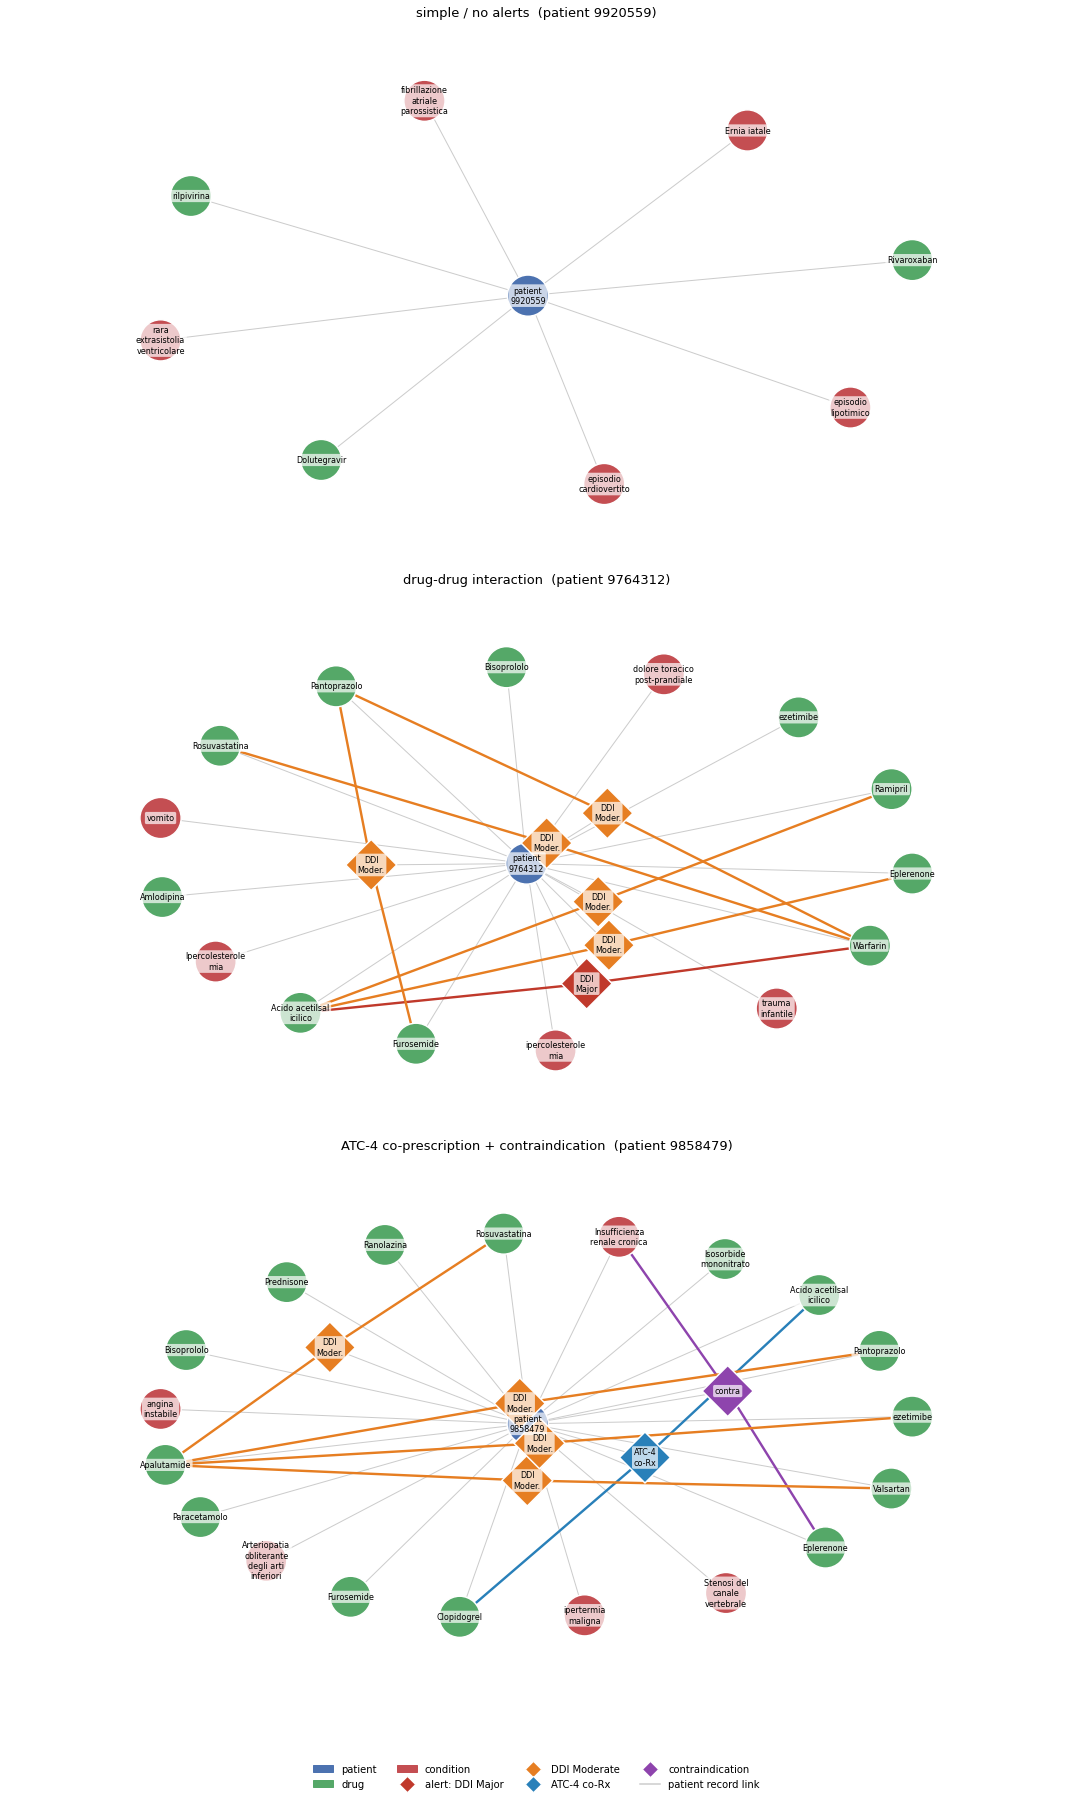

In [41]:
# ---- Visualise each demo patient's neighbourhood (networkx + matplotlib) --------------------
# The figure MIRRORS the RDF (see the triples above): an alert is a NODE (a reified relationship) linked to
# the drugs / condition it involves (`involvesDrug` / `involvesCondition`); the patient node provides the record context for drugs,
# clinical mentions and alerts. So a drug-drug interaction reads Drug-[Alert]-Drug and a contraindication reads
# Drug-[Alert]-Condition. Alerts are reified as NODES because they carry provenance, severity and links to
# multiple entities (one common KG convention among several, not the only one). Grey edges are
# patient-record context links; coloured edges connect each alert to the entities it involves. Modelling
# alerts as nodes also means two
# different alerts on the same drug pair never overwrite each other (the DiGraph-edge-collapse pitfall).
import networkx as nx
import matplotlib.pyplot as plt
import textwrap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def _wrap(s, w=15): return textwrap.fill(str(s), width=w)

_ALERT = {("drug_drug_interaction", "Major"):     ("#C0392B", "DDI\nMajor"),
          ("drug_drug_interaction", "Moderate"):  ("#E67E22", "DDI\nModer."),
          ("same_atc4_coprescription", None):     ("#2980B9", "ATC-4\nco-Rx"),
          ("drug_disease_contraindication", None):("#8E44AD", "contra")}
def _astyle(atype, sev):
    return _ALERT.get((atype, sev)) or _ALERT.get((atype, None)) or ("#F39C12", str(atype))

# rarer alerts first (contraindication -> ATC-4 co-Rx -> DDI) so the per-patient cap never hides them
_PRIO = {"drug_disease_contraindication": 0, "same_atc4_coprescription": 1, "drug_drug_interaction": 2}
_SEV  = {"Major": 0, "Moderate": 1}

def patient_subgraph(oid, max_alerts=6):
    """Reified neighbourhood: alerts are nodes linking the entities they involve. Stable node ids; the
    clipped/wrapped text is only a display label (so two conditions sharing a prefix never collapse)."""
    G = nx.DiGraph(); P = f"patient::{oid}"; G.add_node(P, kind="patient", label=f"patient\n{oid}")
    def _drug(name):
        nid = f"drug::{normalize_drug_key(name)}"
        if nid not in G: G.add_node(nid, kind="drug", label=_wrap(name)); G.add_edge(P, nid, kind="has")
        return nid
    def _cond(name):
        nid = f"condition::{name}"
        if nid not in G: G.add_node(nid, kind="condition", label=_wrap(name)); G.add_edge(P, nid, kind="has")
        return nid
    for _, r in graph_drugs[graph_drugs.encOid == oid].drop_duplicates("principio_attivo").head(8).iterrows():
        _drug(r.principio_attivo)
    for _, r in (conditions_linked[(conditions_linked.encOid == oid) &
                 (conditions_linked.assertion == "affirmed") & (conditions_linked.experiencer == "patient")]
                 .drop_duplicates("condition").head(5).iterrows()):
        _cond(r.condition)
    al = (alerts_df[alerts_df.encOid == oid]
          .assign(_p=lambda d: d.alert_type.map(_PRIO), _s=lambda d: d.severity.map(_SEV).fillna(9))
          .sort_values(["_p", "_s"]).head(max_alerts))
    for i, (_, r) in enumerate(al.iterrows()):
        col, lab = _astyle(r.alert_type, str(r.severity))
        A = f"alert::{oid}::{i}"; G.add_node(A, kind="alert", label=lab, color=col); G.add_edge(P, A, kind="has")
        if r.alert_type in ("drug_drug_interaction", "same_atc4_coprescription") and pd.notna(r.drug_a) and pd.notna(r.drug_b):
            G.add_edge(A, _drug(r.drug_a), kind="involves", color=col)
            for other in str(r.drug_b).split(", "):
                G.add_edge(A, _drug(other), kind="involves", color=col)
        elif r.alert_type == "drug_disease_contraindication" and pd.notna(r.drug_a) and pd.notna(r.condition):
            G.add_edge(A, _drug(r.drug_a), kind="involves", color=col)
            G.add_edge(A, _cond(r.condition), kind="involves", color=col)
    return G

NODECOL = {"patient": "#4C72B0", "drug": "#55A868", "condition": "#C44E52"}
def _ncolor(G, n):
    d = G.nodes[n]; return d.get("color", "#F39C12") if d["kind"] == "alert" else NODECOL[d["kind"]]

fig, axes = plt.subplots(3, 1, figsize=(15, 25))
for ax, (key, oid) in zip(axes, DEMO_PATIENTS.items()):
    G = patient_subgraph(oid)
    pos = nx.spring_layout(G, seed=SEED, k=2.7, iterations=400)
    has_e = [(u, v) for u, v, d in G.edges(data=True) if d["kind"] == "has"]
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=has_e, edge_color="#cccccc", arrows=False, width=1.0)
    for u, v, d in G.edges(data=True):
        if d["kind"] == "involves":
            nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], edge_color=d["color"], width=2.4, arrows=False)
    ents = [n for n in G.nodes if G.nodes[n]["kind"] != "alert"]
    alns = [n for n in G.nodes if G.nodes[n]["kind"] == "alert"]
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=ents, node_size=1700, edgecolors="white", linewidths=1.5,
                           node_color=[_ncolor(G, n) for n in ents])
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=alns, node_size=1300, node_shape="D", edgecolors="white",
                           linewidths=1.5, node_color=[_ncolor(G, n) for n in alns])
    nx.draw_networkx_labels(G, pos, ax=ax, labels={n: G.nodes[n]["label"] for n in G.nodes}, font_size=8,
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
    ax.set_title(f"{DEMO_DESC[key]}  (patient {oid})", fontsize=13); ax.margins(0.14); ax.axis("off")
_legend = [Patch(color=NODECOL["patient"], label="patient"), Patch(color=NODECOL["drug"], label="drug"),
           Patch(color=NODECOL["condition"], label="condition"),
           Line2D([0], [0], marker="D", color="w", markerfacecolor="#C0392B", markersize=11, label="alert: DDI Major"),
           Line2D([0], [0], marker="D", color="w", markerfacecolor="#E67E22", markersize=11, label="DDI Moderate"),
           Line2D([0], [0], marker="D", color="w", markerfacecolor="#2980B9", markersize=11, label="ATC-4 co-Rx"),
           Line2D([0], [0], marker="D", color="w", markerfacecolor="#8E44AD", markersize=11, label="contraindication"),
           Line2D([0], [0], color="#cccccc", lw=1.5, label="patient record link")]
fig.legend(handles=_legend, loc="lower center", ncol=4, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

In [42]:
# ---- SPARQL queries (including a temporal one) ----------------------------------------------
PFX = "PREFIX ex:<http://example.org/clinical/> PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>"

def sparql(title, query):
    print(f"\n### {title}")
    for row in kg.query(query):
        print("   ", " | ".join("" if v is None else str(v) for v in row))

sparql("Q1 - patients with a Major drug-drug interaction",
       PFX + """SELECT (COUNT(DISTINCT ?p) AS ?patients) WHERE {
                  ?p ex:hasAlert ?a . ?a ex:severity "Major" . ?a ex:alertType "drug_drug_interaction" . }""")

sparql("Q2 - most frequent ATC-4 subgroups in the active discharge regimens",
       PFX + """SELECT ?atc4 (COUNT(*) AS ?n) WHERE { ?d a ex:Drug ; ex:atc4 ?atc4 . }
                GROUP BY ?atc4 ORDER BY DESC(?n) LIMIT 5""")

sparql(f"Q3 - drugs and ATC of demo patient {DEMO_PATIENTS['interaction']}",
       PFX + f"""SELECT ?ing ?atc WHERE {{ ex:patient_{DEMO_PATIENTS['interaction']} ex:takesDrug ?d .
                 ?d ex:activeIngredient ?ing ; ex:atc ?atc . }} ORDER BY ?atc""")

sparql(f"Q4 (TEMPORAL) - patient-referent, non-negated condition MENTIONS grouped by discourse phase and explicit year",
       PFX + f"""SELECT ?phase ?year ?label WHERE {{
                   ex:patient_{DEMO_PATIENTS['both']} ex:hasMention ?m .
                   ?m rdfs:label ?label ; ex:temporalPhase ?phase ;
                      ex:assertion ?a ; ex:experiencer ?e .
                   OPTIONAL {{ ?m ex:year ?year }}
                   FILTER(?a != "negated" && ?e = "patient")
                   BIND(IF(?phase="remota",0,IF(?phase="prossima",1,2)) AS ?ord) }}
                 ORDER BY ?ord ?year LIMIT 15""")

sparql("Q5 - which active ingredient triggers the most interaction alerts?",
       PFX + """SELECT ?drug (COUNT(*) AS ?n) WHERE {
                  ?a ex:alertType "drug_drug_interaction" ; ex:involves ?drug . }
                GROUP BY ?drug ORDER BY DESC(?n) LIMIT 5""")


### Q1 - patients with a Major drug-drug interaction


    235

### Q2 - most frequent ATC-4 subgroups in the active discharge regimens


    B01AC | 601
    C07AB | 548
    A02BC | 519
    C10AA | 486
    C03CA | 360

### Q3 - drugs and ATC of demo patient 9764312
    Pantoprazolo | A02BC02
    Warfarin | B01AA03
    Acido acetilsalicilico | B01AC06
    Furosemide | C03CA01
    Eplerenone | C03DA04
    Bisoprololo | C07AB07
    Amlodipina | C08CA01
    Ramipril | C09AA05
    Rosuvastatina | C10AA07
    ezetimibe | C10AX09

### Q4 (TEMPORAL) - patient-referent, non-negated condition MENTIONS grouped by discourse phase and explicit year
    remota | 2018 | angina
    unspecified |  | ipertermia maligna
    unspecified |  | Stenosi del canale vertebrale
    unspecified |  | Arteriopatia obliterante degli arti inferiori
    unspecified |  | Insufficienza renale cronica
    unspecified |  | ischemia miocardica
    unspecified |  | dispnea da sforzo
    unspecified |  | saltuari episodi di precordialgia
    unspecified | 2009 | angina instabile
    unspecified | 2009 | malattia trivasale
    unspecified | 2016 | malattia coro

    Acido acetilsalicilico | 675
    Furosemide | 631
    Pantoprazolo | 613
    Dapagliflozin | 407
    Clopidogrel | 320


**Wrap-up.** *Selected* downstream outputs converge into one **queryable symbolic artifact**: ~154k RDF
triples linking patients, ATC-linked discharge drugs, and clinical mentions (ICD-9-CM coded only when the linker
does not abstain - most are coded (7436 of 11711), the rest NIL - each with a discourse-derived
`remota`/`prossima` phase and any explicit year), and provenance-carrying alerts - each alert is linked
to the specific drugs and condition it involves (`involvesDrug` / `involvesCondition`), so the graph is
relational (drug-alert-drug, drug-alert-condition) rather than a star around the patient. The graph
holds discharge drugs, anamnesis conditions and alerts; the **admission-therapy branch (Step 2) is
evaluated independently and is not integrated into the graph**, and dose/schedule/form fields are not
materialized as nodes. SPARQL answers both
cross-cohort questions (Q1, Q2, Q5) and per-patient temporal ones (Q4). The hand-written queries above
are the dependable demonstration of graph querying; the 3B model is not asked to author
SPARQL. *The
temporal ordering is "rough": most conditions carry no explicit date, so the discourse
`phase` is the primary signal - a limitation revisited in Step 10.*

## Section 9 - Gold annotation and evaluation (50 patients)

Evaluation is against a **single-annotator project gold set** (`data/annotations/`, seed 42, 50 patients;
every report identified by `encOid`/`reportOid` and a SHA-256 hash), built by automatic pre-annotation
followed by row-level review. The gold provides exhaustive span-and-context annotations,
structured to support several methodological requirements:

- **Anamnesis conditions** have an **exhaustive span-and-context gold**: *every* disease, condition,
  symptom, abnormal-finding, infection, injury and congenital-defect mention in the 50 anamneses is
  annotated (drugs, procedures, devices, normal findings and bare organisms excluded), with maximal
  non-overlapping spans and zero-based `[start, end)` offsets. This lets GLiNER **recall** be measured
  (exact-span and relaxed IoU), not just a positive rate on sampled candidates.
- **Discharge extraction is scored as a patient-level active-ingredient multiset** (duplicates counted)
  and **ingress detection uses relaxed surface alignment** by normalized mention text - the extraction
  outputs carry no offsets, so those two are *not* exact-span.
- **Context is annotated on three independent axes** - `assertion` (affirmed/negated/possible),
  `temporality` (current/historical/unspecified), `experiencer` (patient/family) - because a single
  5-way label cannot represent, e.g., *"Non familiarità per cardiopatie"* (negated **and** family).
- **ICD-9 targets allow `NIL`**: findings, organisms, drug names and vague fragments are marked
  not-codable instead of being forced onto an unrelated code.

In [43]:
# Unload the Ollama model from memory, and reload the NLI model (freed after Step 4) and spaCy (freed before Step 7).
try:
    ollama.chat(model=OLLAMA_MODEL, messages=[{"role": "user", "content": "end"}], keep_alive=0)
except Exception:
    pass
import gc, json
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score
if "kg" in globals():
    del kg; gc.collect()
if "nlp" not in globals():
    nlp = spacy.load("it_core_news_lg")
if "nli" not in globals():
    from transformers import pipeline
    nli = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=NLI_DEVICE)

# ---- load the row-by-row gold ---------------------------------------------------------------
GOLD_PATIENTS = sorted(pd.read_csv(ANNOT / "gold_report_manifest.csv").encOid.unique())
gold_dis  = pd.read_csv(ANNOT / "gold_discharge_medications_all.csv"); gold_dis["ai"] = gold_dis.active_ingredients.map(json.loads)
gold_ing  = pd.read_csv(ANNOT / "gold_ingress_medications.csv");           gold_ing["ai"] = gold_ing.active_ingredients.map(json.loads)
gold_ctx  = pd.read_csv(ANNOT / "gold_anamnesis_context.csv")
gold_icd9 = pd.read_csv(ANNOT / "gold_icd9_links.csv")
patients_by_oid = {p["encOid"]: p for p in patients}

# brand/label -> set of (salt-stripped, upper) active ingredients, for combination-aware matching
_aiconf = pd.read_parquet(EXTERNAL / "aifa" / "normalized" / "aifa_confezioni.parquet")
# Salt / ester / hydrate SUFFIXES that a combination lists but the base ingredient does not, so the
# combination's active moieties canonicalize to their base name (e.g. "rosuvastatina sale di zinco" ->
# "rosuvastatina", "formoterolo diidrato" -> "formoterolo"). Applied identically to predicted and gold.
_SALT_SUFFIX = re.compile(r"\s+(?:sale di \w+|arginina|erbumina|meglumina|trometamolo|tert[- ]?butilamina|"
                          r"calcium|magnesio\w*|sodio|potassio|zinco|propanediolo|propionato|xinafoato|"
                          r"embonato|pamoato|\w*idrato|anidro)\b.*$", re.I)
def _basei(n):
    b = re.sub(r'\s+', ' ', _SALT_RE.sub('', str(n).upper())).strip()
    return (_SALT_SUFFIX.sub('', b).strip() or b)
label2ai = {}
for _den, _pa in zip(_aiconf.DENOMINAZIONE, _aiconf.PA_ASSOCIATI):
    if pd.notna(_den) and pd.notna(_pa):
        label2ai.setdefault(_basei(_den), set()).update(_basei(x) for x in str(_pa).split("/"))
def ai_of(label):
    return label2ai.get(_basei(label), {_basei(label)})

def prf(tp, fp, fn):
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return round(P, 3), round(R, 3), round(F, 3)
def _norm(x): return re.sub(r'\s+', ' ', str(x).lower().strip())

print(f"gold: {len(GOLD_PATIENTS)} patients | discharge {len(gold_dis)} mentions | "
      f"ingress {len(gold_ing)} | context {len(gold_ctx)} | icd9 {len(gold_icd9)}")

gold: 50 patients | discharge 378 mentions | ingress 304 | context 1283 | icd9 32


In [44]:
# ==== Extraction eval - every score is computed against the human gold =========================
# NB on granularity: the pipeline outputs carry no character offsets, so this is *not* exact-span
# evaluation. Discharge is scored as a patient-level active-ingredient MULTISET (duplicates counted);
# ingress scoring is a RELAXED normalized-text mention alignment (predicted vs gold aligned by mutual
    # substring containment of the normalized surface); it does NOT measure character-span boundaries. No score
# below compares one method to another - the reference is always the gold.

# Discharge - regex (SYMBOLIC) vs gold: active-ingredient multiset per patient.
tp = fp = fn = 0
for oid in GOLD_PATIENTS:
    g = Counter(_norm(i) for L in gold_dis[gold_dis.encOid == oid].ai for i in L)
    p = Counter(_norm(i) for L in discharge_df[discharge_df.encOid == oid].principio_attivo for i in L)
    for k in set(g) | set(p):
        tp += min(g[k], p[k]); fp += max(0, p[k] - g[k]); fn += max(0, g[k] - p[k])
dis_P, dis_R, dis_F = prf(tp, fp, fn)

# Ingress - detection (symbolic router + AIFA gazetteer) vs gold, then exact-catalog ingredient-set
# normalization of the SAME aligned mentions vs gold. Single final system, no method comparison.
det_tp = det_fp = det_fn = 0
norm_tot = norm_exact = norm_partial = 0          # exact AIFA-catalog normalization of the detected mentions
for oid in GOLD_PATIENTS:
    gm = gold_ing[gold_ing.encOid == oid]
    pm = ingress_drugs[ingress_drugs.encOid == oid]                # detection over every proposed mention
    pset = [(_norm(r.mention), ai_of(r.matched_label) if r.resolved else set()) for _, r in pm.iterrows()]; used = set()
    for _, r in gm.iterrows():
        gt = _norm(r.mention_text); gai = {_basei(x) for x in r.ai}
        m = next((j for j, (pt, _ai) in enumerate(pset) if j not in used and (gt in pt or pt in gt)), None)
        if m is None:
            det_fn += 1
        else:
            used.add(m); det_tp += 1; norm_tot += 1
            if pset[m][1] == gai:   norm_exact += 1
            elif pset[m][1] & gai:  norm_partial += 1
    det_fp += len(pset) - len(used)

ing_P, ing_R, ing_F = prf(det_tp, det_fp, det_fn)
_n_dis_rows = len(gold_dis); _n_dis_comp = sum(len(L) for L in gold_dis.ai)
extraction = pd.DataFrame([
    {"stage": "Step 1 discharge - template regex + AIFA tail recovery vs gold", "P": dis_P, "R": dis_R, "F1": dis_F,
     "detail": f"active-ingredient multiset - {_n_dis_comp} components ({_n_dis_rows} rows, combos exploded)"},
    {"stage": "Step 2 ingress - relaxed normalized-text mention alignment (no offsets) vs gold", "P": ing_P, "R": ing_R, "F1": ing_F,
     "detail": f"relaxed mention detection ({det_tp} aligned)"},
]).set_index("stage")
print(f"ingress ingredient-set NORMALIZATION vs gold, on the {norm_tot} aligned mentions "
      f"(exact catalog + n-gram fallback): exact {norm_exact/norm_tot:.2f} | +partial {(norm_exact+norm_partial)/norm_tot:.2f}")
extraction

ingress ingredient-set NORMALIZATION vs gold, on the 304 aligned mentions (exact catalog + n-gram fallback): exact 0.92 | +partial 0.98


,P,R,F1,detail
stage,,,,
Step 1 discharge - template regex + AIFA tail recovery vs gold,0.998,0.983,0.990,"active-ingredient multiset - 424 components (378 rows, combos exploded)"
Step 2 ingress - relaxed normalized-text mention alignment (no offsets) vs gold,0.977,1.000,0.989,relaxed mention detection (304 aligned)


Discharge extraction is essentially exact (template regex plus AIFA-validated tail recovery); the discharge/ingress medication gold was itself pre-annotated with the same header pattern and then manually reviewed, so these near-perfect figures measure extractor-review agreement rather than fully independent accuracy (the GLiNER NER evaluation, a different model against manual spans, is the independent check). Ingress **detection** is
strong (the symbolic router + AIFA gazetteer find the drug mentions), while **normalization** - mapping a brand
to the right active ingredient by exact AIFA-catalog lookup - is the lossy part: exact ingredient-set accuracy is
**0.92** among aligned mentions (allowing partial overlap for combination products raises it to **0.98**). A
salt/ester canonicalization collapses a combination's components to their base name ("rosuvastatina sale di
zinco" -> "rosuvastatina"), so both active ingredients match the gold; the residual errors come from
mentions absent from the catalog and products sharing a normalized name.

### GLiNER condition NER - measured against the exhaustive gold

Because the context gold annotates **every** condition mention in the 50 anamneses, GLiNER's
**recall** can be measured, not only its precision. The GLiNER spans whose label is a condition type
(`malattia` / `condizione patologica`) are scored for the 50 gold patients, on document-level character offsets
keyed by `(encOid, reportOid, start, end)`. **Exact-span P/R/F1 is the primary result**; a relaxed
**Intersection-over-Union (IoU) ≥ 0.5** (one-to-one within a report) is reported alongside, because zero-shot NER often picks
slightly different but overlapping boundaries.

In [45]:
# ==== GLiNER condition NER: exact-span (primary) + relaxed IoU>=0.5 (secondary) ==============
_manifest = pd.read_csv(ANNOT / "gold_report_manifest.csv")
_anam_rep = dict(zip(_manifest.loc[_manifest.report_type == "Anamnesi", "encOid"],
                     _manifest.loc[_manifest.report_type == "Anamnesi", "reportOid"]))
COND_LABELS = {"malattia", "condizione patologica"}
ner_pred = anamnesis_entities[anamnesis_entities.encOid.isin(GOLD_PATIENTS) &
                              anamnesis_entities.label.isin(COND_LABELS)].copy()
ner_pred["reportOid"] = ner_pred.encOid.map(_anam_rep)

# one prediction per unique (encOid, reportOid, start, end): a span emitted under two condition
# labels (malattia / condizione patologica) must not be double-counted against a single gold span
ner_pred = ner_pred.drop_duplicates(["encOid", "reportOid", "start", "end"]).copy()

# primary: exact-span match on (encOid, reportOid, start, end), one-to-one
_gold_keys = set(zip(gold_ctx.encOid, gold_ctx.reportOid, gold_ctx.start, gold_ctx.end))
_pred_keys = list(zip(ner_pred.encOid, ner_pred.reportOid, ner_pred.start, ner_pred.end))  # unique after dedup
_pred_set  = set(_pred_keys)
ex_tp = len(_gold_keys & _pred_set)
ex_fp = len(_pred_set - _gold_keys)
ex_fn = len(_gold_keys - _pred_set)
exact_P, exact_R, exact_F = prf(ex_tp, ex_fp, ex_fn)

# secondary: relaxed IoU>=0.5, one prediction matches at most one gold span within a report
def _iou(a, b, c, d):
    inter = max(0, min(b, d) - max(a, c)); union = (b - a) + (d - c) - inter
    return inter / union if union else 0.0
rel_tp = 0
for oid in GOLD_PATIENTS:
    gp = gold_ctx.loc[gold_ctx.encOid == oid, ["start", "end"]].values.tolist()
    pp = ner_pred.loc[ner_pred.encOid == oid, ["start", "end"]].values.tolist()
    cand = sorted(((_iou(gs, ge, ps, pe), gi, pi)
                   for gi, (gs, ge) in enumerate(gp) for pi, (ps, pe) in enumerate(pp)
                   if _iou(gs, ge, ps, pe) >= 0.5), reverse=True)
    ug, up = set(), set()
    for v, gi, pi in cand:
        if gi in ug or pi in up:
            continue
        ug.add(gi); up.add(pi); rel_tp += 1
rel_fp, rel_fn = len(ner_pred) - rel_tp, len(gold_ctx) - rel_tp
rel_P, rel_R, rel_F = prf(rel_tp, rel_fp, rel_fn)

gliner_ner = pd.DataFrame([
    {"match": "exact span",        "TP": ex_tp,  "FP": ex_fp,  "FN": ex_fn,  "P": exact_P, "R": exact_R, "F1": exact_F},
    {"match": "relaxed IoU>=0.5",  "TP": rel_tp, "FP": rel_fp, "FN": rel_fn, "P": rel_P,   "R": rel_R,   "F1": rel_F},
]).set_index("match")
print(f"{len(ner_pred)} GLiNER condition predictions vs {len(gold_ctx)} exhaustive gold spans "
      f"({len(GOLD_PATIENTS)} patients)")
gliner_ner

781 GLiNER condition predictions vs 1283 exhaustive gold spans (50 patients)


,TP,FP,FN,P,R,F1
match,,,,,,
exact span,569,212,714,0.729,0.443,0.551
relaxed IoU>=0.5,638,143,645,0.817,0.497,0.618


In [46]:
# Error analysis: representative exact-span false positives and false negatives
_fp = sorted(_pred_set - _gold_keys)[:6]
_fn = sorted(_gold_keys - _pred_set)[:6]
def _fp_row(k):
    r = ner_pred[(ner_pred.encOid == k[0]) & (ner_pred.start == k[2]) & (ner_pred.end == k[3])].iloc[0]
    return {"type": "FP (spurious / boundary)", "encOid": k[0], "offsets": f"{k[2]}:{k[3]}",
            "span": r.text, "sentence": r.sentence[:55]}
def _fn_row(k):
    r = gold_ctx[(gold_ctx.encOid == k[0]) & (gold_ctx.start == k[2]) & (gold_ctx.end == k[3])].iloc[0]
    return {"type": "FN (missed by GLiNER)", "encOid": k[0], "offsets": f"{k[2]}:{k[3]}",
            "span": r.condition, "sentence": str(r.sentence)[:55]}
pd.DataFrame([_fp_row(k) for k in _fp] + [_fn_row(k) for k in _fn])

,type,encOid,offsets,span,sentence
0,FP (spurious / boundary),9920559,344:366,episodio cardiovertito,Ultimo episodio in data 22.12.2024 atriale mentre lavor
1,FP (spurious / boundary),9920559,700:731,rara extrasistolia ventricolare,rara extrasistolia ventricolare e rara extrasistolia so
2,FP (spurious / boundary),9920559,734:770,rara extrasistolia sopraventricolare,rara extrasistolia ventricolare e rara extrasistolia so
3,FP (spurious / boundary),9920559,1114:1127,TC coronarica,In data 05.11.2025 TC coronarica che documentava:
4,FP (spurious / boundary),9920559,1662:1683,fibrillazione atriale,Si ricovera per ablazione transcatetere di fibrillazion
5,FP (spurious / boundary),9992853,246:261,Colecistectomia,Colecistectomia.
6,FN (missed by GLiNER),9920559,705:731,extrasistolia ventricolare,Si segnalano: rara extrasistolia ventricolare e rara ex
7,FN (missed by GLiNER),9920559,739:770,extrasistolia sopraventricolare,Si segnalano: rara extrasistolia ventricolare e rara ex
8,FN (missed by GLiNER),9920559,1174:1234,stenosi significative delle coronarie epicardiche principali,Assenza di stenosi significative delle coronarie epicar
9,FN (missed by GLiNER),9920559,1272:1314,placca eccentrica non calcifica prossimale,Coronaria discendente anteriore con placca eccentrica n


GLiNER reaches decent **precision** but **low recall**: it misses many of the symptom / abnormal-finding
mentions the broad gold includes (e.g. `FAP`, `cardiopalmo`, `attacchi di panico`), and part of the
exact-vs-relaxed gap is boundary errors (`Non ipertensione` swallows the negation, `Alla TAC` is not a
condition). Recall is the weak point of the zero-shot NER - *measurable* here only because the
gold is exhaustive rather than a sample of GLiNER's own candidates.

The gold uses a **broad clinical-condition definition** that includes symptoms and abnormal findings,
whereas GLiNER is prompted with only two general labels (`malattia`, `condizione patologica`). The
measured recall therefore reflects **both** missed diseases **and** limited coverage of symptom/finding
expressions - a policy choice made explicit here, not a tuning failure hidden away.

In [47]:
# ==== Context classification - evaluated on THREE independent axes ============================
assert gold_ctx["is_condition"].all()              # exhaustive gold: every row is a real condition mention
valid_ctx = gold_ctx.copy()
print(f"context gold: {len(valid_ctx)} condition mentions over {valid_ctx.encOid.nunique()} patients | "
      f"per-axis class counts: " + " | ".join(f"{ax} {valid_ctx[ax].value_counts().to_dict()}" for ax in
      ["assertion", "temporality", "experiencer"]))
_docs  = {oid: nlp(report_text(patients_by_oid[oid], T_ANAMNESI)) for oid in valid_ctx.encOid.unique()}
_marks = {oid: section_marks(report_text(patients_by_oid[oid], T_ANAMNESI)) for oid in valid_ctx.encOid.unique()}

# Batched NLI so the full exhaustive gold can be scored in one sweep. With multi_label=False the
# zero-shot pipeline ranks candidates by their raw *entailment* logit; exactly that is computed
# quantity in mini-batches (verified identical to classify_nli_axes) instead of one pipeline call per
# span. classify_nli_axes (Section 4c) stays the readable per-span version used in the demos.
import torch, json, hashlib
_ENT_ID = nli.model.config.label2id["entailment"]

@torch.no_grad()
def _entail_logit(premises, hypotheses, bs=32):
    out = []
    for i in range(0, len(premises), bs):
        enc = nli.tokenizer(premises[i:i + bs], hypotheses[i:i + bs], return_tensors="pt",
                            padding=True, truncation=True, max_length=256).to(nli.model.device)
        out.extend(nli.model(**enc).logits[:, _ENT_ID].tolist())
    return out

def _nli_axis_batch(items, hyp_map):
    """items: list of (sentence, condition) -> argmax-entailment key per item (matches classify_nli_axes)."""
    keys = list(hyp_map); prem, hyp = [], []
    for s, c in items:
        for k in keys:
            prem.append(s); hyp.append(hyp_map[k].format(c=c))
    lg = _entail_logit(prem, hyp); K = len(keys)
    return [keys[max(range(K), key=lambda j: lg[i * K + j])] for i in range(len(items))]

# symbolic predictions (fast) + one batched NLI pass reused by configs (b) and (c)
_rows  = list(valid_ctx.itertuples(index=False))
basic_pred = [classify_basic_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end)) for r in _rows]
dep_pred   = [classify_dep_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end))   for r in _rows]
_items = [(r.sentence, r.condition) for r in _rows]

# Cache the NLI predictions (the only slow part, ~10 min on a laptop GPU). The key hashes the gold
# spans AND the hypothesis templates, so any change to either recomputes rather than serving a stale file.
_model_id = nli.model.config._name_or_path            # cache also keyed on the NLI model
_key = hashlib.md5((_model_id + "||" + "||".join(f"{c}\t{s}" for s, c in _items) +
                    repr((ASSERT_HYP, TEMP_HYP, EXP_HYP))).encode("utf-8")).hexdigest()
_nli_cache = OUTPUTS / "step9_context_nli.json"
_cached = json.loads(_nli_cache.read_text(encoding="utf-8")) if _nli_cache.exists() else {}
if _cached.get("key") == _key:
    _na, _nt, _ne = _cached["assertion"], _cached["temporality"], _cached["experiencer"]
    print(f"loaded cached NLI context predictions ({len(_na)} spans)")
else:
    print(f"scoring {len(_items)} spans with batched NLI (one-time; cached to {_nli_cache.name} afterwards)...")
    _na = _nli_axis_batch(_items, ASSERT_HYP); _nt = _nli_axis_batch(_items, TEMP_HYP); _ne = _nli_axis_batch(_items, EXP_HYP)
    _nli_cache.write_text(json.dumps({"key": _key, "assertion": _na, "temporality": _nt, "experiencer": _ne}),
                          encoding="utf-8")

assert len(_na) == len(_items) and len(_nt) == len(_items) and len(_ne) == len(_items)
nli_pred = [{"assertion": a, "temporality": t, "experiencer": e} for a, t, e in zip(_na, _nt, _ne)]
# (c) cascade: keep the dep answer unless it fell back to a default, then take NLI's
cascade_pred = []
for dp, npd in zip(dep_pred, nli_pred):
    o = dict(dp)
    if o["assertion"] == "affirmed":      o["assertion"]   = npd["assertion"]
    if o["temporality"] == "unspecified": o["temporality"] = npd["temporality"]
    cascade_pred.append(o)

AXES = {"assertion": ["affirmed", "negated", "possible"],
        "temporality": ["current", "historical", "unspecified"],
        "experiencer": ["patient", "family"]}
CONFIGS = ["(a) NegEx basic", "(a) NegEx+dep", "(b) NLI", "(c) NegEx->NLI"]
axpreds = {"(a) NegEx basic": basic_pred, "(a) NegEx+dep": dep_pred,
           "(b) NLI": nli_pred, "(c) NegEx->NLI": cascade_pred}

from sklearn.metrics import precision_recall_fscore_support
rows = []
for cfg in CONFIGS:
    row = {"config": cfg}
    for ax, labels in AXES.items():
        yt = list(valid_ctx[ax]); yp = [p[ax] for p in axpreds[cfg]]
        P, R, F, _ = precision_recall_fscore_support(yt, yp, labels=labels, average="macro", zero_division=0)
        row[f"{ax} acc"] = round(accuracy_score(yt, yp), 2)
        row[f"{ax} mP"]  = round(P, 2)
        row[f"{ax} mR"]  = round(R, 2)
        row[f"{ax} mF1"] = round(F, 2)
    rows.append(row)
context_axes = pd.DataFrame(rows).set_index("config")
print(wrap("Columns: acc = accuracy; mP / mR / mF1 = macro-averaged precision / recall / F1 "
           "(unweighted over the axis classes, range 0-1, higher is better)."))
context_axes

context gold: 1283 condition mentions over 50 patients | per-axis class counts: assertion {'affirmed': 1087, 'negated': 172, 'possible': 24} | temporality {'current': 627, 'historical': 435, 'unspecified': 221} | experiencer {'patient': 1246, 'family': 37}


loaded cached NLI context predictions (1283 spans)


Columns: acc = accuracy; mP / mR / mF1 = macro-averaged precision / recall / F1 (unweighted over the
axis classes, range 0-1, higher is better).


,assertion acc,assertion mP,assertion mR,assertion mF1,temporality acc,temporality mP,temporality mR,temporality mF1,experiencer acc,experiencer mP,experiencer mR,experiencer mF1
config,,,,,,,,,,,,
(a) NegEx basic,0.96,0.90,0.86,0.88,0.28,0.46,0.38,0.26,1.00,1.00,0.96,0.98
(a) NegEx+dep,0.89,0.74,0.73,0.69,0.31,0.46,0.41,0.30,0.98,0.82,0.98,0.88
(b) NLI,0.61,0.67,0.74,0.56,0.47,0.42,0.40,0.40,0.94,0.64,0.88,0.70
(c) NegEx->NLI,0.62,0.65,0.80,0.57,0.46,0.44,0.41,0.38,0.98,0.82,0.98,0.88


**Reading the multi-axis table.** Each configuration predicts the three axes *directly* (the gold is
multi-axis, so the classifier must be too; a single label cannot encode "negated and family"). The
classes are imbalanced, so **macro-F1** and **macro-recall** are read, not only accuracy.

- **Assertion (affirmed / negated / possible).** Fixed-window NegEx is the strongest (acc 0.96,
  mR 0.86, macro-F1 0.88); dependency propagation *decreases* performance (acc 0.89, mR 0.73,
  macro-F1 0.69) because it can over-extend negation through `conj` arcs in telegraphic clinical text,
  so its win on the coordinated examples of Section 4 does not carry over. NLI performs poorly here
  (acc 0.61) - it over-predicts the rare `possible` class - so the neural model is *not* competitive on
  assertion.
- **Temporality (current / historical / unspecified).** The hard axis: everyone is weak. Here **NLI
  gives the best result** (acc 0.47, mR 0.40, macro-F1 0.40), ahead of the symbolic configs (~0.30
  macro-F1), but 0.40 is still low - telling *current* from *past* needs discourse reasoning that the
  section heuristics and a sentence-level NLI model both lack.
- **Experiencer (patient / family).** Accuracy is very high (acc 0.98) because patient mentions dominate
  the gold. The dependency config reaches **macro-recall 0.98 / macro-F1 0.88** on this axis, because a
  family cue anywhere in the sentence is treated as family scope; the fixed-window baseline is higher on macro-F1
  (0.98 vs 0.88, while the dependency config is slightly higher on macro-recall (0.98 vs 0.96)), since a `Familiarità per …` header cue does not always reach the condition span
  through the imperfect dependency arcs.

The **NegEx->NLI cascade** improves temporality over the dependency baseline but substantially
*lowers* assertion, and it escalates to the neural model on **96%** of spans - so it delivers neither
a consistent accuracy gain nor a compute saving. The takeaway (exactly why one must look past accuracy):
each syntactic or neural upgrade helps on some axes and hurts on others, and must be validated on the
axis it is meant to improve rather than assumed better.

In [48]:
# How often does the cascade escalate an axis to the neural model?
def _needs_s2(r):
    a = classify_dep_axes(_docs[r.encOid], _marks[r.encOid], int(r.start), int(r.end))
    return a["assertion"] == "affirmed" or a["temporality"] == "unspecified"
n_sys2 = sum(1 for _, r in valid_ctx.iterrows() if _needs_s2(r))
print(f"neural model consulted on {n_sys2}/{len(valid_ctx)} spans "
      f"({n_sys2/len(valid_ctx):.0%}); the rest resolved by the symbolic classifier alone.")
print("NB: the default-trigger gate (assertion=affirmed OR temporality=unspecified) is *too permissive* -\n"
      "it escalates most spans, so the hybrid does not actually save neural cost here.")

neural model consulted on 1238/1283 spans (96%); the rest resolved by the symbolic classifier alone.
NB: the default-trigger gate (assertion=affirmed OR temporality=unspecified) is *too permissive* -
it escalates most spans, so the hybrid does not actually save neural cost here.


In [49]:
# ==== ICD-9-CM linking - raw top-1 accuracy + NIL-aware abstention ============================
# Score linking only where the gold has a code; report NIL detection separately (never force a link).
# Accuracy uses the pipeline's RAW top-1 code (icd9_code_top1, before the similarity abstention).
_pred = {}
for _, r in conditions_linked.iterrows():
    _pred.setdefault(_norm(r.condition), (r.get("icd9_code_top1"), r.icd9_sim))
gold_icd9["pipe_code"] = gold_icd9.condition.map(lambda c: (_pred.get(_norm(c)) or (None, None))[0])
gold_icd9["pipe_sim"]  = gold_icd9.condition.map(lambda c: (_pred.get(_norm(c)) or (None, None))[1])

def _norm_code(v):
    if pd.isna(v):
        return None
    return re.sub(r"\.0$", "", str(v).strip())

_code = gold_icd9[gold_icd9.gold_status == "code"].copy()
_pc = _code.pipe_code.map(_norm_code)                       # normalize BOTH sides before comparing
_gc = _code.gold_icd9_code.map(_norm_code)
exact = (_pc == _gc).mean()
categ = (_pc.map(lambda x: x.split(".")[0] if x else None) ==
         _gc.map(lambda x: x.split(".")[0] if x else None)).mean()
print(f"ICD-9 raw top-1 linking accuracy (before threshold-based abstention) on {len(_code)} codable "
      f"conditions: exact = {exact:.0%} | same code stem before the decimal = {categ:.0%}")

# NIL detection = similarity-threshold abstention. A missing prediction (no text join) is treated as
# abstention (similarity -> -1), i.e. a predicted NIL, rather than being silently dropped.
gold_nil = gold_icd9.gold_status != "code"
n_nil = int(gold_nil.sum())
_sim = gold_icd9.pipe_sim.fillna(-1.0)
print(f"NIL detection ({n_nil} not-codable cases) by a similarity cut-off:")
for thr in (0.86, 0.88, 0.90):
    pred_nil = _sim < thr
    tp = int((pred_nil & gold_nil).sum()); fp = int((pred_nil & ~gold_nil).sum()); fn = int((~pred_nil & gold_nil).sum())
    print(f"   sim < {thr}:  P/R/F1 = {prf(tp, fp, fn)}")
_pn = _sim < 0.88
nil088 = prf(int((_pn & gold_nil).sum()), int((_pn & ~gold_nil).sum()), int((~_pn & gold_nil).sum()))
print("=> similarity separates NIL from codable only weakly: ICD-9 linking is the pipeline's weak point.")

ICD-9 raw top-1 linking accuracy (before threshold-based abstention) on 20 codable conditions: exact = 20% | same code stem before the decimal = 25%
NIL detection (12 not-codable cases) by a similarity cut-off:
   sim < 0.86:  P/R/F1 = (0.75, 0.25, 0.375)
   sim < 0.88:  P/R/F1 = (0.5, 0.583, 0.538)
   sim < 0.9:  P/R/F1 = (0.407, 0.917, 0.564)
=> similarity separates NIL from codable only weakly: ICD-9 linking is the pipeline's weak point.


In [50]:
# ==== Consolidated scorecard =================================================================
PRIMARY = "(a) NegEx+dep"       # syntax-aware config used in the pipeline, fixed before evaluation;
                                # The syntax-aware configuration is used by the pipeline; the ablation shows the fixed-window baseline is stronger on assertion, and this limitation is reported explicitly.
def context_result(axis):
    r = context_axes.loc[PRIMARY]
    return (f"acc {r[f'{axis} acc']:.2f}; mP/mR/mF1 "
            f"{r[f'{axis} mP']:.2f}/{r[f'{axis} mR']:.2f}/{r[f'{axis} mF1']:.2f}")

exact_coverage = n_exact / len(discharge_linked)

scorecard = pd.DataFrame([
    ("Step 1  discharge (template regex + AIFA tail recovery) - active-ingredient multiset",  f"P/R/F1 = {dis_P:.2f}/{dis_R:.2f}/{dis_F:.2f}"),
    ("Step 2  ingress relaxed mention alignment (normalized-text, no offsets) vs gold", f"P/R/F1 = {ing_P:.2f}/{ing_R:.2f}/{ing_F:.2f}"),
    ("Step 2  ingress normalization vs gold (exact catalog + n-gram fallback)", f"{norm_exact/norm_tot:.2f} exact | {(norm_exact+norm_partial)/norm_tot:.2f} +partial"),
    ("Step 3  GLiNER condition NER - exact spans",           f"P/R/F1 = {exact_P:.2f}/{exact_R:.2f}/{exact_F:.2f}"),
    ("Step 3  GLiNER condition NER - relaxed IoU>=0.5",      f"P/R/F1 = {rel_P:.2f}/{rel_R:.2f}/{rel_F:.2f}"),
    (f"Step 4  context - assertion axis ({PRIMARY})",       context_result("assertion")),
    (f"Step 4  context - experiencer axis ({PRIMARY})",     context_result("experiencer")),
    (f"Step 4  context - temporality axis ({PRIMARY})",     context_result("temporality") + "  (hardest axis)"),
    ("Step 5  drug -> ATC linking",                         f"{exact_coverage:.0%} exact-dictionary coverage; remainder via retrieval fallback; no independent ATC-code gold"),
    ("Step 5  condition -> ICD-9 (codable rows)",           f"exact {exact:.0%} / category {categ:.0%}; NIL@0.88 P/R/F1 {nil088[0]:.2f}/{nil088[1]:.2f}/{nil088[2]:.2f} (weakest stage)"),
], columns=["stage", "result"]).set_index("stage")
with pd.option_context("display.max_colwidth", None, "display.width", 200):
    display(scorecard)

,result
stage,
Step 1 discharge (template regex + AIFA tail recovery) - active-ingredient multiset,P/R/F1 = 1.00/0.98/0.99
"Step 2 ingress relaxed mention alignment (normalized-text, no offsets) vs gold",P/R/F1 = 0.98/1.00/0.99
Step 2 ingress normalization vs gold (exact catalog + n-gram fallback),0.92 exact | 0.98 +partial
Step 3 GLiNER condition NER - exact spans,P/R/F1 = 0.73/0.44/0.55
Step 3 GLiNER condition NER - relaxed IoU>=0.5,P/R/F1 = 0.82/0.50/0.62
Step 4 context - assertion axis ((a) NegEx+dep),acc 0.89; mP/mR/mF1 0.74/0.73/0.69
Step 4 context - experiencer axis ((a) NegEx+dep),acc 0.98; mP/mR/mF1 0.82/0.98/0.88
Step 4 context - temporality axis ((a) NegEx+dep),acc 0.31; mP/mR/mF1 0.46/0.41/0.30 (hardest axis)
Step 5 drug -> ATC linking,95% exact-dictionary coverage; remainder via retrieval fallback; no independent ATC-code gold


**Wrap-up.** Scored as a patient-level active-ingredient multiset (discharge), relaxed surface-alignment
(ingress detection), three independent axes (context) and NIL-aware linking (ICD-9), the pipeline is strong
exactly where the signal is clean and symbolic (discharge extraction ≈ 0.99 F1; ingress *detection* ≈ 0.98;
assertion and experiencer reach high accuracy - though macro-F1 exposes the minority classes (assertion
≈ 0.69; experiencer ≈ 0.88 for the primary config)),
and weak where it is not: ingress **normalization** (~0.92
exact-set, catalog-absence and product-ambiguity confusions), **temporality** (weak across every config - the best is NLI at
0.47 accuracy / 0.40 macro-F1, the open problem), and above all **condition→ICD-9 linking** (exact ~20%,
category ~25% on codable cases), where **12 of the 32 evaluated cases are not codable diagnoses at all** and
forcing a code is the wrong behaviour. The comparison of the four context configs is instructive: **the syntactic and neural upgrades help on some axes and hurt on others**, so each
must be validated on the axis it is meant to improve rather than assumed better.

*(Not attempted)* an end-to-end alert gold, which would need clinician validation beyond this project;
alerts remain traceable (Section 6) but are not claimed to be clinically complete.

## Section 10 - Discussion and limitations

This notebook prioritizes **breadth and transparency** over maximum task accuracy. A few design decisions and limitations deserve discussion.

### Which Kautz types were built
Across the pipeline the following were used: **Type 1** (GLiNER: symbols in, symbolic spans out - Step 3), **Type 2**
(Symbolic[Neuro]: the symbolic controller that calls the NLI model, Step 4c), and **Type 6** (Neuro[Symbolic]:
the LLM tool-calling loop, Step 7). 

### The alert engine is educational, not clinical
The DDI evidence comes from **DDInter 2.0** (a curated open-access academic DDI database) and
drug-disease contraindications from the official **MED-RT** (NLM); the rules operate over external resources. This is a **didactic artifact,
not a clinical decision-support product**: coverage is partial, the cross-lingual condition→disease
matching in Rule 3 is approximate (documented false positives).

### The weakest link
Condition→**ICD-9-CM** linking (~20% exact / ~25% same code-stem on codable spans) is the low point. Two causes compound: ICD-9 has
16k fine-grained, formally-phrased Italian labels that a short colloquial span matches poorly and
12 of the 32 evaluated ICD-9 cases are not codable diagnoses at all (imaging findings like *ipocinesia
laterale*, organisms, acronyms). 

### What the evaluation does and does not measure
The extraction scores are computed against the gold as a patient-level active-ingredient **multiset**
(discharge) and a **relaxed surface alignment** of mentions (ingress): the pipeline drug outputs carry no
character offsets, so extraction is **not** scored as exact-span IoU - the GLiNER NER step, which does
keep offsets, is the only span-level exact/IoU evaluation. Discharge drugs written outside the quoted
template are recovered only when they resolve in the AIFA catalog, so brands absent from the catalog are
still missed.

### The gold is a single-annotator project resource
The gold in `data/annotations/` is a **gold set** - automatic pre-annotation
followed by row-level review - aligned to the source text by `encOid`/`reportOid` and SHA-256. 

### Scaling to the full 857 (and beyond) in production
The pipeline already runs end-to-end on the full 857-patient cohort - extraction, GLiNER NER, ATC/ICD-9
linking, the alert engine and the knowledge graph all execute on every record; only the gold-based
*evaluation* is limited to the 50 annotated patients. The mechanisms for a larger deployment are the
same ones used here, scaled up:

1. **Batch + cache** the two heavy neural stages - dictionary/ICD-9 embeddings and GLiNER - to disk
   (cached to `.npy`/`.parquet`): caching avoids recomputation on unchanged data. True incremental
   processing of only-new patients would be a production extension, not implemented here.
2. **Keep the LLM optional**: Ollama is the only *generative* component and is invoked only for individual
   demonstrations (the other neural stages are batched and cached), so it runs on **flagged / demo patients only**. At scale it should be invoked *reactively* - to
   explain an alert or arbitrate an ambiguous context - never as a batch pass over every record.